# Análisis exploratorio del corpus

Este notebook se centra en el análisis exploratorio del corpus de textos, con el objetivo de comprender mejor su estructura, características y posibles patrones estilísticos. Se realizarán diversas visualizaciones y análisis estadísticos para obtener información sobre los autores, sus obras y algunas de las características lingüísticas presentes en el corpus.

In [1]:
import re
import random
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import nltk
from nltk.corpus import stopwords
from spacy.lang.en.stop_words import STOP_WORDS

from whodunit_stylometry.utils.data_utils import get_file_inventory, read_book_text
from whodunit_stylometry.utils.nlp_utils import (
    compute_novel_metrics,
    compute_word_frecuencies,
    top_n_words,
    compute_ngrams_frecuencies,
    get_tokens_alpha_by_author,
)
from whodunit_stylometry.utils.stats_utils import add_iqr_outlier_flags
from whodunit_stylometry.utils.plot_utils import (
    plot_authors_pca,
    plot_novels_per_author,
    plot_publication_year_distribution,
    plot_metrics_histograms,
    plot_metrics_boxplots_by_author,
    plot_metrics_correlations_heatmap,
    plot_bars_by_author_with_std,
    plot_scatter_list_plotly,
    plot_standardized_heatmap_by_author,
    plot_zipf_curve_by_author,
)

In [2]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /Users/elle/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/elle/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Configuración

In [3]:
CORPUS_DIR = Path("../corpus")
CORPUS_HC_DIR = Path("../corpus/hand_cleaned")
OUTPUT_DIR = Path("../output")
TABLES_DIR = OUTPUT_DIR / "tables"
FIGS_DIR = OUTPUT_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

## Stopwords

Para el EDA voy a crear un conjunto de *stopwords* personalizado a partir de la unión de las *stopwords* de NLTK y las de spaCy obteniendo así un conjunto más completo. Esto es debido a que, aunque ambos conjuntos son bastante similares, cada uno tiene algunas palabras que el otro no incluye.

En principio no voy a sacar del conjunto de *stopwords* ninguna palabra como, por ejemplo, las negaciones, pero sí voy a añadir `"ain't"` que es una contracción común en inglés que no está incluida en ninguno de los dos conjuntos.

Posteriormente, añadiré el listado de *stopwords* obtenido al archivo `constants.py` para poder utilizarlo en el resto del proyecto.

In [4]:
# Obtengo las stopwords de NLTK para inglés
LANG = "english"
nltk_stopwords = set(stopwords.words(LANG))
print(f"Number of NLTK stopwords: {len(nltk_stopwords)}")
print(list(nltk_stopwords)[:20])

Number of NLTK stopwords: 198
['after', 'when', 'ain', "mightn't", 'been', 'their', 'against', 'you', 'while', 'hadn', 'some', 'them', 'myself', 'over', 'can', 'mustn', 'more', 'd', 'now', 'herself']


In [5]:
# Obtengo las stopwords de spaCy para inglés y hago
# un pequeño reemplazo para normalizar las comillas
# simples tal y como haré luego con el texto del corpus
spacy_stopwords = {sw.replace("‘", "'").replace("’", "'") for sw in STOP_WORDS}
print(f"Number of spaCy stopwords: {len(spacy_stopwords)}")
print(list(spacy_stopwords)[:20])

Number of spaCy stopwords: 312
['per', 'mine', 'yet', 'quite', 'various', 'however', 'used', 'besides', 'my', 'thus', 'whatever', 'third', 'eight', 'very', 'really', 'did', 'it', 'also', 'whoever', "n't"]


In [6]:
# Uno ambos conjuntos de stopwords para
# obtener un conjunto más completo
STOPWORDS = nltk_stopwords.union(spacy_stopwords)
print(f"Total of stopwords: {len(STOPWORDS)}")

Total of stopwords: 387


In [7]:
# Añado "ain't" al conjunto de stopwords
STOPWORDS.add("ain't")
print(f"Total of stopwords: {len(STOPWORDS)}")

Total of stopwords: 388


In [8]:
# sorted(list(STOPWORDS))

## Carga del corpus y sus metadatos

En primer luagr, vamos a cargar la información del listado de obras del corpus a partir del CSV de metadatos (`corpus_metadata.csv`).

A estos metadatos, les vamos a añadir una serie de información adicional a partir de los archivos de texto de las obras, como la ruta, el tamaño del archivo en bytes, su hash MD5 y el nombre normalizado del autor y del título de la obra.

De esta forma, las columnas del dataframe con la información del corpus quedarán de la siguiente forma:

- `file_name`: Nombre del archivo de texto de la obra.
- `author`: Nombre del autor de la obra.
- `author_norm`: Nombre normalizado del autor de la obra.
- `title`: Título de la obra.
- `title_norm`: Título normalizado de la obra, formado por una abreviatura de las iniciales del nombre del autor seguida de un guion y las palabras del título de la obra separadas por guiones bajos.
- `year`: Año de publicación de la obra.
- `type`: Tipo de obra (`novel` o `short stories`).
- `genre`: Género de la obra.
- `detective`: Nombre del detective protagonista de la obra, en caso de pertenecer a una serie de novelas protagonizadas por un mismo detective.
- `language`: Idioma de la obra. Todos los textos del corpus están en inglés.
- `country`: País de origen del autor de la obra.
- `source`: Repositorio de donde se ha obtenido el texto de la obra.
- `license`: Licencia de uso del texto de la obra.
- `url`: URL de donde se ha obtenido el texto de la obra.
- `path`: Ruta al archivo de texto de la obra en el proyecto.
- `size_bytes`: Tamaño del archivo de texto en bytes.
- `md5`: Hash MD5 del archivo de texto.

In [9]:
# Cargo el inventario de obras del corpus
df_inv = get_file_inventory(CORPUS_HC_DIR)
print(df_inv.shape)
df_inv.head()

(95, 6)


,author_norm,title_norm,path,file_name,size_bytes,md5
0,anna_katharine_green,akg-7_to_12_a_detective_story,../corpus/hand_cleaned/anna_katharine_green/ak...,akg-7_to_12_a_detective_story.txt,82100,d22b22bff80e96b632f0426c22b866c9
1,anna_katharine_green,akg-a_difficult_problem,../corpus/hand_cleaned/anna_katharine_green/ak...,akg-a_difficult_problem.txt,43132,865b6240a1d5ffcaa566905a50b3ccbe
2,anna_katharine_green,akg-a_matter_of_millions,../corpus/hand_cleaned/anna_katharine_green/ak...,akg-a_matter_of_millions.txt,594685,746bf8253544ed48c1043d603520f70b
3,anna_katharine_green,akg-a_strange_disappearance,../corpus/hand_cleaned/anna_katharine_green/ak...,akg-a_strange_disappearance.txt,280550,29396738ed104be20d0f599d1f36368a
4,anna_katharine_green,akg-agatha_webb,../corpus/hand_cleaned/anna_katharine_green/ak...,akg-agatha_webb.txt,484707,895cbd483fa8edfaa71bfa084ec6d1cd


In [10]:
# Cargo los metadatos del corpus
df_meta = pd.read_csv(CORPUS_DIR / "corpus_metadata.csv", sep=";")
print(df_meta.shape)
df_meta.head()

(95, 12)


,file_name,author,title,year,type,detective,genre,language,country,source,license,url
0,acd-a_study_in_scarlet.txt,Arthur Conan Doyle,A Study in Scarlet,1887,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/244/pg244...
1,acd-tales_of_terror_and_mystery.txt,Arthur Conan Doyle,Tales of Terror and Mystery,1890,short stories,NaN,terror,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/537/pg537...
2,acd-the_adventures_of_sherlock_holmes.txt,Arthur Conan Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/1661/pg16...
3,acd-the_case_book_of_sherlock_holmes.txt,Arthur Conan Doyle,The case-book of Sherlock Holmes,1921,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/69700/pg6...
4,acd-the_hound_of_the_baskervilles.txt,Arthur Conan Doyle,The Hound of the Baskervilles,1901,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/2852/pg28...


In [11]:
assert len(df_inv) == len(df_meta), "The number of works in the inventory and in the metadata do not match."

In [12]:
# Combino ambos dataframes para obtener un
# dataframe con toda la información del corpus
df_corpus = df_meta.merge(df_inv, on="file_name")
print(df_corpus.shape)
df_corpus.head()

(95, 17)


,file_name,author,title,year,type,detective,genre,language,country,source,license,url,author_norm,title_norm,path,size_bytes,md5
0,acd-a_study_in_scarlet.txt,Arthur Conan Doyle,A Study in Scarlet,1887,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/244/pg244...,arthur_conan_doyle,acd-a_study_in_scarlet,../corpus/hand_cleaned/arthur_conan_doyle/acd-...,243536,c2269be188206009a49ecb9de5f9db31
1,acd-tales_of_terror_and_mystery.txt,Arthur Conan Doyle,Tales of Terror and Mystery,1890,short stories,NaN,terror,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/537/pg537...,arthur_conan_doyle,acd-tales_of_terror_and_mystery,../corpus/hand_cleaned/arthur_conan_doyle/acd-...,412354,a83aa60535434050544df3f041bf8dac
2,acd-the_adventures_of_sherlock_holmes.txt,Arthur Conan Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/1661/pg16...,arthur_conan_doyle,acd-the_adventures_of_sherlock_holmes,../corpus/hand_cleaned/arthur_conan_doyle/acd-...,575280,c558b45908f39c38b3587e96f09cb59f
3,acd-the_case_book_of_sherlock_holmes.txt,Arthur Conan Doyle,The case-book of Sherlock Holmes,1921,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/69700/pg6...,arthur_conan_doyle,acd-the_case_book_of_sherlock_holmes,../corpus/hand_cleaned/arthur_conan_doyle/acd-...,448392,67ef152c0a083c2449039064ec13c53c
4,acd-the_hound_of_the_baskervilles.txt,Arthur Conan Doyle,The Hound of the Baskervilles,1901,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,Public domain in the USA.,https://www.gutenberg.org/cache/epub/2852/pg28...,arthur_conan_doyle,acd-the_hound_of_the_baskervilles,../corpus/hand_cleaned/arthur_conan_doyle/acd-...,359976,1e0d491dcbb5ba3de576fe2ce094850c


In [13]:
df_corpus.info()

<class 'pandas.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   file_name    95 non-null     str  
 1   author       95 non-null     str  
 2   title        95 non-null     str  
 3   year         95 non-null     int64
 4   type         95 non-null     str  
 5   detective    49 non-null     str  
 6   genre        95 non-null     str  
 7   language     95 non-null     str  
 8   country      95 non-null     str  
 9   source       95 non-null     str  
 10  license      95 non-null     str  
 11  url          95 non-null     str  
 12  author_norm  95 non-null     str  
 13  title_norm   95 non-null     str  
 14  path         95 non-null     str  
 15  size_bytes   95 non-null     int64
 16  md5          95 non-null     str  
dtypes: int64(2), str(15)
memory usage: 12.7 KB


## Resumen del corpus

In [14]:
print("Number of authors:", df_corpus["author"].nunique())
print("Number of works:", df_corpus["title"].nunique())
print(f"Total corpus size: {round(df_corpus['size_bytes'].sum() / (1024**2), 2)} MB")
print(f"Temporal range of the corpus: {df_corpus['year'].min()} to {df_corpus['year'].max()}")

Number of authors: 6
Number of works: 95
Total corpus size: 42.49 MB
Temporal range of the corpus: 1852 to 1937


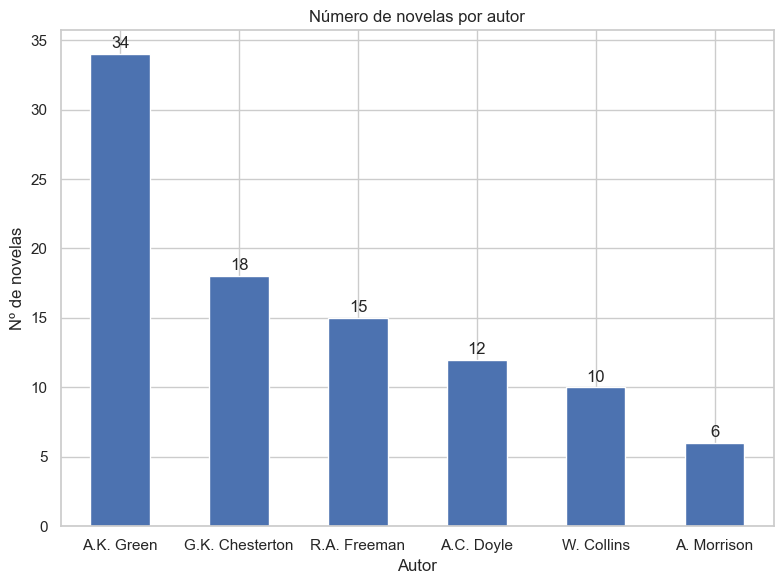

In [15]:
plot_novels_per_author(df_corpus, FIGS_DIR / "works_by_author.png")

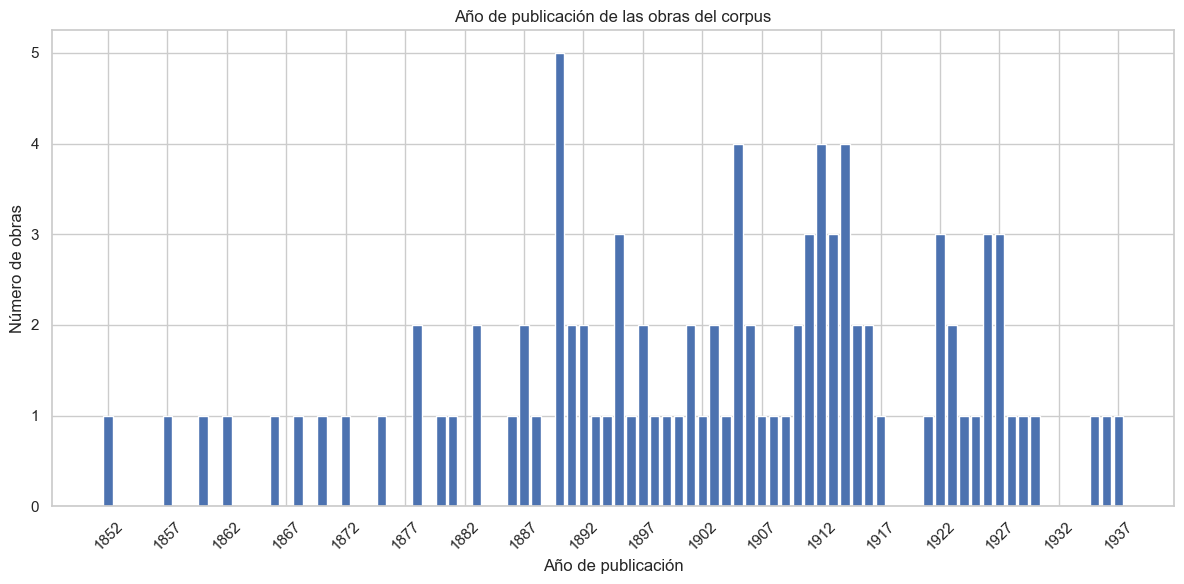

In [16]:
plot_publication_year_distribution(df_corpus, year_col="year", save_path=FIGS_DIR / "publication_year_distribution.png")

In [17]:
print("Distribution by genres:")
print(df_corpus["genre"].value_counts(dropna=False))

print("\nDistribution by types:")
print(df_corpus["type"].value_counts(dropna=False))

Distribution by genres:
genre
mystery       79
fiction       12
scifi          2
terror         1
historical     1
Name: count, dtype: int64

Distribution by types:
type
novel            64
short stories    31
Name: count, dtype: int64


In [18]:
print("Books that do not belong to a saga:", df_corpus["detective"].isna().sum())
print("\nDistribution by detectives:")
print(df_corpus["detective"].value_counts())

Books that do not belong to a saga: 46

Distribution by detectives:
detective
Dr. Thorndyke                         13
Ebenezer Gryce                        10
Sherlock Holmes                        8
Father Brown                           7
Martin Hewit                           4
Caleb Sweetwater                       3
Amelia Butterworth, Ebenezer Gryce     3
Violet Strange                         1
Name: count, dtype: int64


In [19]:
print("Distribution by country of origin:")
print(df_corpus["country"].value_counts(dropna=False))

print("\nLanguage of the works:")
print(df_corpus["language"].value_counts(dropna=False))

Distribution by country of origin:
country
UK     61
USA    34
Name: count, dtype: int64

Language of the works:
language
en    95
Name: count, dtype: int64


In [20]:
print("Distribution by repository:")
print(df_corpus["source"].value_counts(dropna=False))

Distribution by repository:
source
Project Gutemberg USA    77
Project Gutemberg AU     18
Name: count, dtype: int64


In [21]:
print("Distribution by author origin country:")
print(df_corpus["country"].value_counts(dropna=False))

Distribution by author origin country:
country
UK     61
USA    34
Name: count, dtype: int64


## EDA del corpus

Vamos a calcular una serie de métricas para cada obra del corpus que nos permitarán caracterizarlas y compararlas con el resto de obras y hacer comparativas entre autores. Para ello usaremos los textos limpios de cada obra, es decir, los que hemos revisado manualmente para eliminar las anotaciones del *copyright*, índices, notas editoriales y otros elementos que no forman parte del texto de la obra en sí.

Para más información sobre la limpieza manual de los textos, su normalización y el detalle de la tokenización, consultar el apéndice correspondiente de la memoria.

Las métricas calculadas y su descripción son las siguientes:

- `n_tokens_all`: Número total de tokens del texto normalizado.
- `n_tokens_alpha`: Número de tokens alfabéticos del texto normalizado, es decir, aquellos que cumplen la expresión regular `ALPHA_TOKENS` definida en `nlp_utils.py`.
- `n_tokens_not_alpha`: Número de tokens no alfabéticos del texto normalizado, es decir, aquellos que no cumplen la expresión regular `ALPHA_TOKENS` definida en `nlp_utils.py`.
- `non_alpha_token_ratio`: Proporción de tokens no alfabéticos respecto al total de tokens del texto normalizado.
- `n_sentences`: Número de oraciones del texto normalizado.
- `avg_sentence_len`: Longitud media de las oraciones del texto normalizado.
- `median_sentence_len`: Mediana de la longitud de las oraciones del texto normalizado.
- `std_sentence_len`: Desviación estándar de la longitud de las oraciones del texto normalizado.Informa de si el texto mantiene un ritmo sintáctico regular o alterna frases muy cortas y muy largas.
- `sentences_per_1000_tokens`: Número de oraciones por cada 1000 tokens del texto normalizado.
- `short_sentence_ratio`: Proporción de oraciones cortas respecto al total de oraciones del texto normalizado. Se considera una oración corta aquella que tiene 10 o menos tokens alfabéticos.
- `long_sentence_ratio`: Proporción de oraciones largas respecto al total de oraciones del texto normalizado. Se considera una oración larga aquella que tiene 30 o más tokens alfabéticos.
- `n_paragraphs`: Número de párrafos del texto normalizado.
- `avg_paragraph_len`: Longitud media de los párrafos del texto normalizado.
- `median_paragraph_len`: Mediana de la longitud de los párrafos del texto normalizado.
- `paragraphs_per_1000_tokens`: Número de párrafos por cada 1000 tokens del texto normalizado.
- `std_paragraph_len`: Desviación estándar de la longitud de los párrafos del texto normalizado. Informa de si el texto mantiene una estructura de párrafos regular o alterna párrafos muy cortos y muy largos.
- `avg_sentences_per_paragraph`: Número medio de oraciones por párrafo del texto normalizado.
- `median_sentences_per_paragraph`: Mediana del número de oraciones por párrafo del texto normalizado.
- `n_chars`: Longitud total del texto normalizado en caracteres.
- `non_alpha_ratio`: Proporción de caracteres no alfabéticos respecto al total de caracteres del texto normalizado.
- `digit_ratio`: Proporción de caracteres dígitos respecto al total de caracteres del texto normalizado.
- `whitespace_ratio`: Proporción de caracteres de espacio en blanco respecto al total de caracteres del texto normalizado.
- `n_types`: Número de palabras alfabéticas distintas presentes en el texto.
- `ttr`: *Type-Token Ratio*, proporción entre el número de tipos y el número total de palabras alfabéticas.
- `hapax_count`: Número de palabras alfabéticas que aparecen una sola vez en el texto.
- `hapax_ratio`: Proporción de palabras alfabéticas únicas respecto al total de tipos.
- `avg_word_len`: Longitud media de las palabras alfabéticas del texto.
- `median_word_len`: Mediana de la longitud de las palabras alfabéticas del texto.
- `long_word_ratio`: Proporción de palabras largas respecto al total de palabras alfabéticas. Se considera una palabra larga aquella que tiene 8 o más caracteres alfabéticos.
- `mattr_100`: *Moving Average Type-Token Ratio* con una ventana de 100 tokens calcula la media de las proporciones de tipos respecto a tokens en ventanas móviles de 100 palabras alfabéticas a lo largo del texto.
- `stopword_ratio`: Proporción de palabras que son stopwords respecto al total de tokens de palabras alfabéticas.
- `comma_count`: Recuento total de comas en el texto normalizado.
- `period_count`: Recuento total de puntos en el texto normalizado.
- `semicolon_count`: Recuento total de puntos y coma en el texto normalizado.
- `colon_count`: Recuento total de dos puntos en el texto normalizado.
- `exclam_count`: Recuento total de signos de exclamación en el texto normalizado.
- `question_count`: Recuento total de signos de interrogación en el texto normalizado.
- `ellipsis_count`: Recuento total de puntos suspensivos en el texto normalizado.
- `quote_count`: Recuento total de comillas en el texto normalizado.
- `dialog_dash_count`: Recuento total de guiones de diálogo en el texto normalizado.
- `hyphen_count`: Recuento total de guiones en el texto normalizado.
- `parenthesis_count`: Recuento total de paréntesis en el texto normalizado.
- `punctuation_count_total`: Recuento total de signos de puntuación (comas, puntos, puntos y coma, dos puntos, signos de exclamación, signos de interrogación, puntos suspensivos, comillas, guiones de diálogo, guiones y paréntesis) en el texto normalizado.
- `punctuation_ratio`: Proporción de signos de puntuación respecto al total de caracteres del texto normalizado.
- `comma_count_per_1000`: Número de comas por cada 1000 tokens de palabras alfabéticas en el texto normalizado.
- `period_count_per_1000`: Número de puntos por cada 1000 tokens de palabras alfabéticas en el texto normalizado.
- `semicolon_count_per_1000`: Número de puntos y coma por cada 1000 tokens de palabras alfabéticas en el texto normalizado.
- `colon_count_per_1000`: Número de dos puntos por cada 1000 tokens de palabras alfabéticas en el texto normalizado.
- `exclam_count_per_1000`: Número de signos de exclamación por cada 1000 tokens de palabras alfabéticas en el texto normalizado.
- `question_count_per_1000`: Número de signos de interrogación por cada 1000 tokens de palabras alfabéticas en el texto normalizado.
- `ellipsis_count_per_1000`: Número de puntos suspensivos por cada 1000 tokens de palabras alfabéticas en el texto normalizado.
- `quote_count_per_1000`: Número de comillas por cada 1000 tokens de palabras alfabéticas en el texto normalizado.
- `dialog_dash_count_per_1000`: Número de guiones de diálogo por cada 1000 tokens de palabras alfabéticas en el texto normalizado.

In [22]:
# Cálculo de métricas para cada obra del corpus
# Este proceso puede tardar unos minutos, dependiendo
# del número de obras y su tamaño
metrics_list = []

for book in tqdm(df_corpus["path"]):
    text = read_book_text(Path(book))
    row_metrics = compute_novel_metrics(text, STOPWORDS)
    metrics_list.append(row_metrics)

metrics_df = pd.DataFrame(metrics_list)

df_corpus = pd.concat([df_corpus.reset_index(drop=True), metrics_df.reset_index(drop=True)], axis=1)

  0%|          | 0/95 [00:00<?, ?it/s]

In [23]:
# Guardo el dataframe con las métricas calculadas
# para que no sea necesario volver a calcularlas cada
# vez que queramos hacer un análisis exploratorio del corpus
df_corpus.to_csv(TABLES_DIR / "corpus_eda_metrics.csv", index=False)

In [24]:
# Cargamos las métricas pre-calculadas para cada obra del corpus
df_corpus = pd.read_csv(TABLES_DIR / "corpus_eda_metrics.csv")
print(df_corpus.shape)
df_corpus.head()

(95, 72)


,file_name,author,title,year,type,detective,genre,language,country,source,...,period_count_per_1000,semicolon_count_per_1000,colon_count_per_1000,exclam_count_per_1000,question_count_per_1000,ellipsis_count_per_1000,quote_count_per_1000,dialog_dash_count_per_1000,hyphen_count_per_1000,parenthesis_count_per_1000
0,acd-a_study_in_scarlet.txt,A.C. Doyle,A Study in Scarlet,1887,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.709489,1.975234,0.265897,1.614374,3.969460,0.000000,32.249487,2.222138,4.938084,0.075971
1,acd-tales_of_terror_and_mystery.txt,A.C. Doyle,Tales of Terror and Mystery,1890,short stories,NaN,terror,en,UK,Project Gutemberg USA,...,43.183733,1.033534,0.752682,1.819918,3.089367,0.067404,19.479863,3.021963,5.392350,0.584171
2,acd-the_adventures_of_sherlock_holmes.txt,A.C. Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.670706,1.554145,0.430852,2.662050,5.678015,0.000000,39.153683,1.469513,5.678015,0.076938
3,acd-the_case_book_of_sherlock_holmes.txt,A.C. Doyle,The case-book of Sherlock Holmes,1921,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,57.379835,0.650719,0.233093,3.224459,7.128774,0.097122,41.102143,3.690646,5.234890,0.038849
4,acd-the_hound_of_the_baskervilles.txt,A.C. Doyle,The Hound of the Baskervilles,1901,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.648868,0.626226,0.222658,2.532738,7.208561,0.000000,38.561628,2.170918,3.687777,0.139161


### Métricas de calidad de los textos del corpus

Estas métricas se calculan para evaluar la calidad superficial y la consistencia de cada texto antes del análisis estilométrico. En lugar de medir directamente el estilo literario, capturan propiedades básicas sobre la composición de los textos, como la proporción de caracteres no alfabéticos, dígitos y espacios en blanco, y permiten detectar posibles problemas de extracción, ruido del OCR, numeración de páginas, metadatos incrustados o diferencias en el formato editorial. Esto es importante porque un texto "sucio" o mal preprocesado puede introducir sesgos y hacer que aparentes diferencias estilísticas entre obras o autores sean en realidad artefactos del preprocesado.

La detección de *outliers* dentro del corpus para algunas de estas métricas, es decir, valores anómalos en `digit_ratio`, `non_alpha_ratio` o `whitespace_ratio`, pueden señalar obras que requieren una revisión manual o limpieza adicional antes de incorporarlas al análisis principal. Por tanto, funcionan como una capa de control de calidad del corpus, ayudando a garantizar que las comparaciones estilométricas se basen en rasgos lingüísticos reales y no en anomalías del texto.

In [25]:
# Buscamos posibles outliers en las métricas relacionadas
# con la calidad de los textos del corpus
metric_cols = [
    "n_chars",
    "non_alpha_ratio",
    "digit_ratio",
    "whitespace_ratio",
]

df_checked, outlier_summary_df = add_iqr_outlier_flags(df_corpus, metric_cols)

In [26]:
outlier_summary_df

,q1,q3,iqr,lower_bound,upper_bound,n_outliers,n_low_outliers,n_high_outliers
n_chars,321513.000000,563759.500000,242246.500000,-41856.750000,927129.250000,5.0,0.0,5.0
non_alpha_ratio,0.222195,0.228398,0.006202,0.212891,0.237701,1.0,0.0,1.0
digit_ratio,0.000035,0.000177,0.000142,-0.000177,0.000390,5.0,0.0,5.0
whitespace_ratio,0.186348,0.191107,0.004760,0.179208,0.198247,0.0,0.0,0.0


In [27]:
df_checked[df_checked["has_any_outlier"]][["file_name", "outlier_metrics"]]

,file_name,outlier_metrics
2,acd-the_adventures_of_sherlock_holmes.txt,[digit_ratio (high)]
10,acd-the_valley_of_fear.txt,[digit_ratio (high)]
32,akg-the_forsaken_inn.txt,[digit_ratio (high)]
50,am-the_red_triangle.txt,[digit_ratio (high)]
51,am-the_hole_in_the_wall.txt,[non_alpha_ratio (high)]
76,raf-the_exploits_of_danby_croke.txt,[digit_ratio (high)]
85,wc-armadale.txt,[n_chars (high)]
87,wc-man_and_wife.txt,[n_chars (high)]
88,wc-no_name.txt,[n_chars (high)]
93,wc-the_moonstone.txt,[n_chars (high)]


Como vemos, varias novelas de Wilkie Collins aparecen como *outliers* en el corpus para el número de caracteres. Como sabemos, estas son obras largas y conocidas por su extensión, así que aquí `n_chars` no necesariamente señala un problema de calidad, sino una diferencia real de longitud.

Vamos a analizar más en detalle los *outliers* detectados para `digit_ratio` para ver si se trata de un problema de calidad del texto o si, por el contrario, es una característica real de la obra. Para ello, vamos a imprimir algunas muestras de las líneas de los textos que contienen dígitos para ver de este modo si se trata de numeración de páginas, metadatos incrustados o algún otro tipo de contenido que no forma parte del texto de la obra en sí.

In [28]:
# Nos quedamos con los outliers detectados para `digit_ratio`
digit_outliers = df_checked[df_checked["outlier_metrics"].apply(lambda xs: "digit_ratio (high)" in xs)]
digit_outliers

digit_outliers[["file_name", "outlier_metrics", "path"]]

,file_name,outlier_metrics,path
2,acd-the_adventures_of_sherlock_holmes.txt,[digit_ratio (high)],../corpus/hand_cleaned/arthur_conan_doyle/acd-...
10,acd-the_valley_of_fear.txt,[digit_ratio (high)],../corpus/hand_cleaned/arthur_conan_doyle/acd-...
32,akg-the_forsaken_inn.txt,[digit_ratio (high)],../corpus/hand_cleaned/anna_katharine_green/ak...
50,am-the_red_triangle.txt,[digit_ratio (high)],../corpus/hand_cleaned/arthur_morrison/am-the_...
76,raf-the_exploits_of_danby_croke.txt,[digit_ratio (high)],../corpus/hand_cleaned/richard_austin_freeman/...


In [29]:
# Imprimimos algunos fragmentos de los textos
# de los outliers detectados para `digit_ratio`
for path in digit_outliers["path"]:
    text = read_book_text(Path(path))
    lines_with_digits = [line for line in text.splitlines() if re.search(r"\d", line)]

    print("=" * 80)
    print(f"{path}\n")
    print("\n".join(random.sample(lines_with_digits, 20)))

../corpus/hand_cleaned/arthur_conan_doyle/acd-the_adventures_of_sherlock_holmes.txt

“The letter arrived on March 10, 1883. His death was seven weeks later,
“‘Oh, at his new offices. He did tell me the address. Yes, 17 King
One night—it was on the twentieth of March, 1888—I was returning from a
“No. 31 Lyon Place, Camberwell.”
contains 2,000 napoleons packed between layers of lead foil. Our
pen. Better make it out for £ 4000.”
“‘December 22nd. Twenty-four geese at 7_s_. 6_d_.’”
50,000 at once. I could, of course, borrow so trifling a sum ten times
eccentricity. Very few governesses in England are getting £ 100 a year.
“Of Friday, June 19th.”
to be forwarded to 226 Gordon Square; so thither I travelled, and being
some £ 30,000; and for you, Jones, it will be the man upon whom you
the 9th inst., Mr. Jeremiah Hayling, aged twenty-six, a hydraulic
“Hotel Cosmopolitan Jewel Robbery. John Horner, 26, plumber, was
some £ 14,000, which lay to his credit at the bank.”
£ 2.
brought up upon the c

No parece que haya un problema de calidad en estos textos, sino que se trata de una característica real de las obras, es decir, los dígitos forman parte del texto de la obra en sí, ya sea como parte de la narración o como parte de la estructura de la obra (por ejemplo, numeración de capítulos). Por tanto, no voy a eliminar estas obras del corpus ni a limpiar los dígitos de los textos, ya que esto podría eliminar información estilística relevante para el análisis estilométrico.

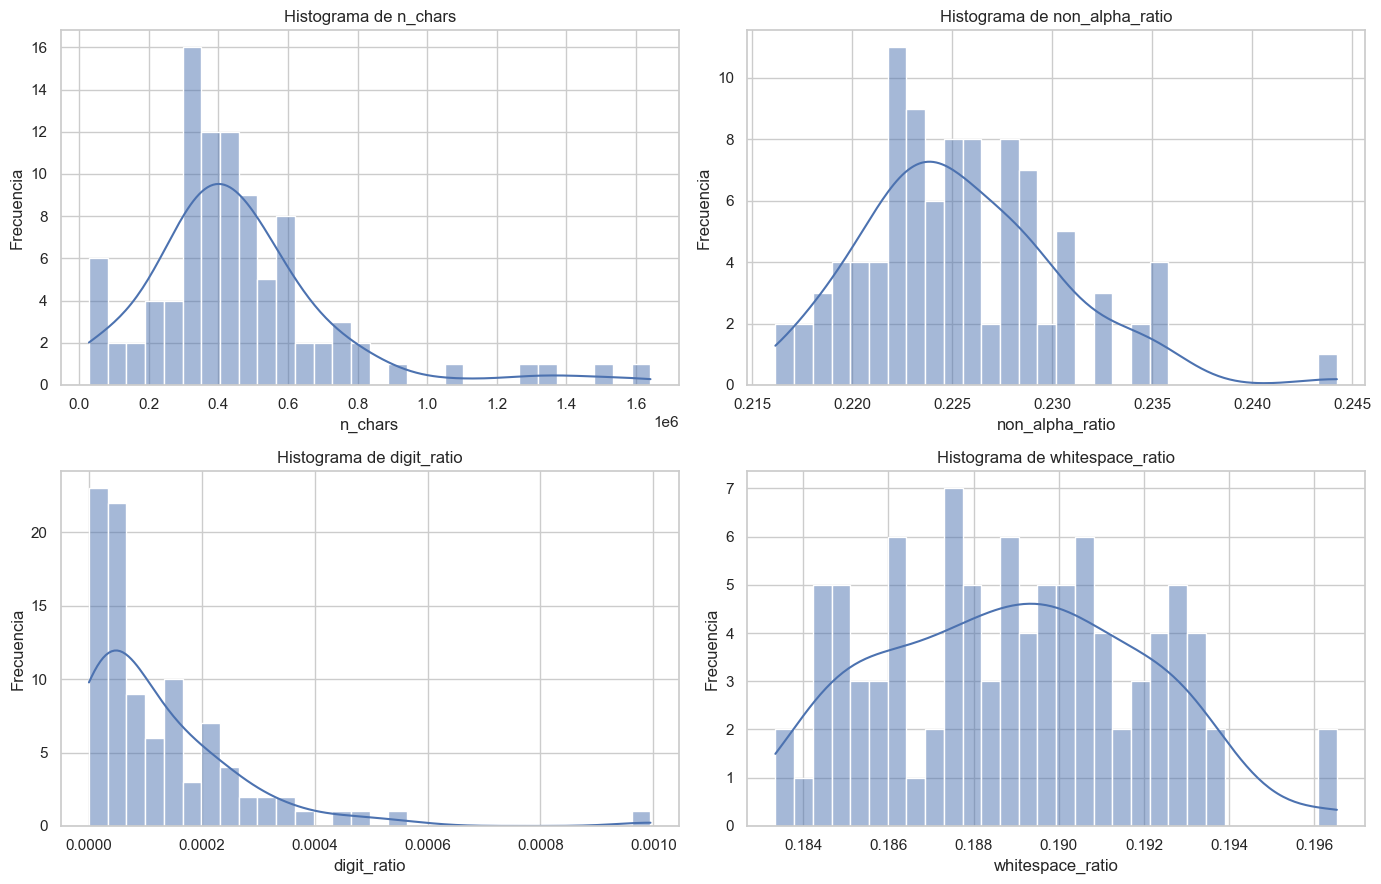

In [30]:
metrics = [
    "n_chars",
    "non_alpha_ratio",
    "digit_ratio",
    "whitespace_ratio",
]

plot_metrics_histograms(df_corpus, metrics, save_path=FIGS_DIR / "quality_metrics_histograms.png")

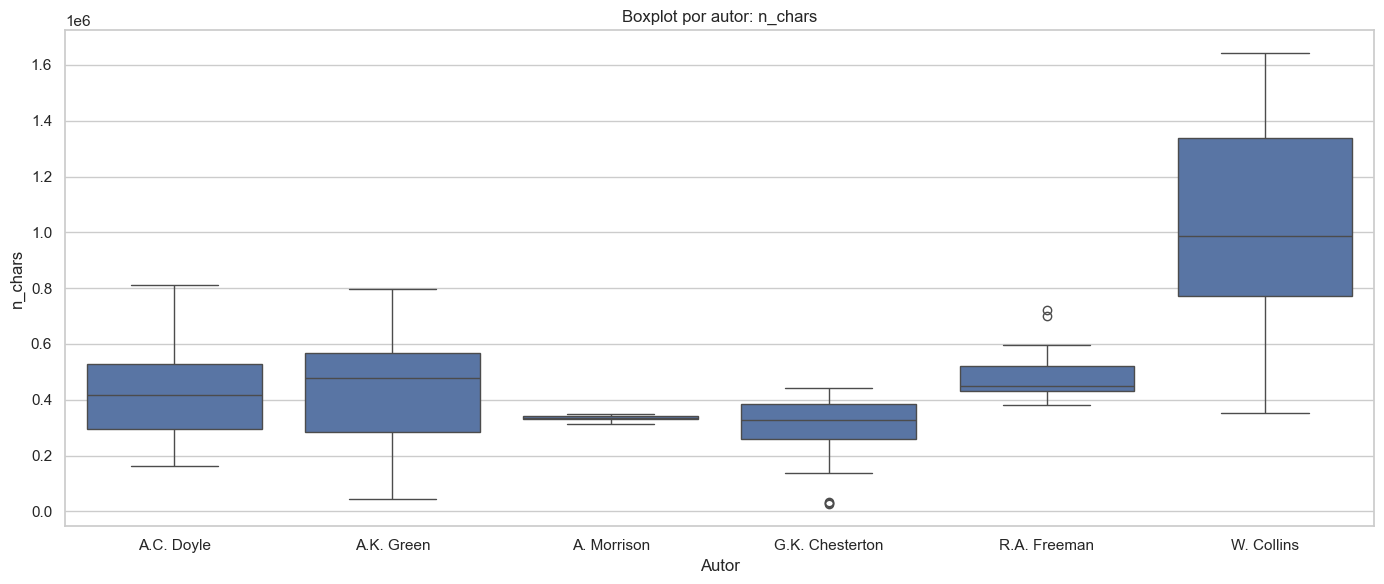

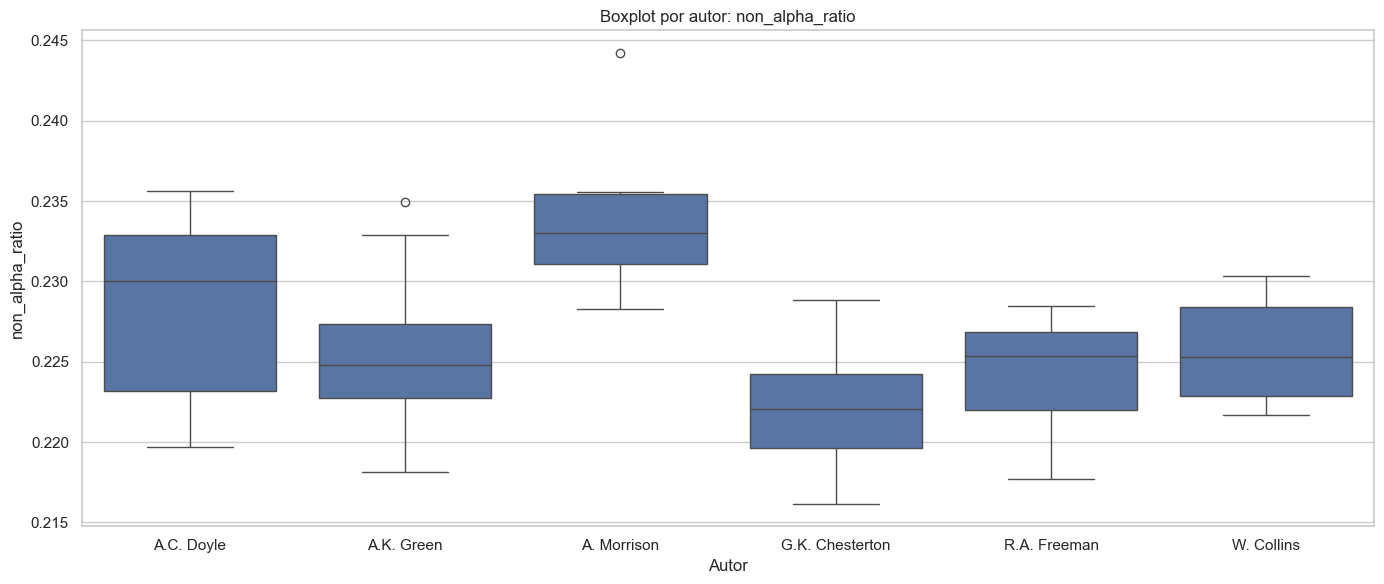

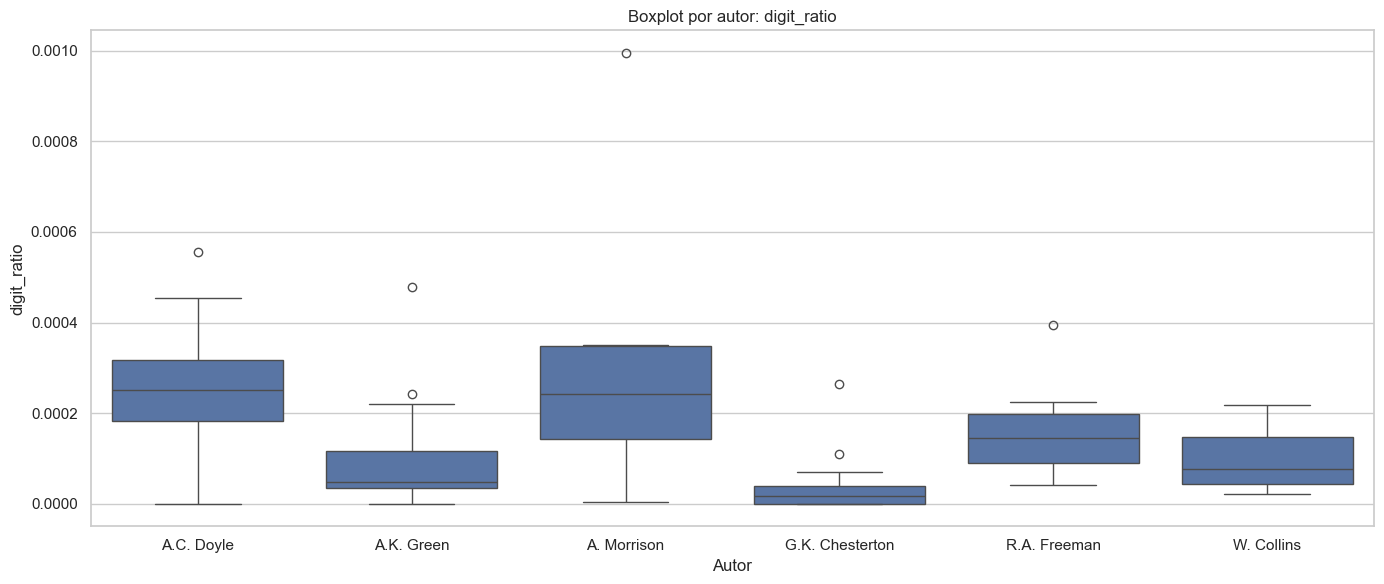

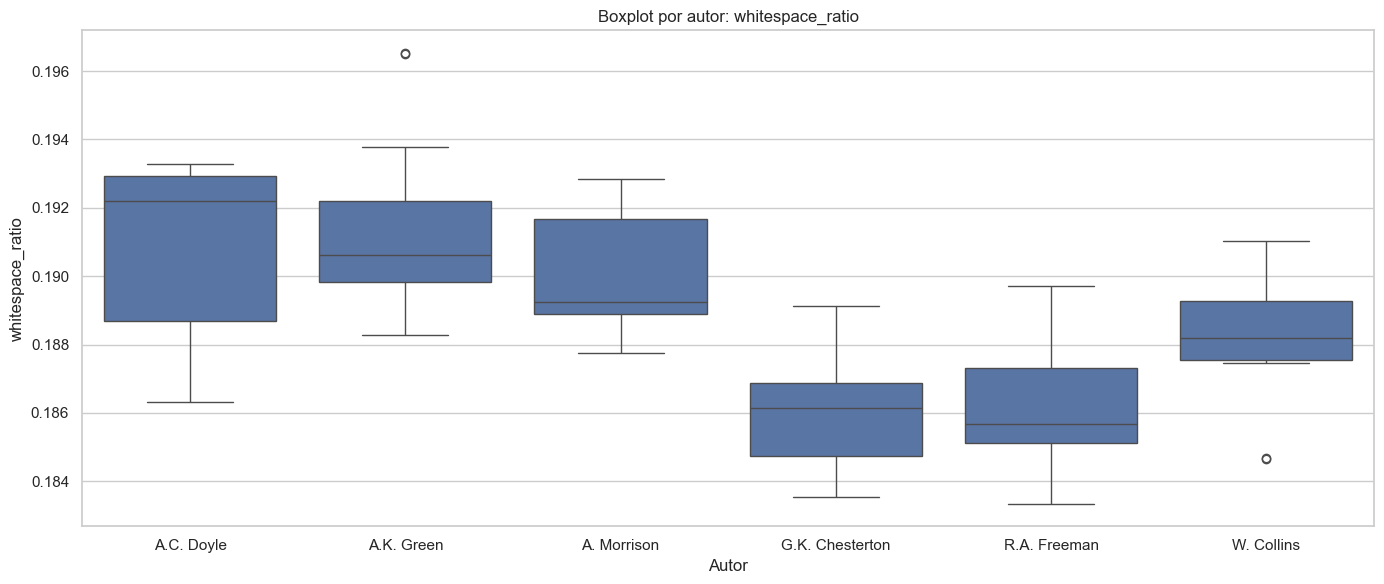

In [31]:
plot_metrics_boxplots_by_author(df_corpus, metrics, save_path=FIGS_DIR / "quality_metrics_boxplots.png")

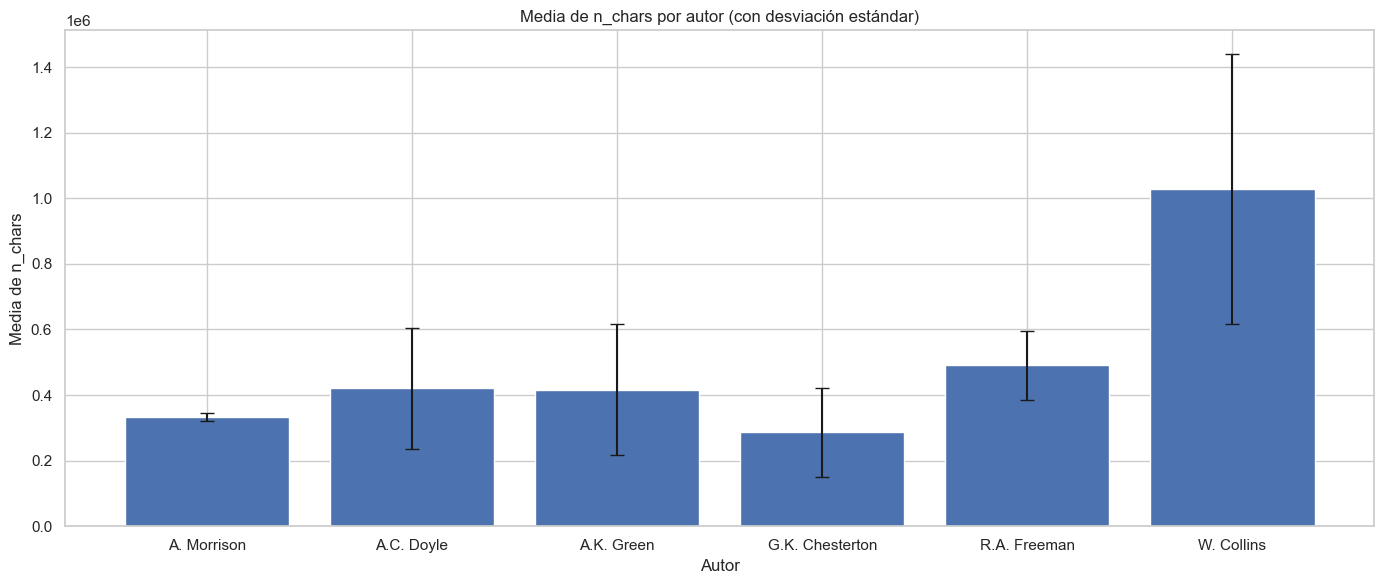

In [32]:
plot_bars_by_author_with_std(df_corpus, ["n_chars"], agg="mean", save_path=FIGS_DIR / "bars_by_author_with_std.png")

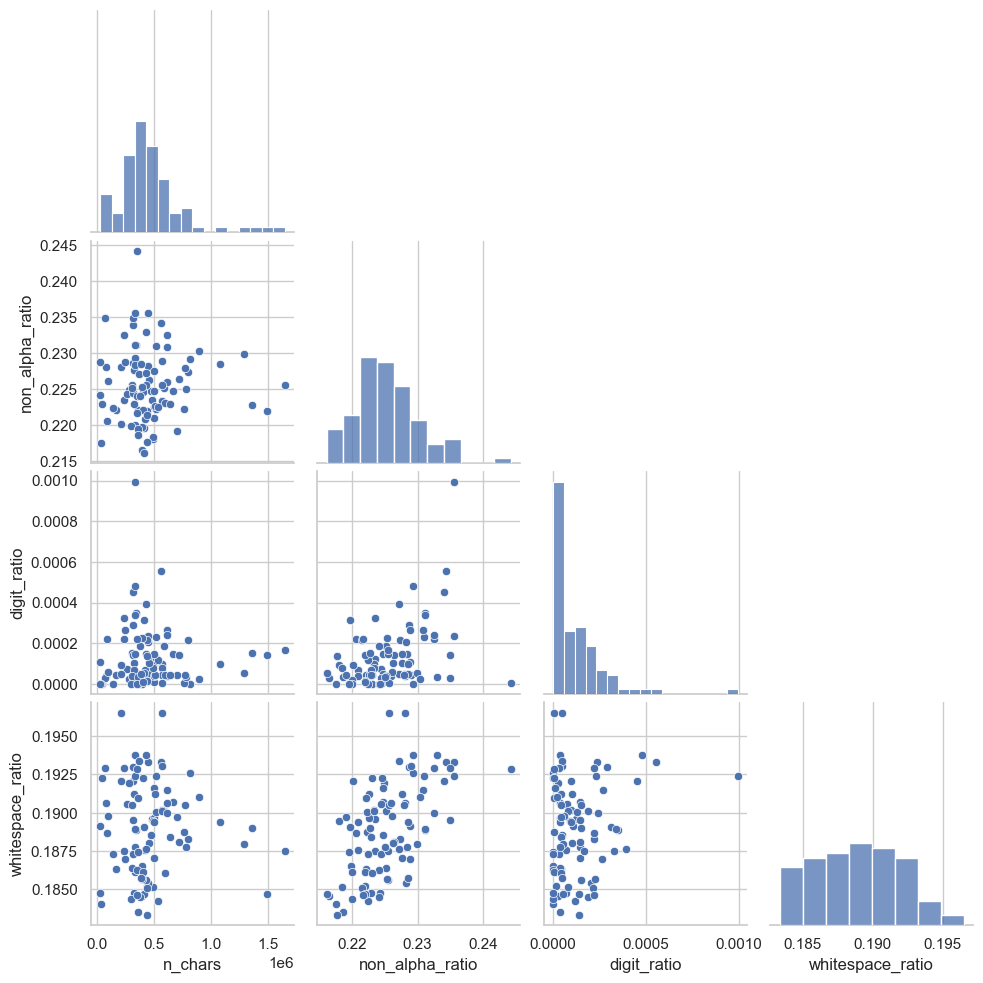

In [33]:
# Mostramos una matriz de dispersión para visualizar
# las relaciones entre las métricas de calidad
sns.pairplot(df_corpus[metrics], corner=True, diag_kind="hist");

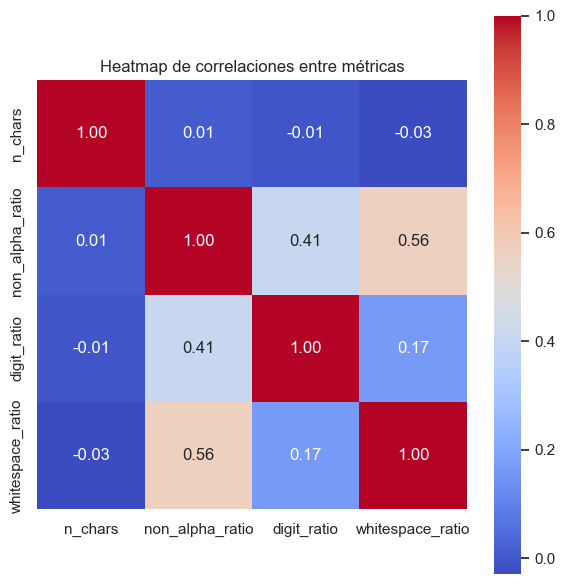

In [34]:
plot_metrics_correlations_heatmap(df_corpus, metrics, save_path=FIGS_DIR / "quality_metrics_correlations_heatmap.png")

### Métricas de longitud y estructurales

Pasemos ahora a analizar las métricas relacionadas con la longitud y la estructura de los textos, donde variables como el número de tokens, la longitud media de las frases, la longitud media de los párrafos o el número total de frases y párrafos aportan información sobre la extensión de los textos y sobre su organización interna.

Estas medidas pueden considerarse rasgos estilométricos de nivel superficial, en la medida en que capturan propiedades formales del texto que, aun siendo relativamente simples, pueden contribuir a identificar diferencias de estilo entre autores o entre obras. Así, por ejemplo, una mayor longitud media de frase puede asociarse a una sintaxis más elaborada, mientras que la distribución de los párrafos puede ofrecer información sobre cómo el autor organiza su discurso.

In [35]:
metric_cols = [
    "n_tokens_all",
    "n_tokens_alpha",
    "n_tokens_not_alpha",
    "non_alpha_token_ratio",
    "n_sentences",
    "avg_sentence_len",
    "median_sentence_len",
    "std_sentence_len",
    "sentences_per_1000_tokens",
    "short_sentence_ratio",
    "long_sentence_ratio",
    "n_paragraphs",
    "avg_paragraph_len",
    "median_paragraph_len",
    "std_paragraph_len",
    "paragraphs_per_1000_tokens",
    "avg_sentences_per_paragraph",
    "median_sentences_per_paragraph",
]

df_checked, outlier_summary_df = add_iqr_outlier_flags(df_corpus, metric_cols)

In [36]:
outlier_summary_df

,q1,q3,iqr,lower_bound,upper_bound,n_outliers,n_low_outliers,n_high_outliers
n_tokens_all,71553.500000,124436.000000,52882.500000,-7770.250000,203759.750000,5.0,0.0,5.0
n_tokens_alpha,58830.000000,104413.000000,45583.000000,-9544.500000,172787.500000,5.0,0.0,5.0
n_tokens_not_alpha,12440.000000,21224.000000,8784.000000,-736.000000,34400.000000,6.0,0.0,6.0
non_alpha_token_ratio,0.161153,0.184289,0.023137,0.126448,0.218994,0.0,0.0,0.0
n_sentences,3442.500000,5844.000000,2401.500000,-159.750000,9446.250000,7.0,0.0,7.0
avg_sentence_len,16.313471,19.065883,2.752411,12.184855,23.194500,2.0,1.0,1.0
median_sentence_len,13.000000,15.500000,2.500000,9.250000,19.250000,3.0,1.0,2.0
std_sentence_len,12.001009,15.461063,3.460054,6.810929,20.651144,0.0,0.0,0.0
sentences_per_1000_tokens,44.081956,50.116729,6.034772,35.029798,59.168888,5.0,1.0,4.0
short_sentence_ratio,0.286530,0.369398,0.082868,0.162227,0.493700,1.0,0.0,1.0


In [37]:
df_checked[df_checked["has_any_outlier"]][["file_name", "outlier_metrics"]]

,file_name,outlier_metrics
3,acd-the_case_book_of_sherlock_holmes.txt,[sentences_per_1000_tokens (high)]
9,acd-the_sign_of_the_four.txt,[median_sentences_per_paragraph (high)]
21,akg-hand_and_ring.txt,"[n_paragraphs (high), median_sentences_per_par..."
30,akg-the_doctor_his_wife_and_the_clock.txt,"[median_sentence_len (high), long_sentence_rat..."
35,akg-the_leavenworth_case.txt,[median_sentences_per_paragraph (low)]
39,akg-the_old_stone_house_and_other_stories.txt,[long_sentence_ratio (high)]
43,akg-three_thousand_dollars.txt,"[avg_sentence_len (low), median_sentence_len (..."
47,am-chronicles_of_martin_hewitt.txt,[median_sentences_per_paragraph (high)]
48,am-martin_hewitt_investigator.txt,[median_sentences_per_paragraph (high)]
49,am-the_dorrington_deed_box.txt,"[std_paragraph_len (high), median_sentences_pe..."


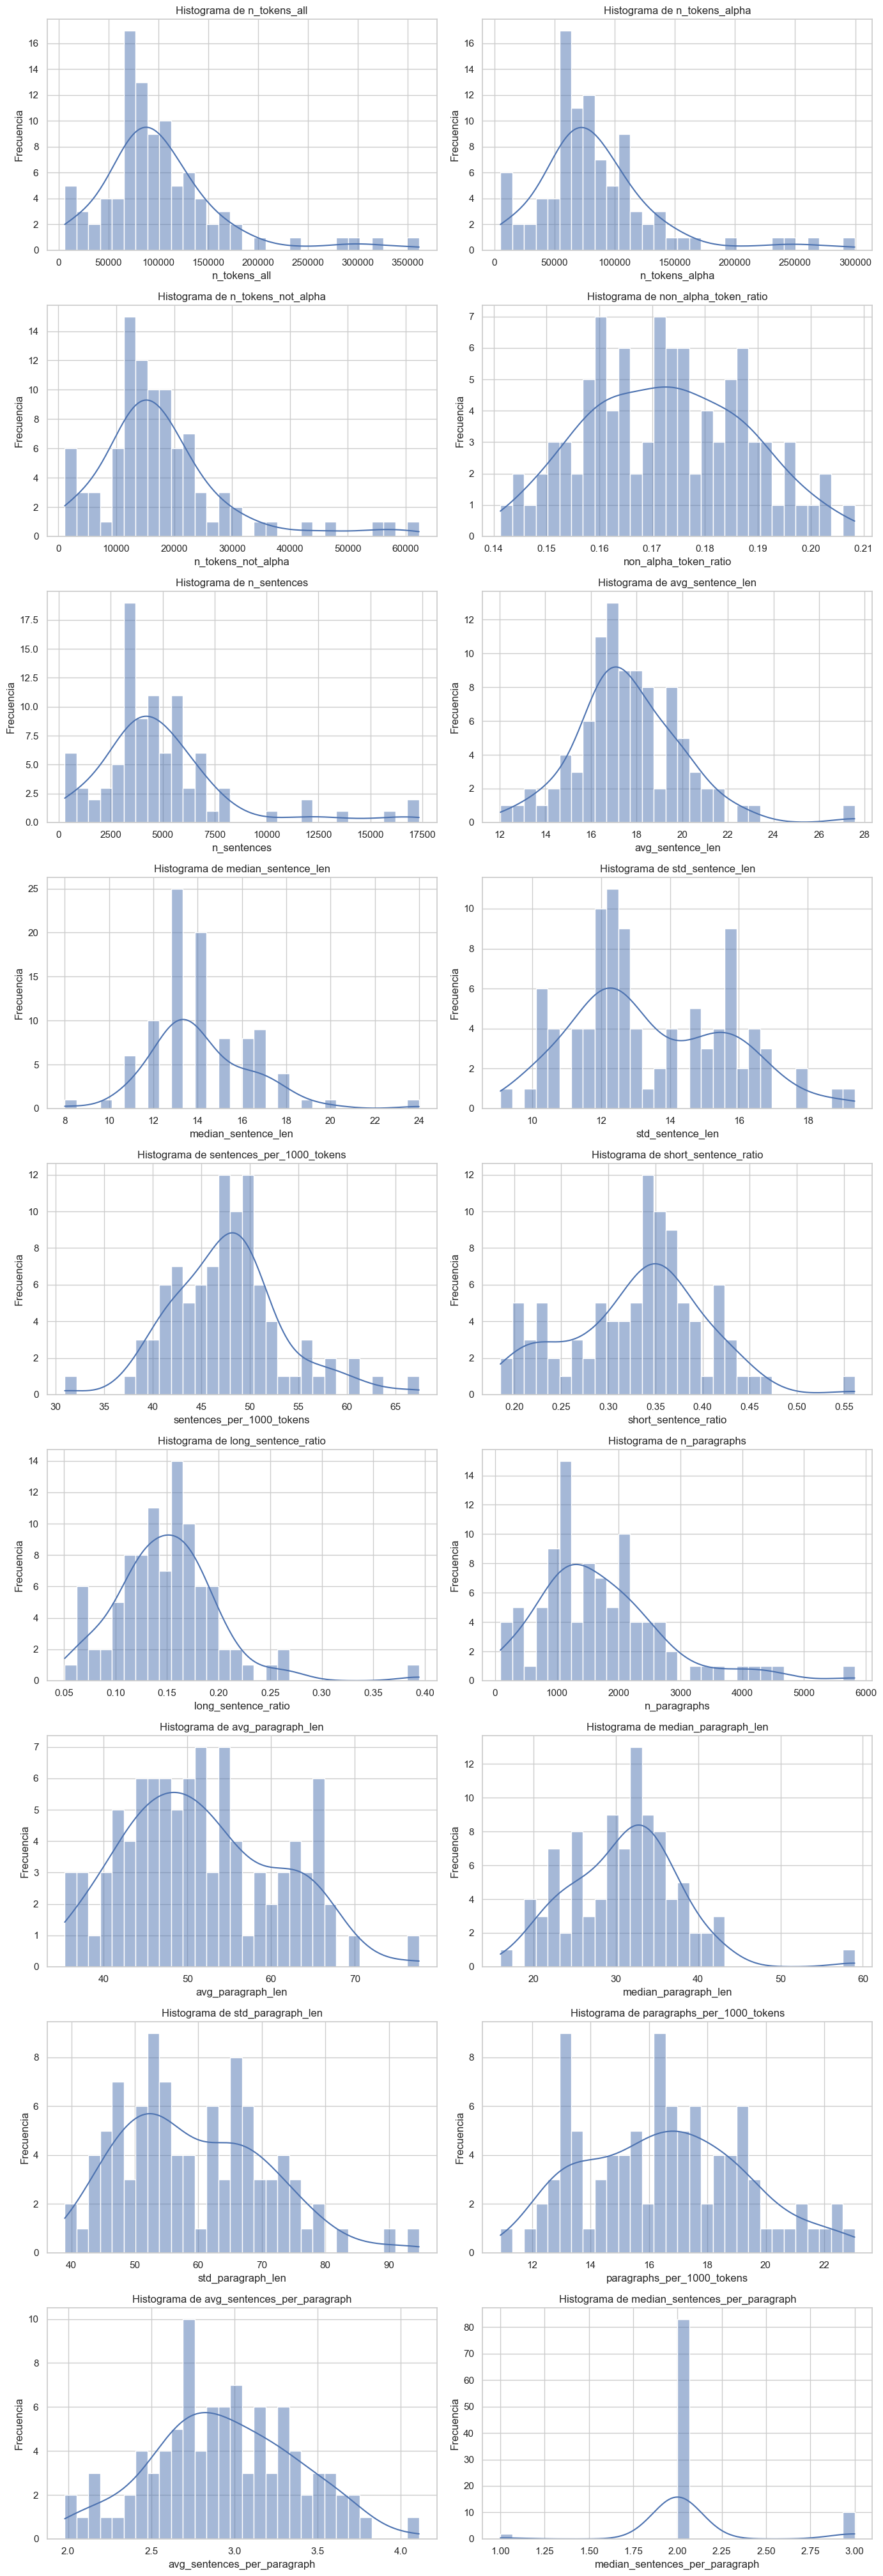

In [38]:
plot_metrics_histograms(df_corpus, metric_cols, save_path=FIGS_DIR / "structural_metrics_histograms.png")

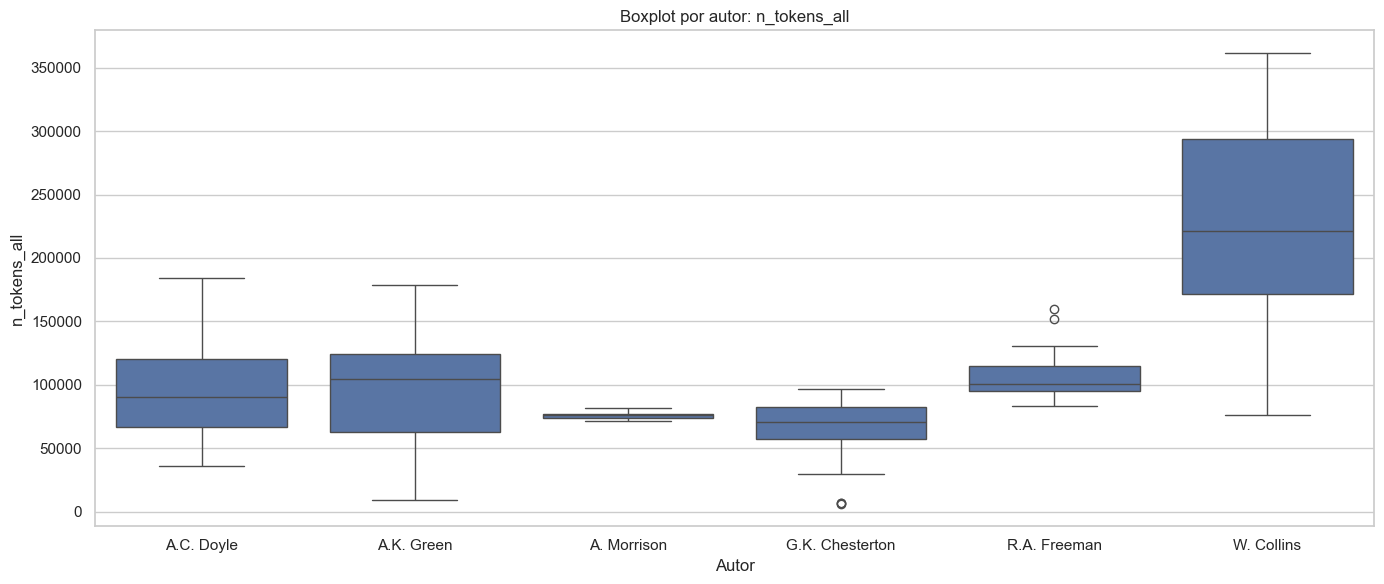

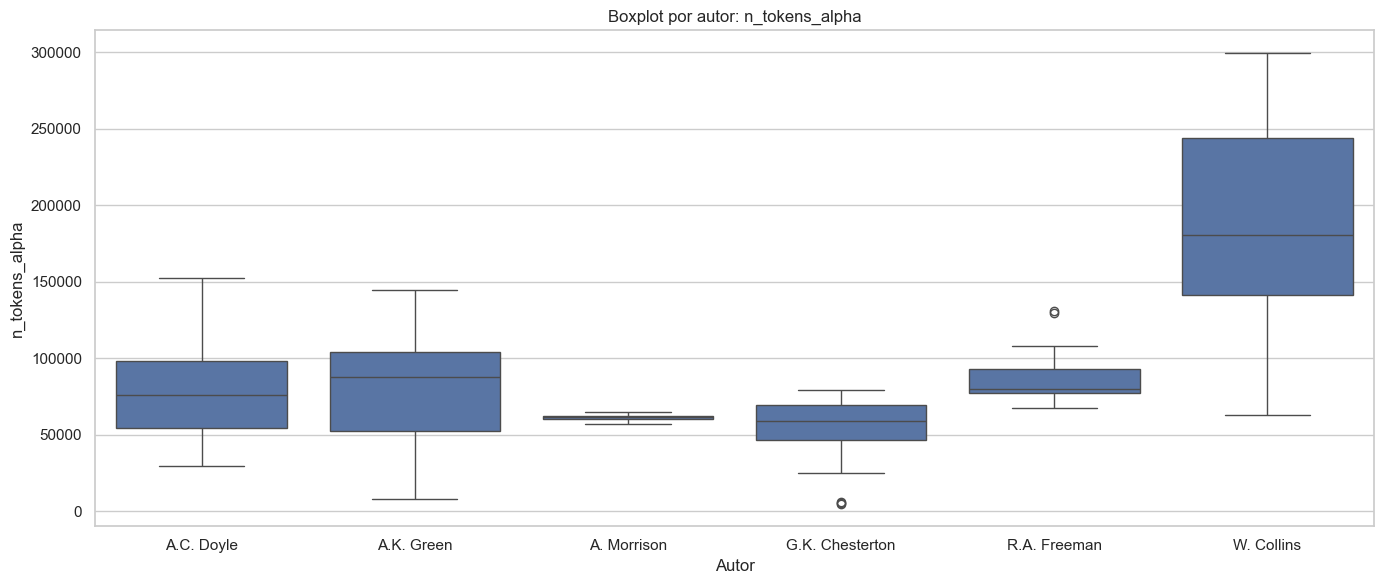

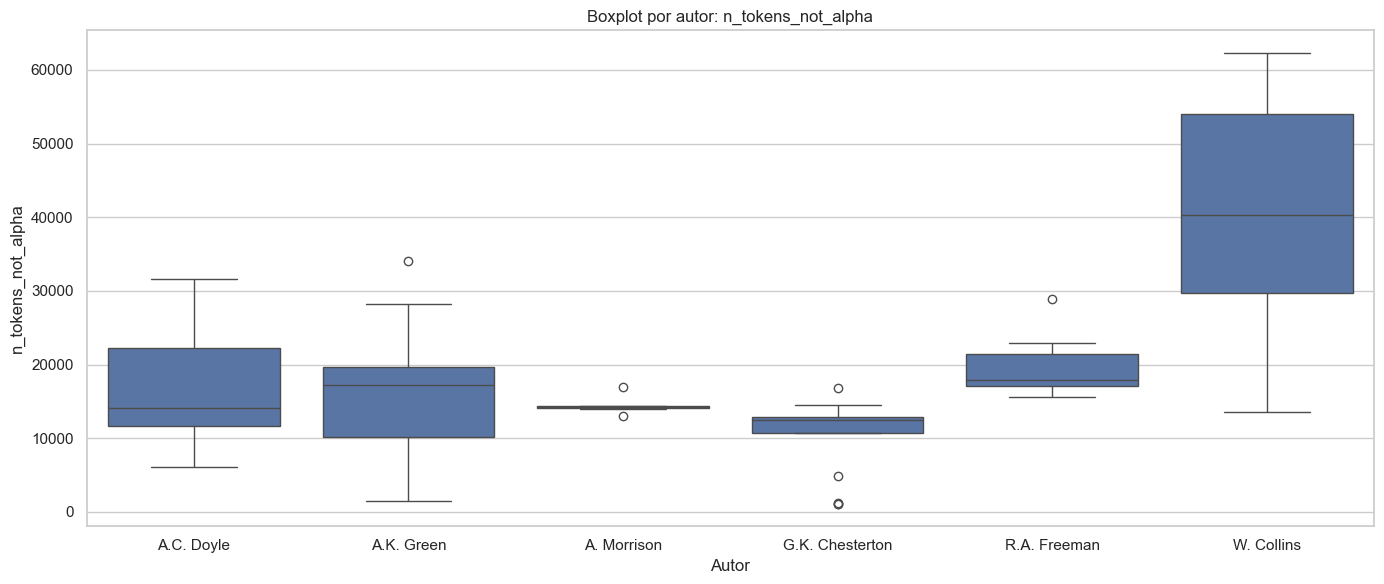

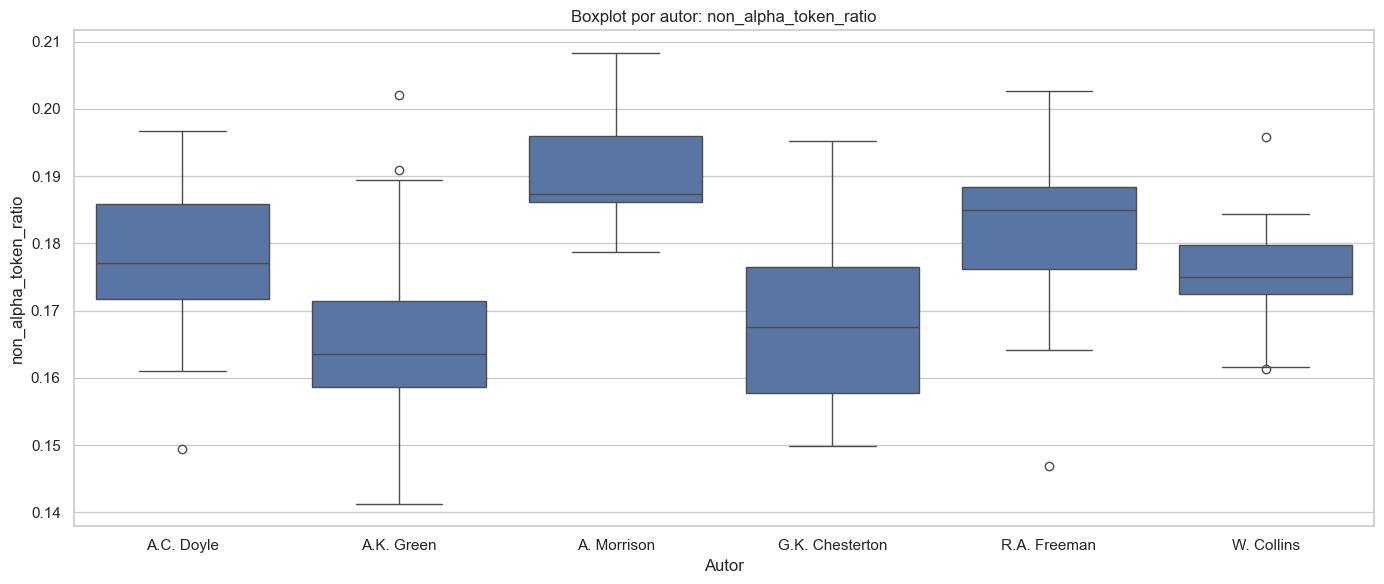

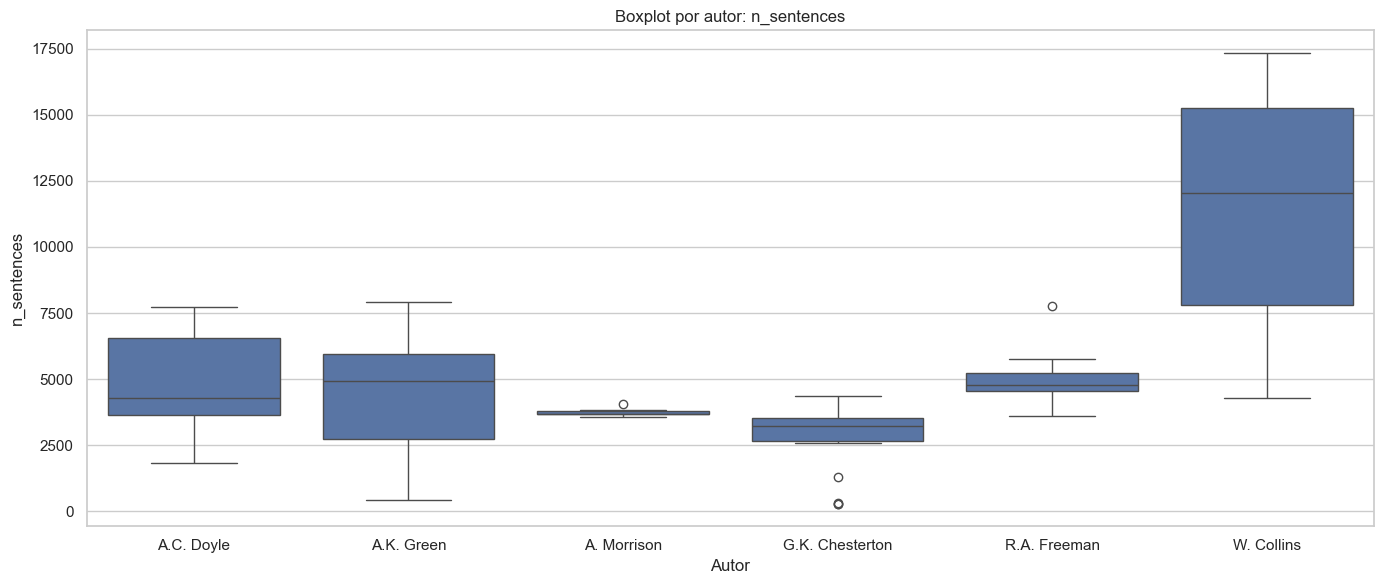

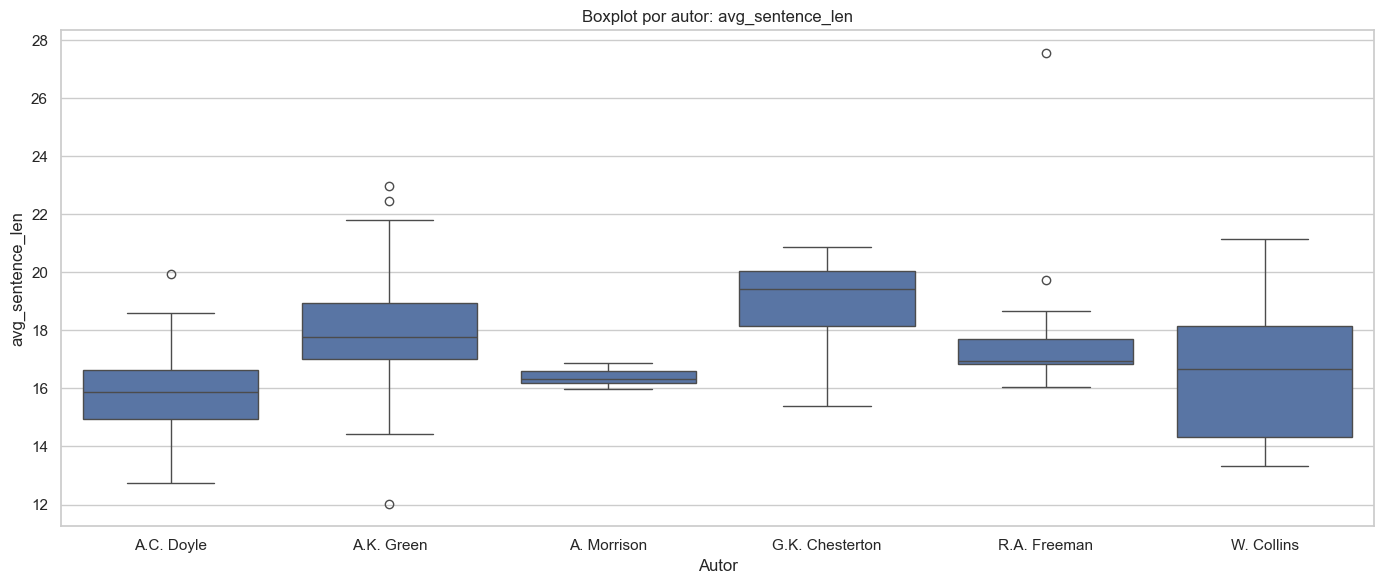

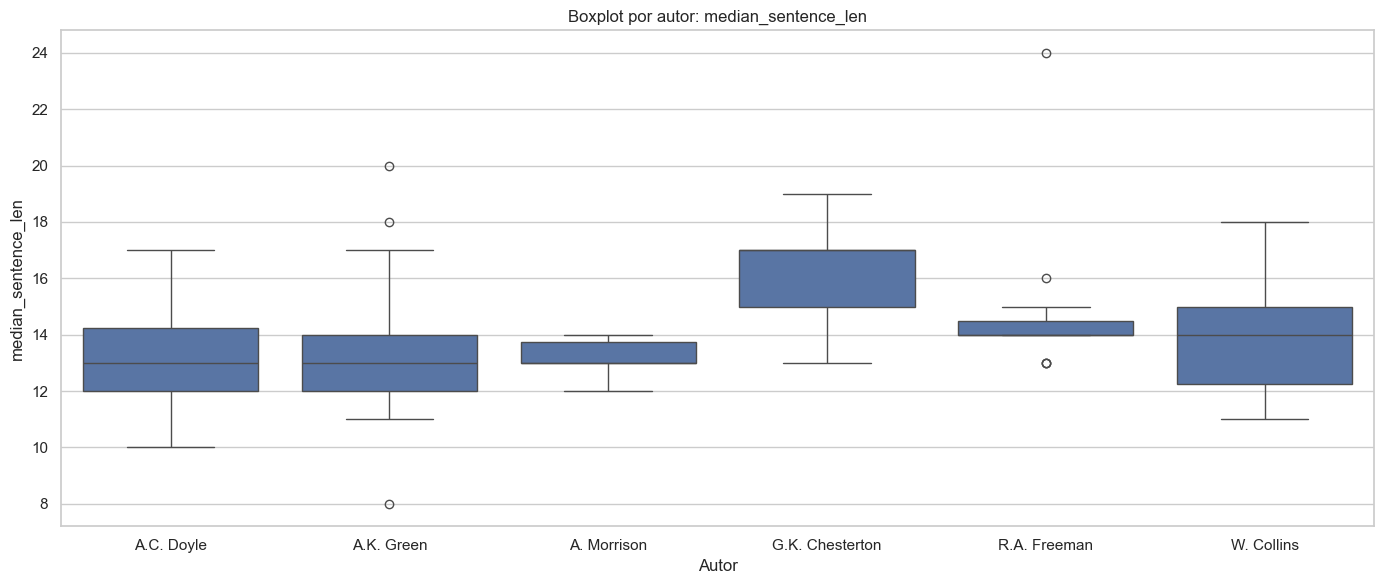

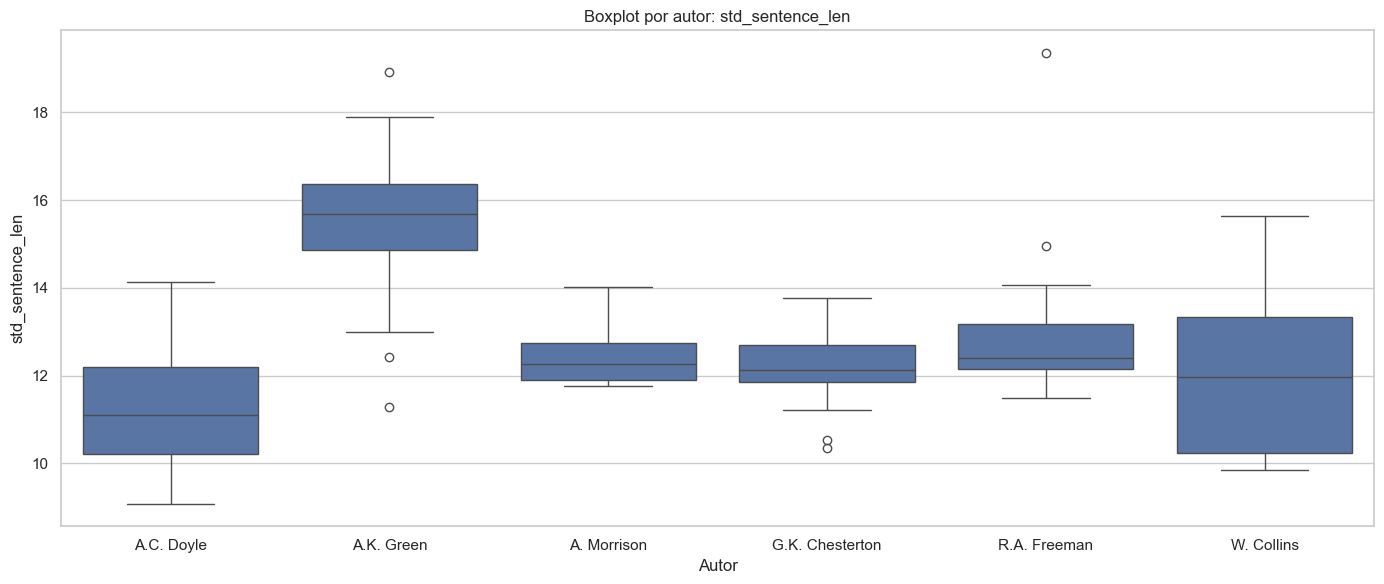

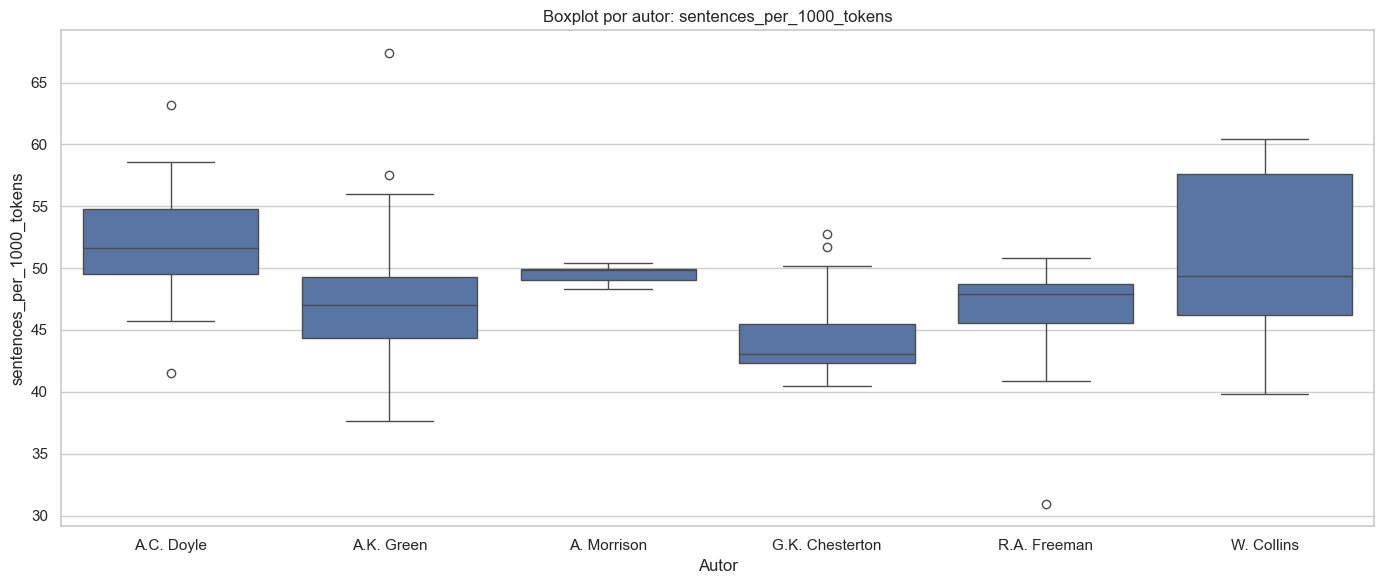

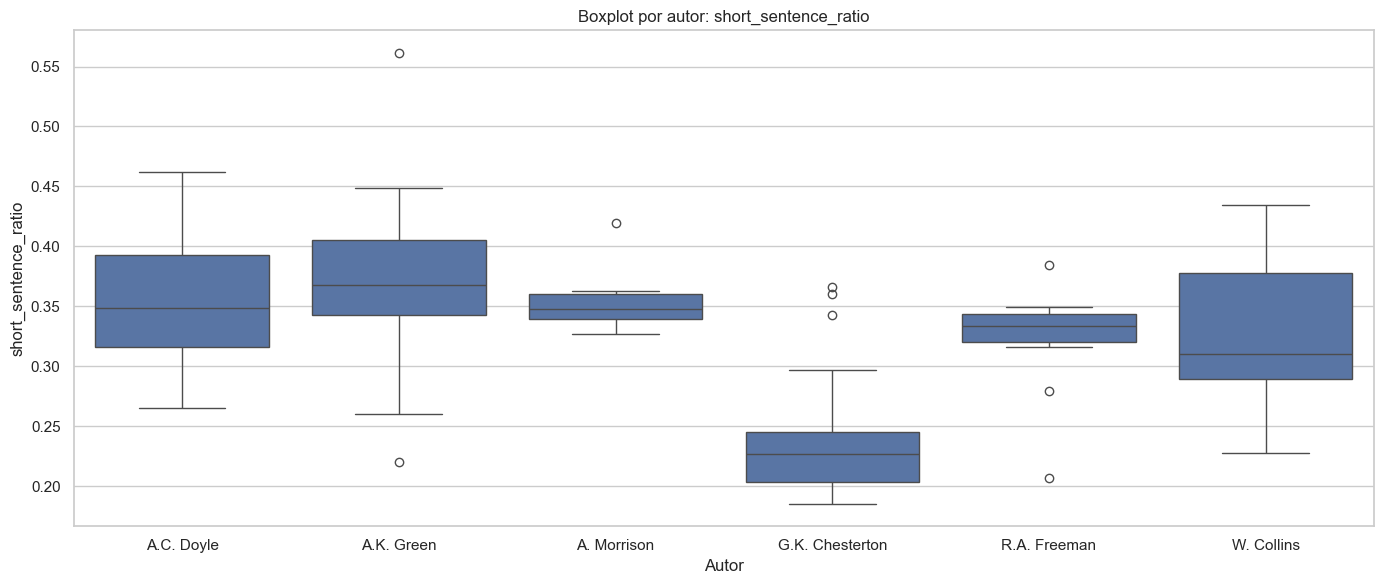

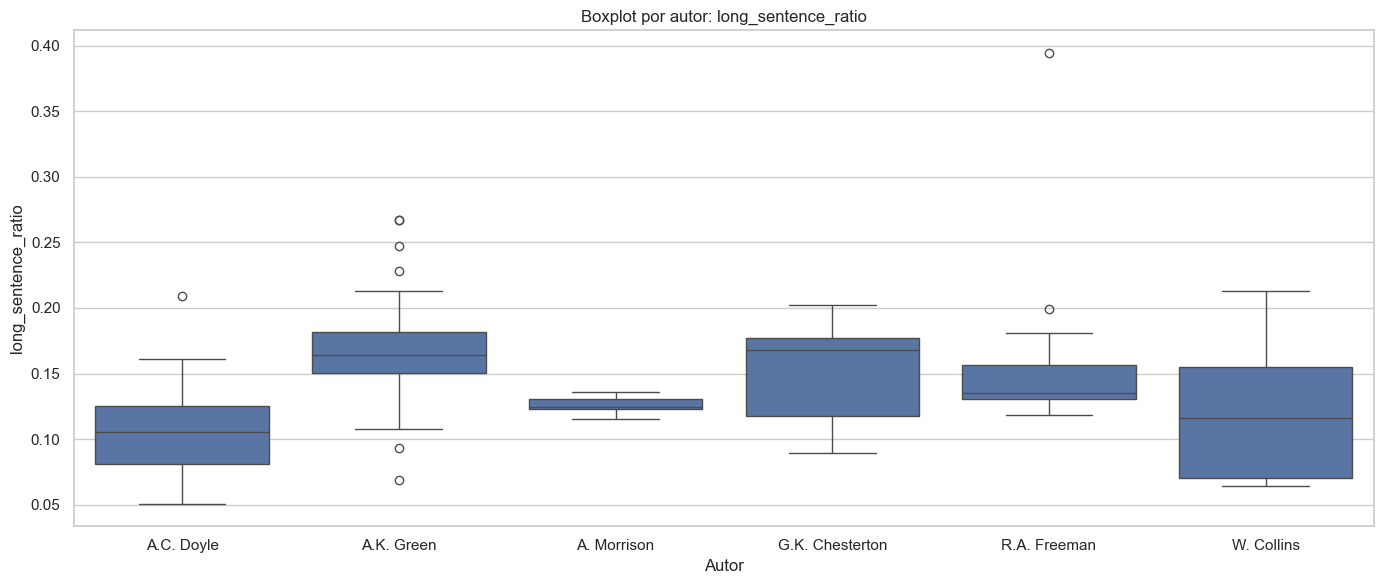

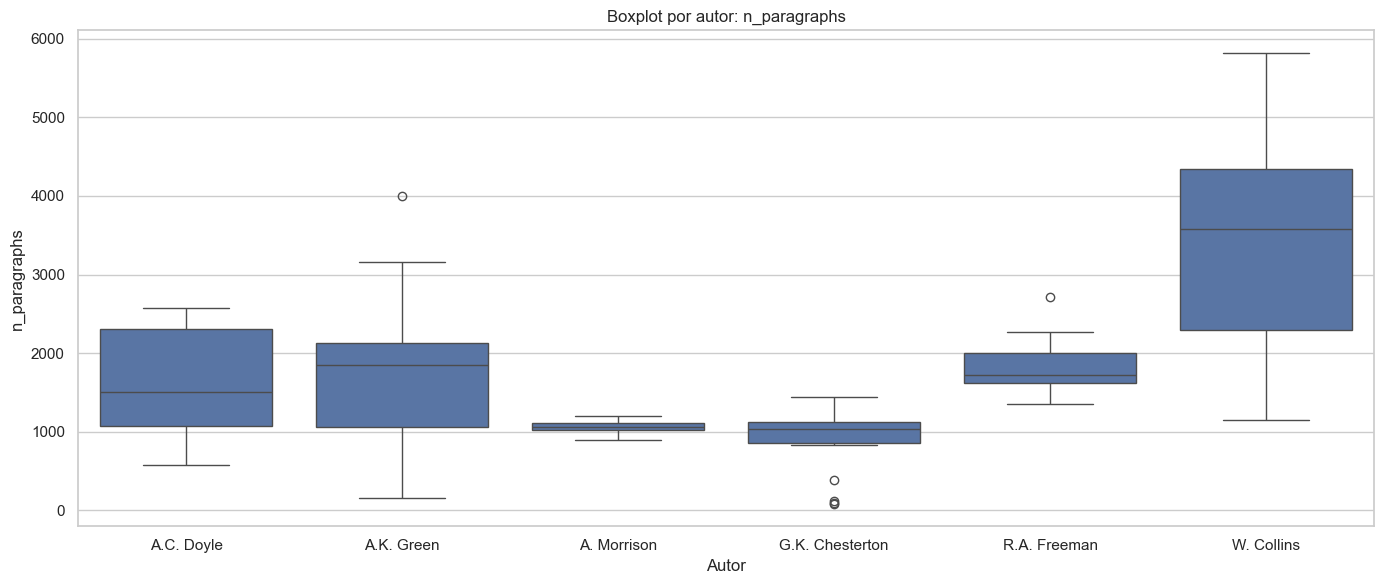

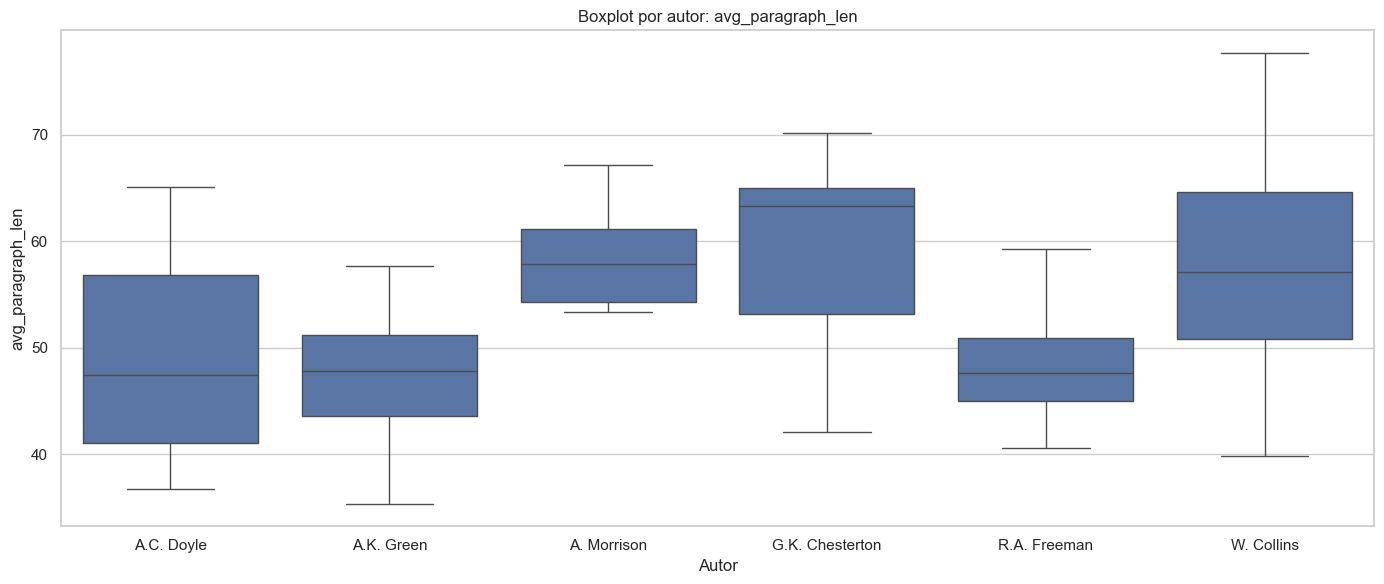

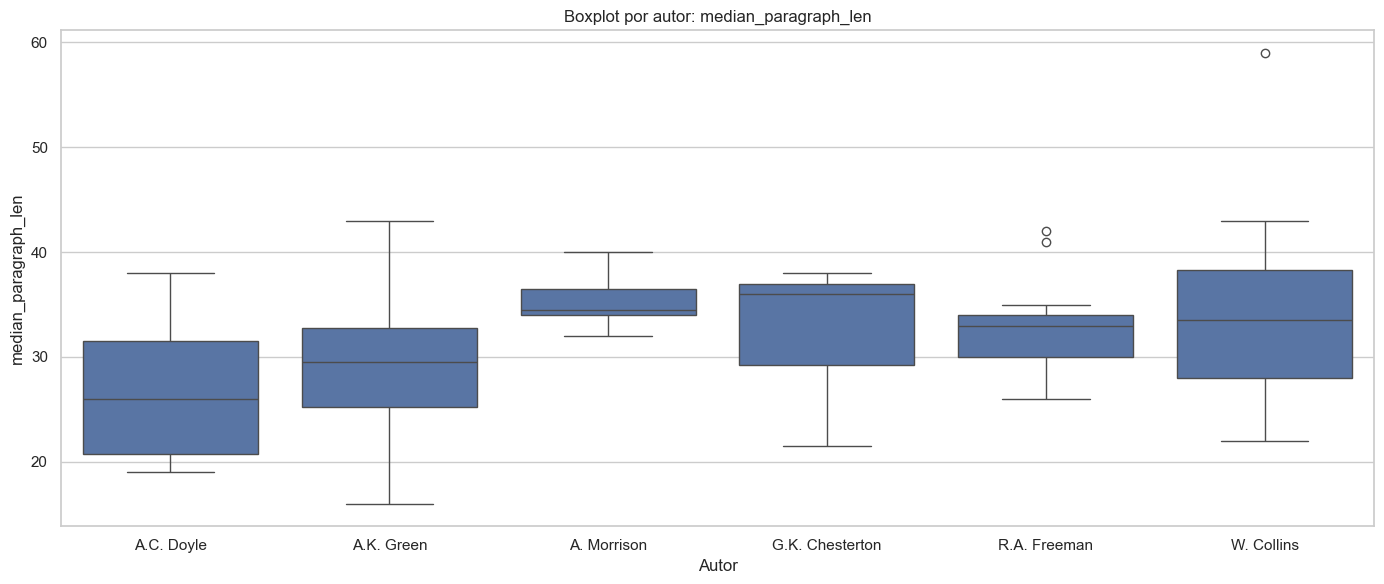

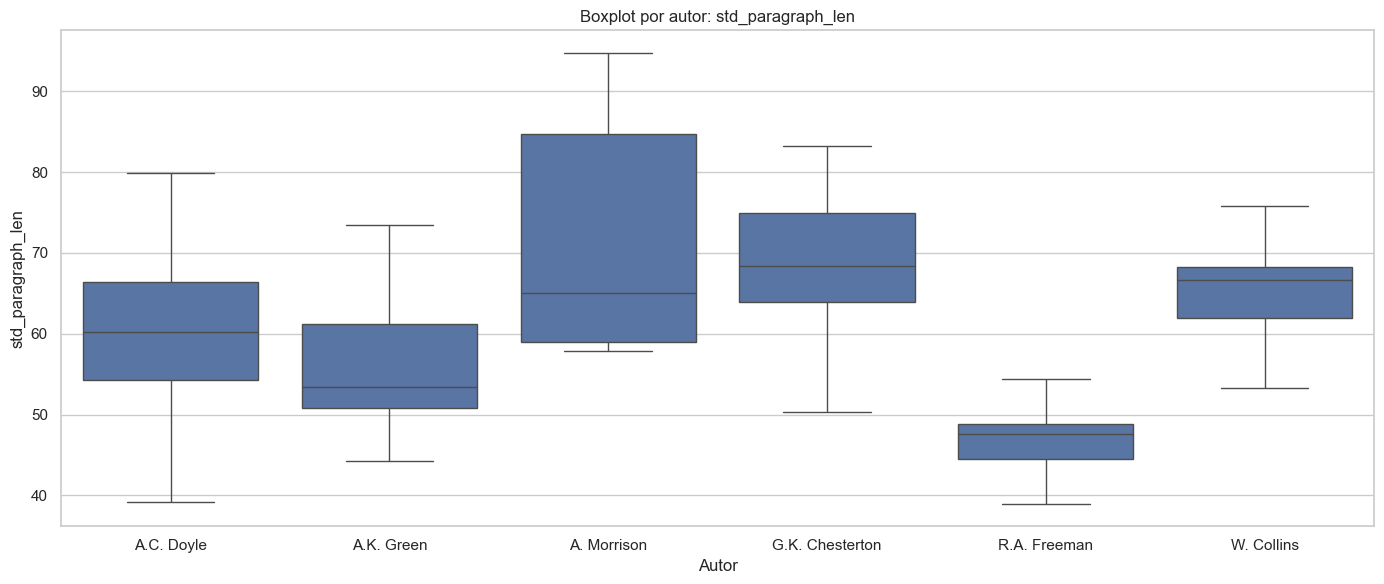

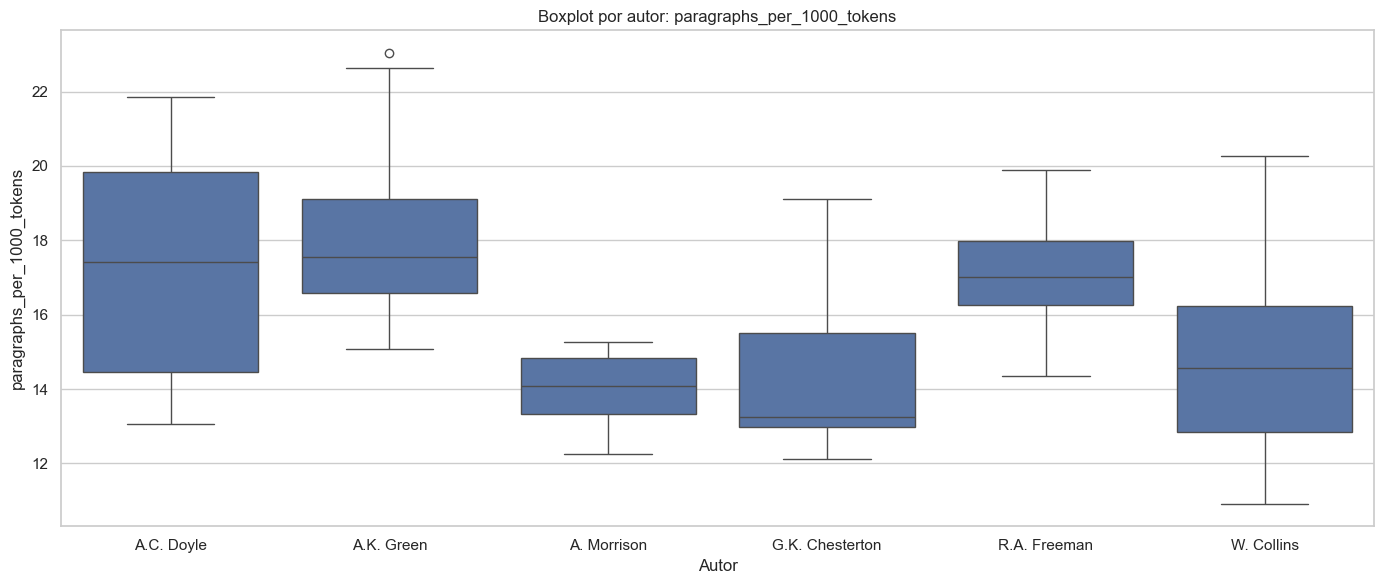

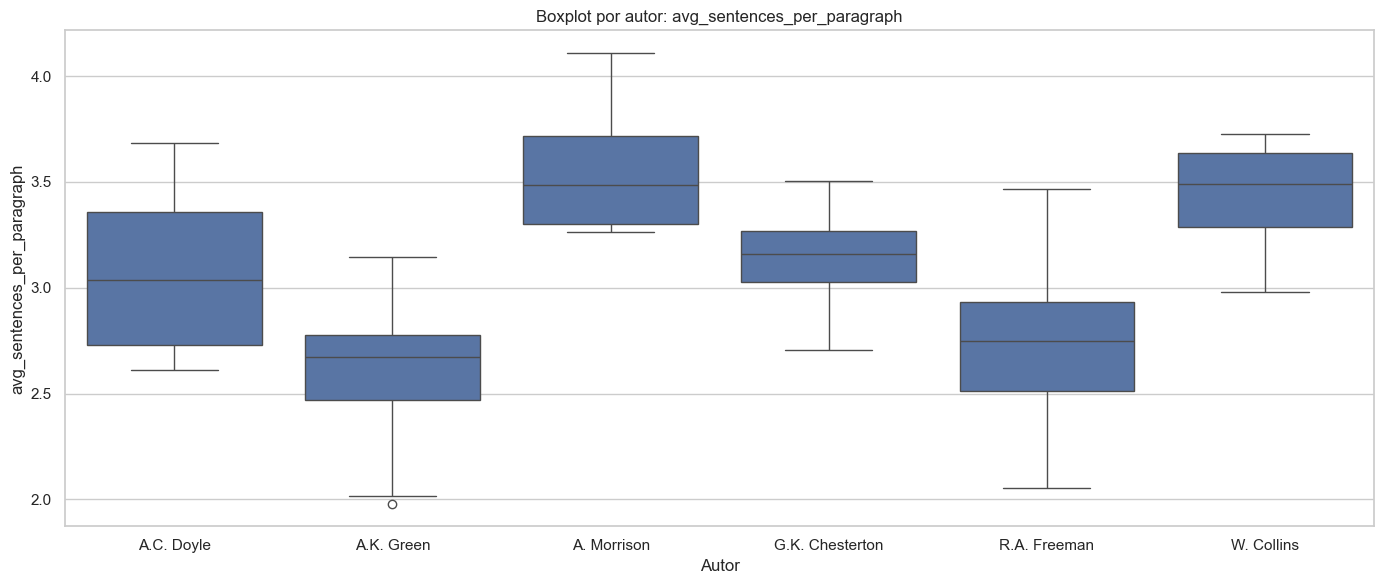

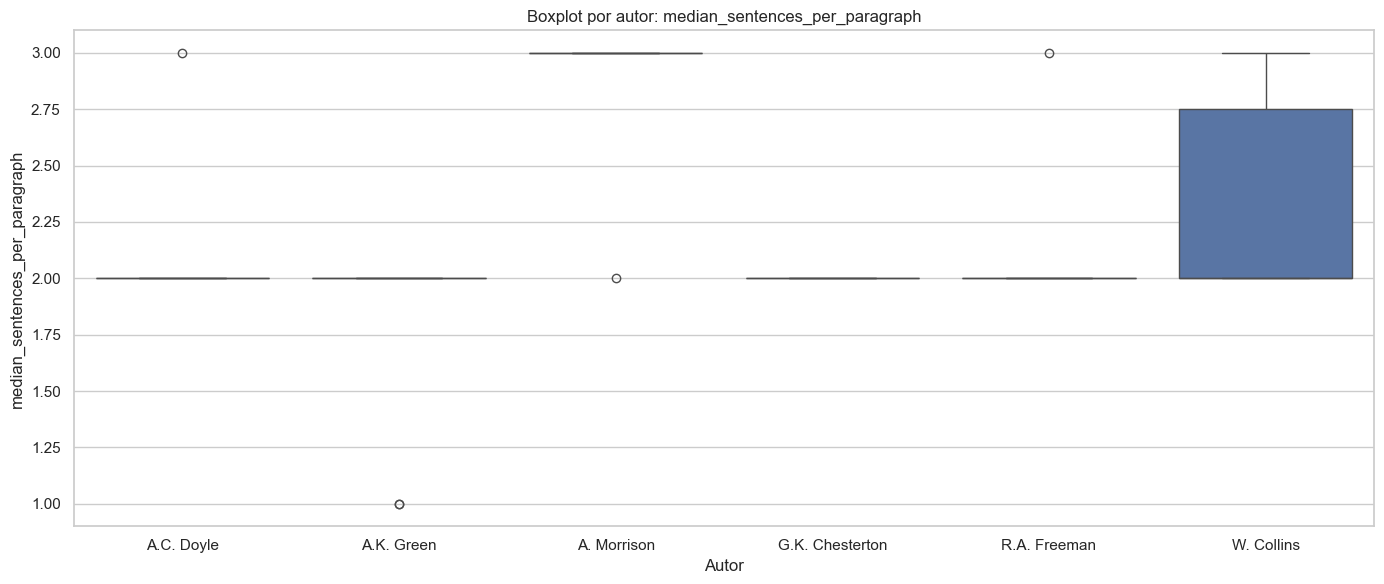

In [39]:
plot_metrics_boxplots_by_author(
    df_corpus, metric_cols, save_path=FIGS_DIR / "structural_metrics_boxplots_by_author.png"
)

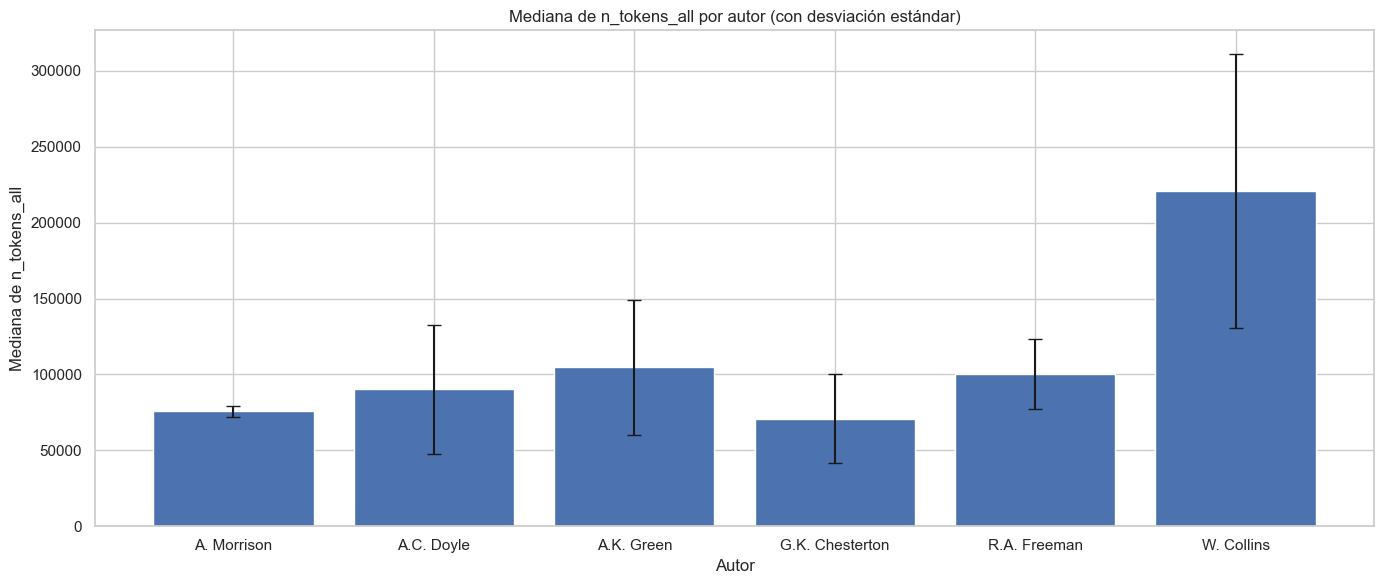

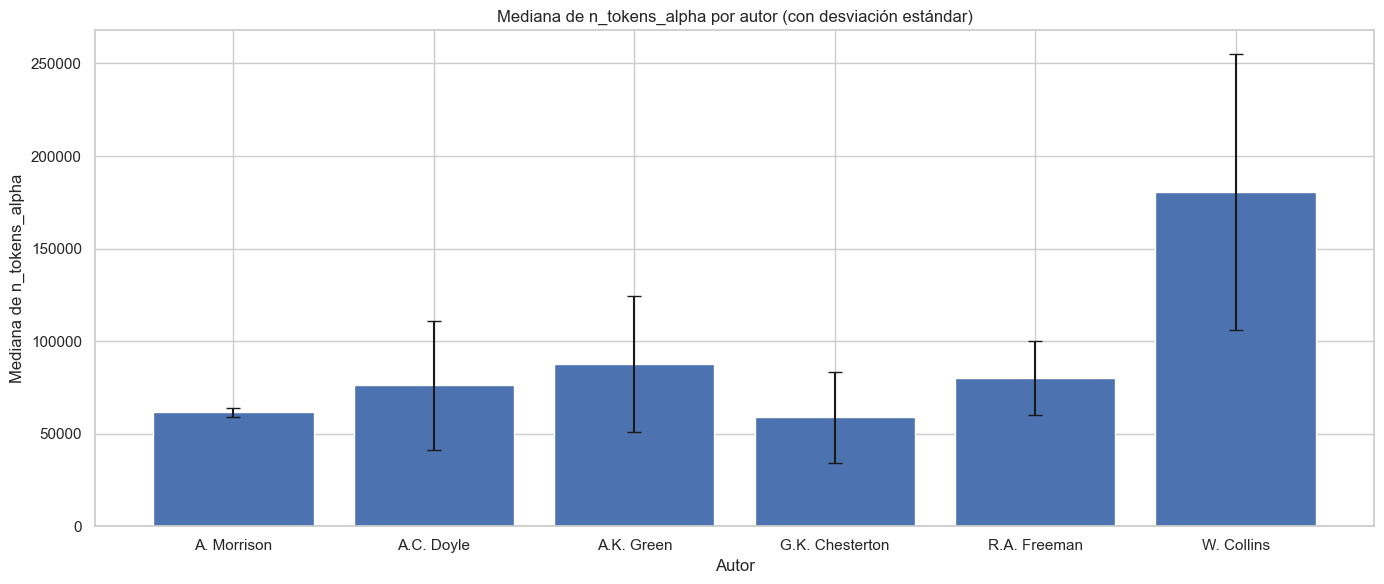

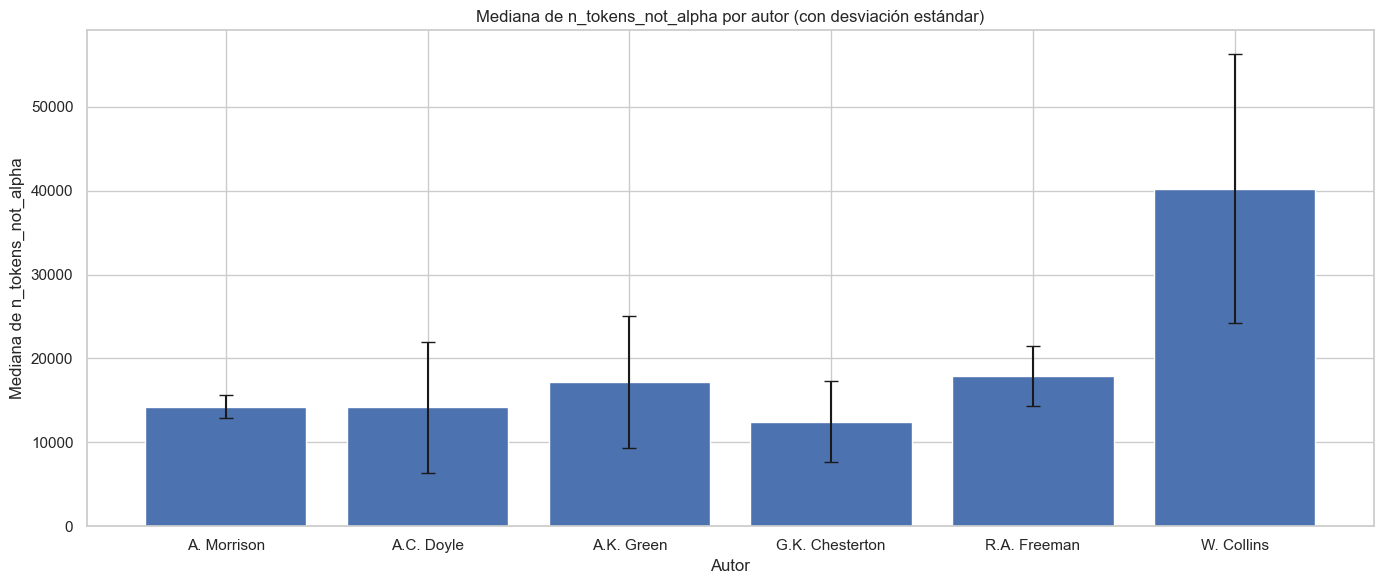

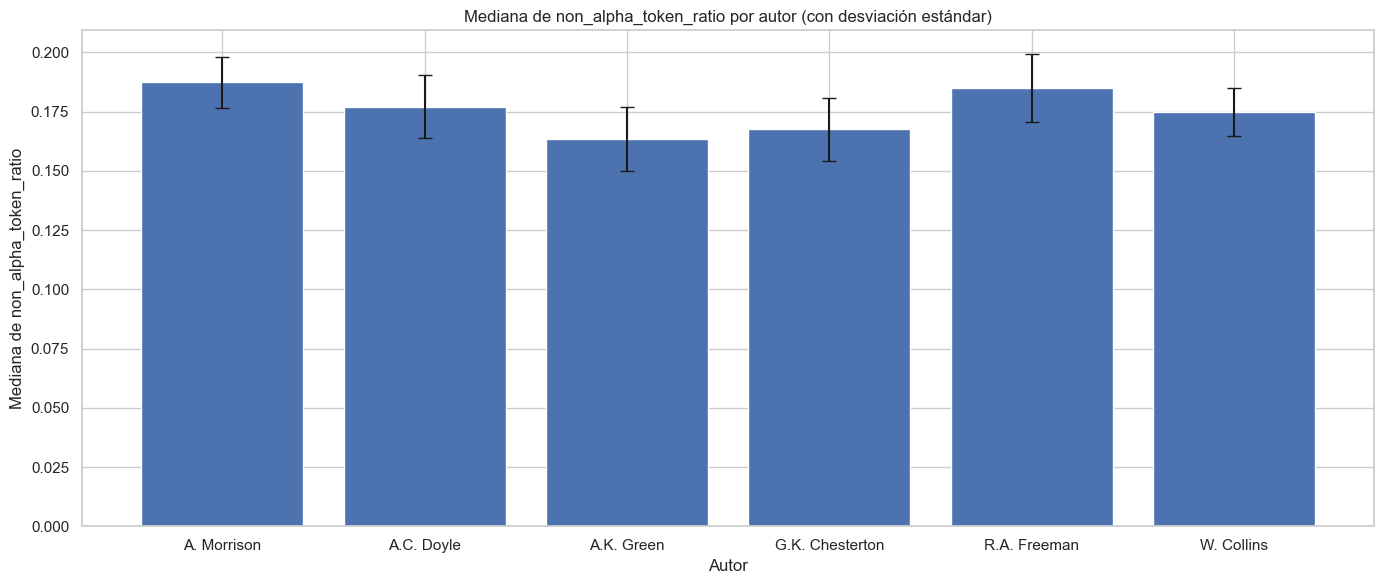

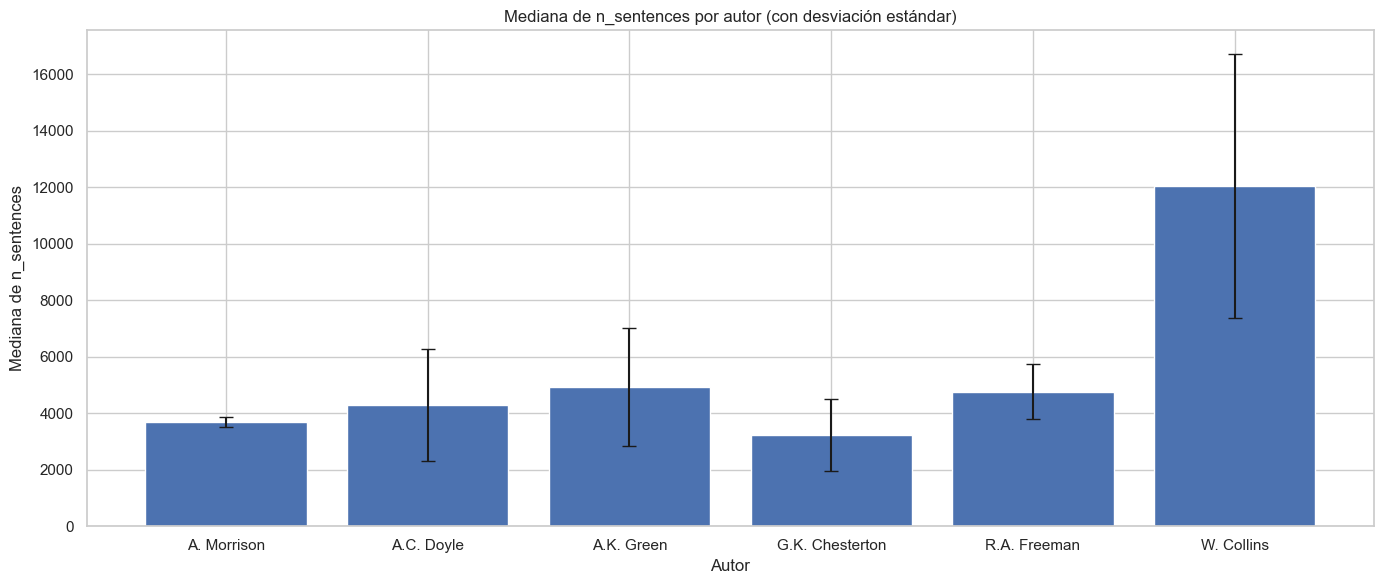

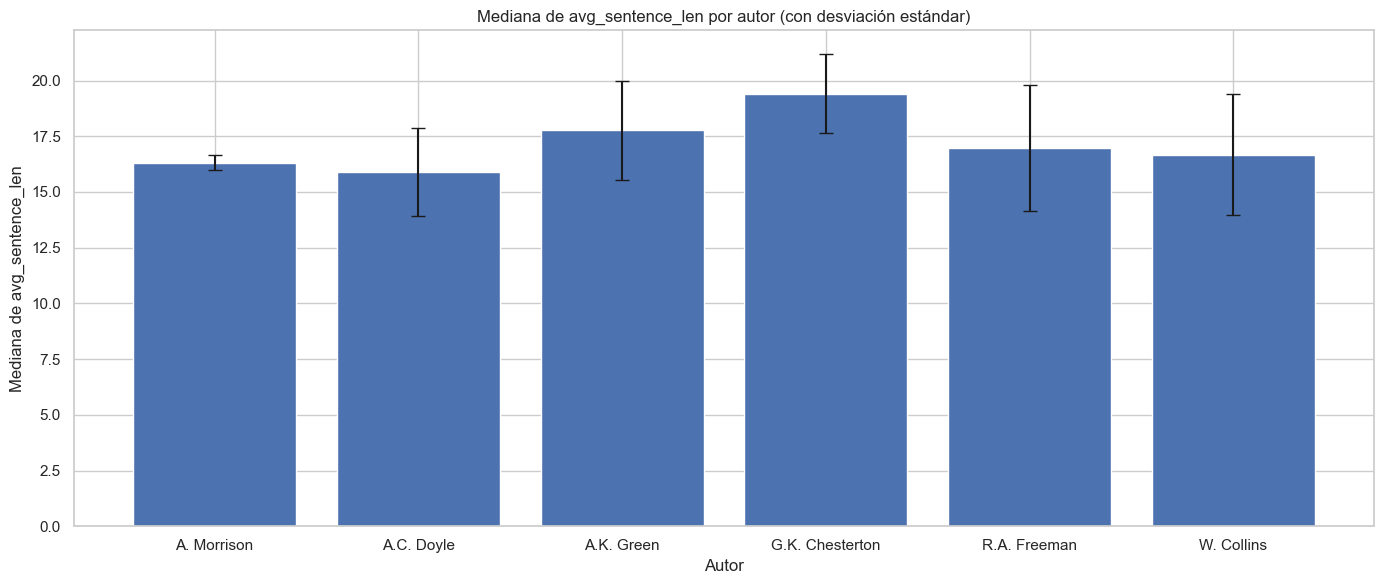

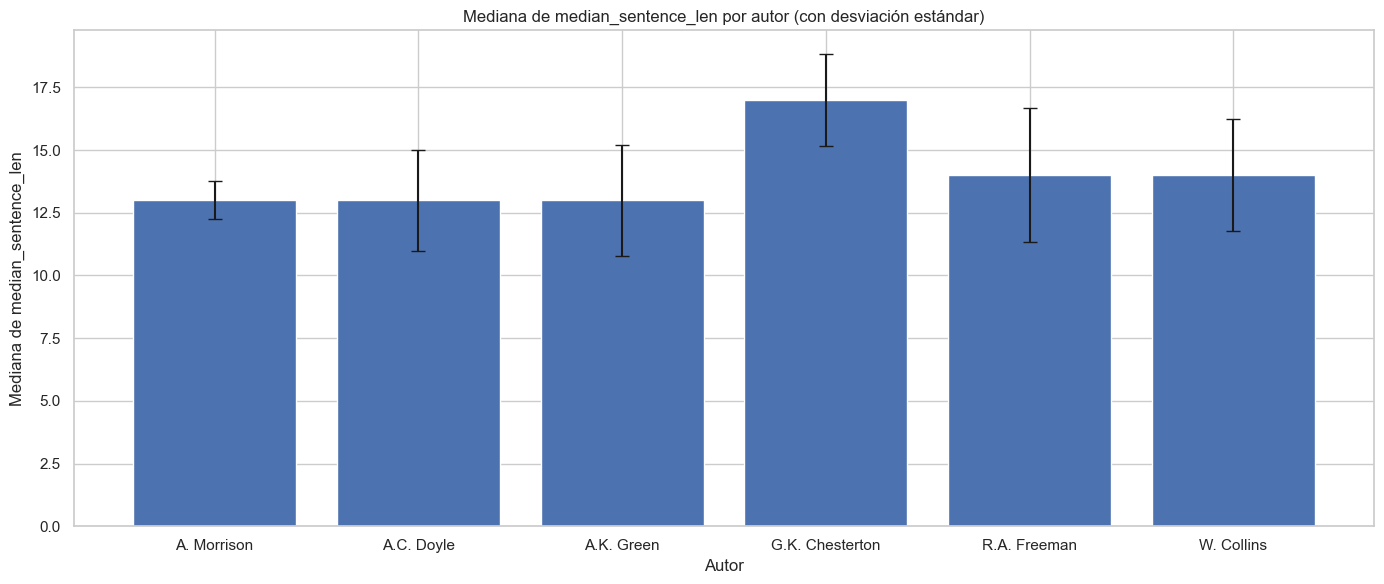

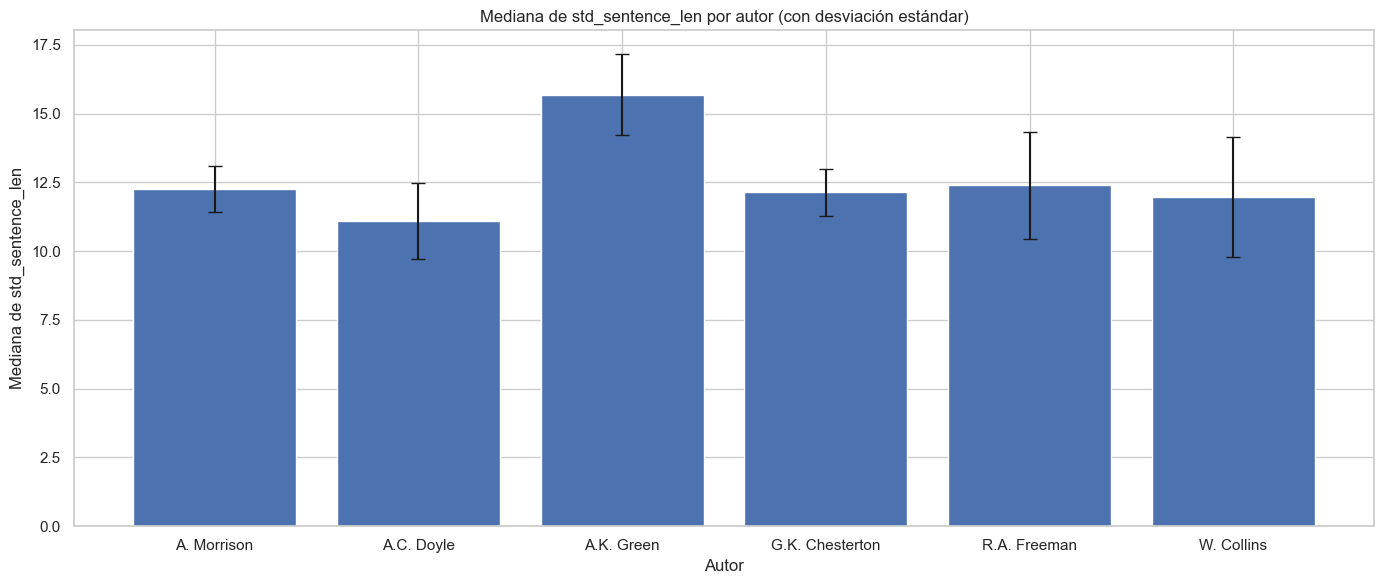

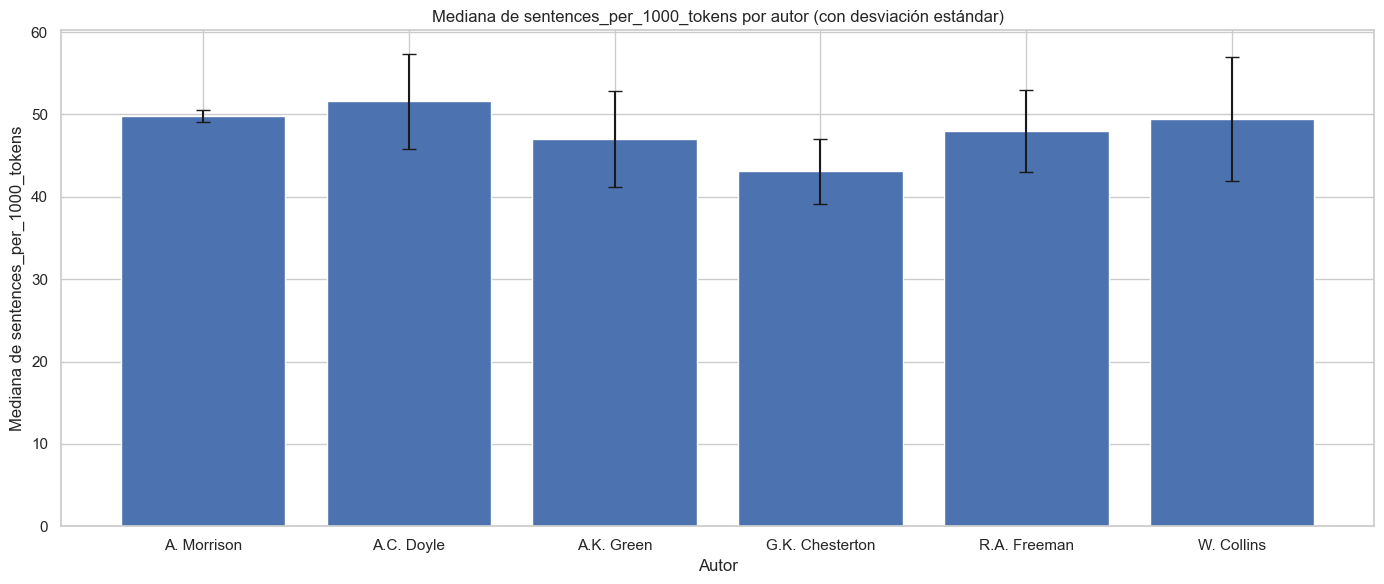

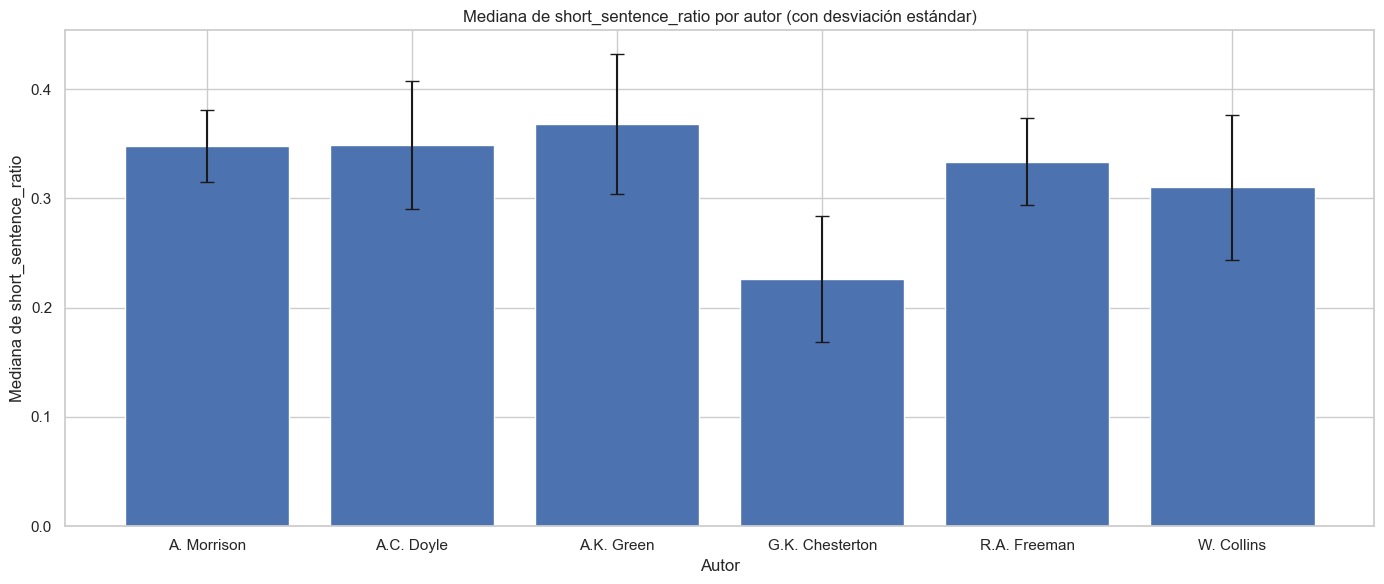

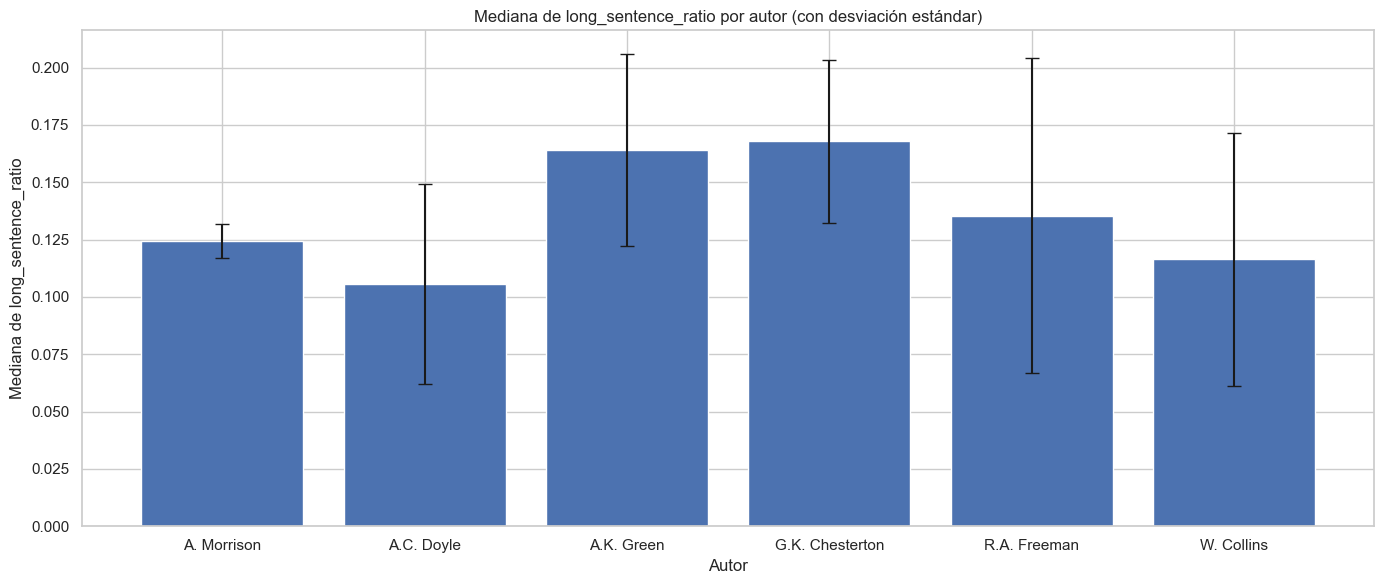

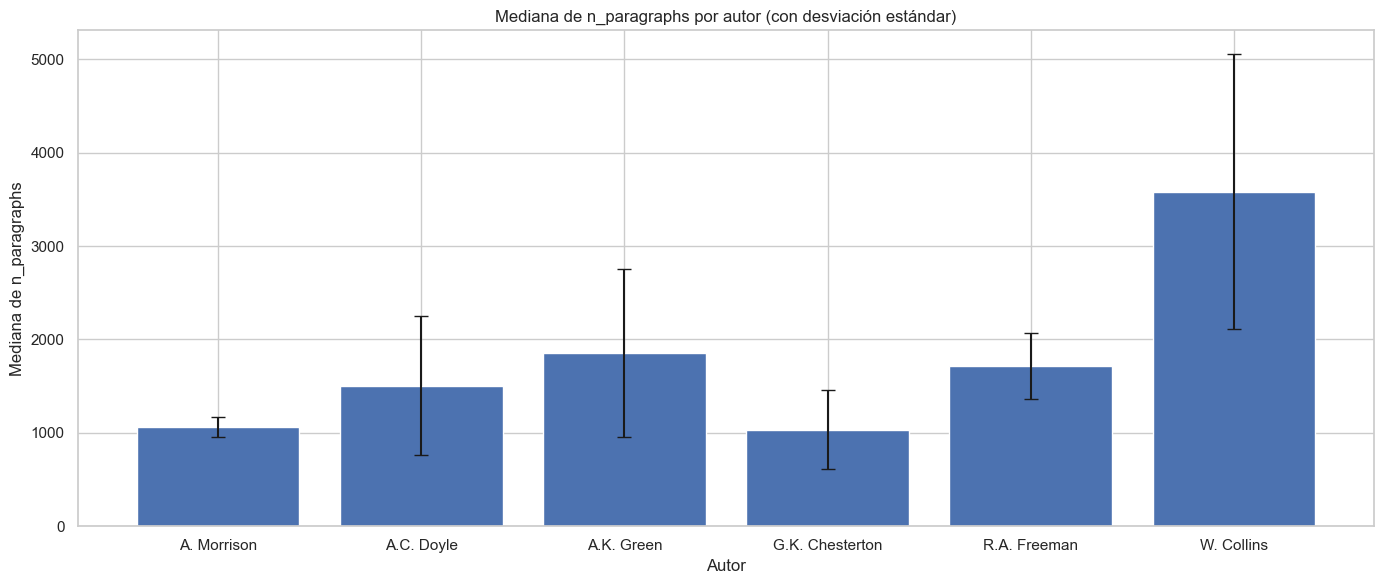

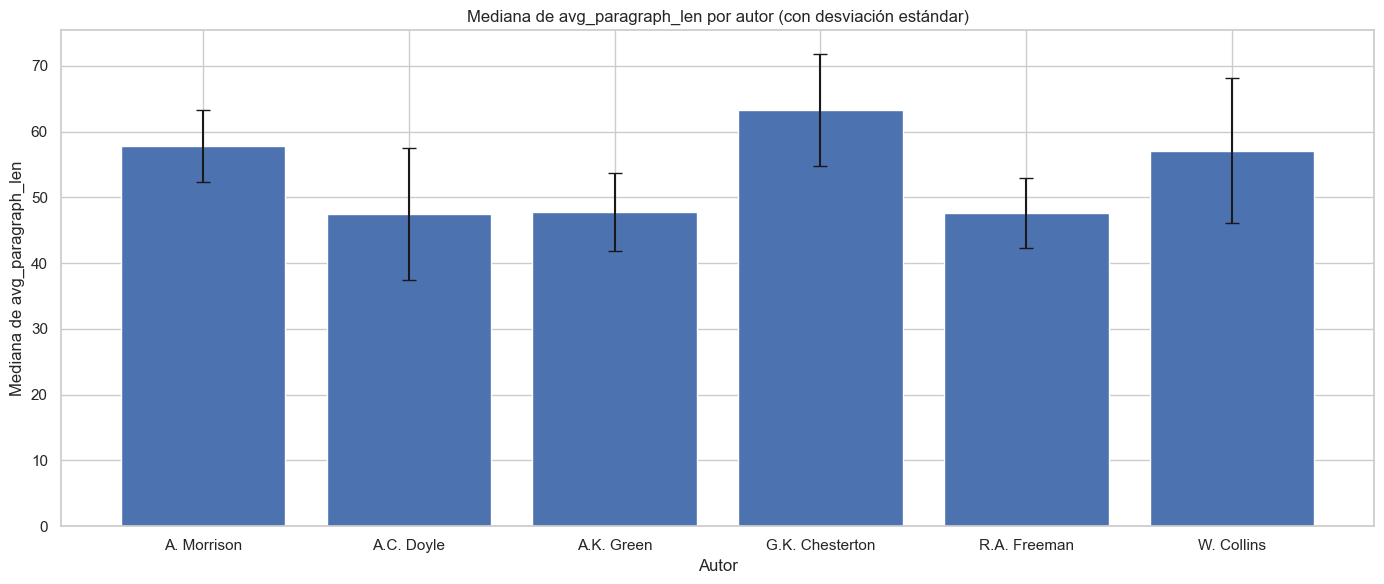

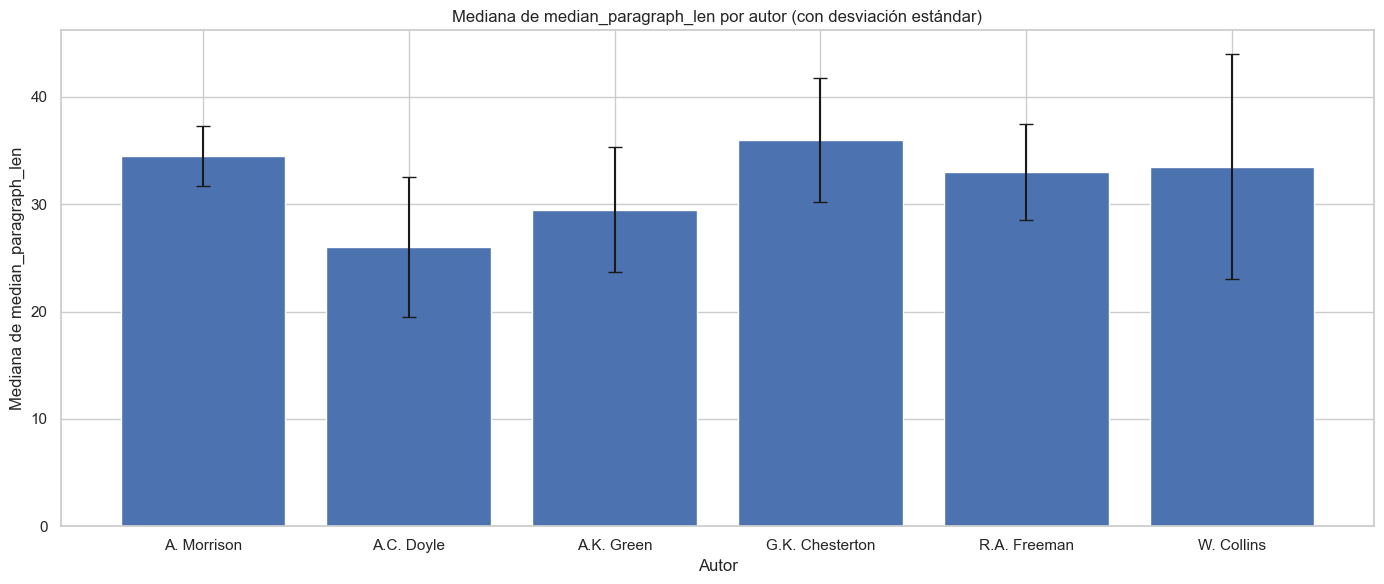

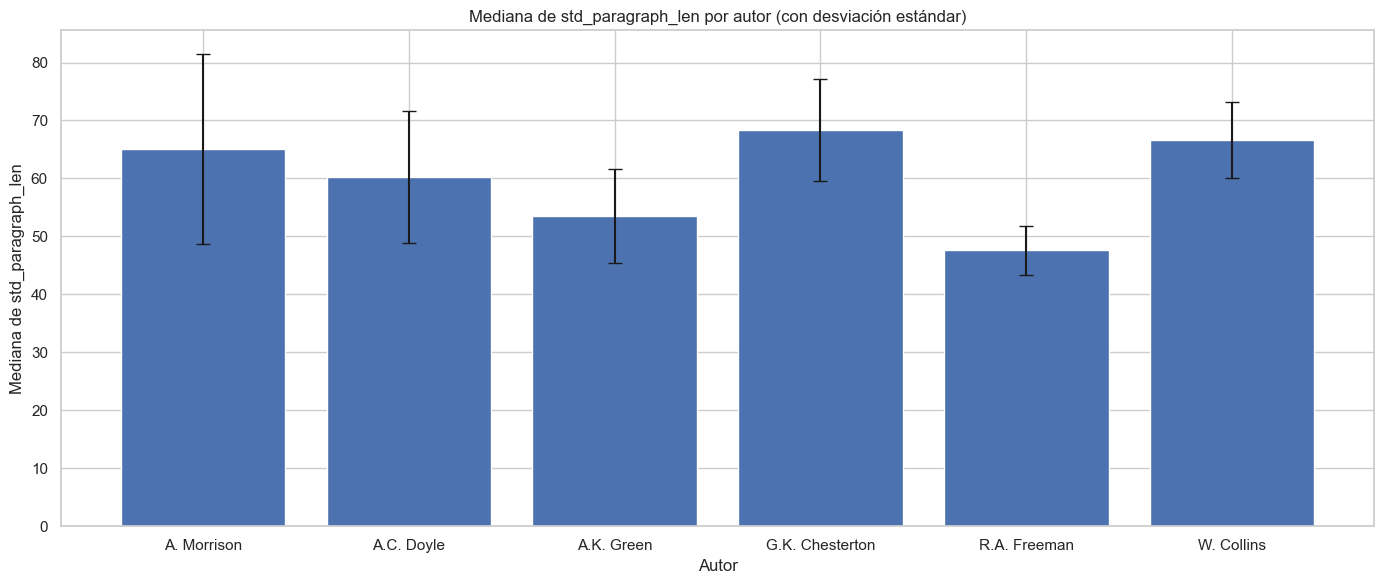

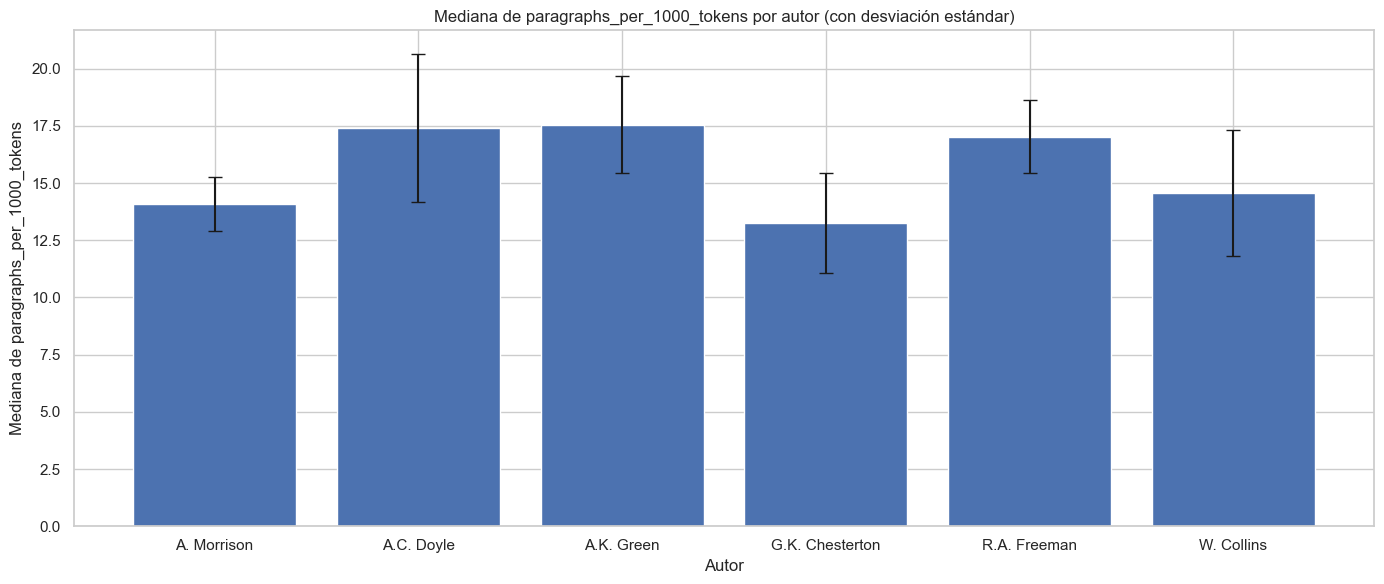

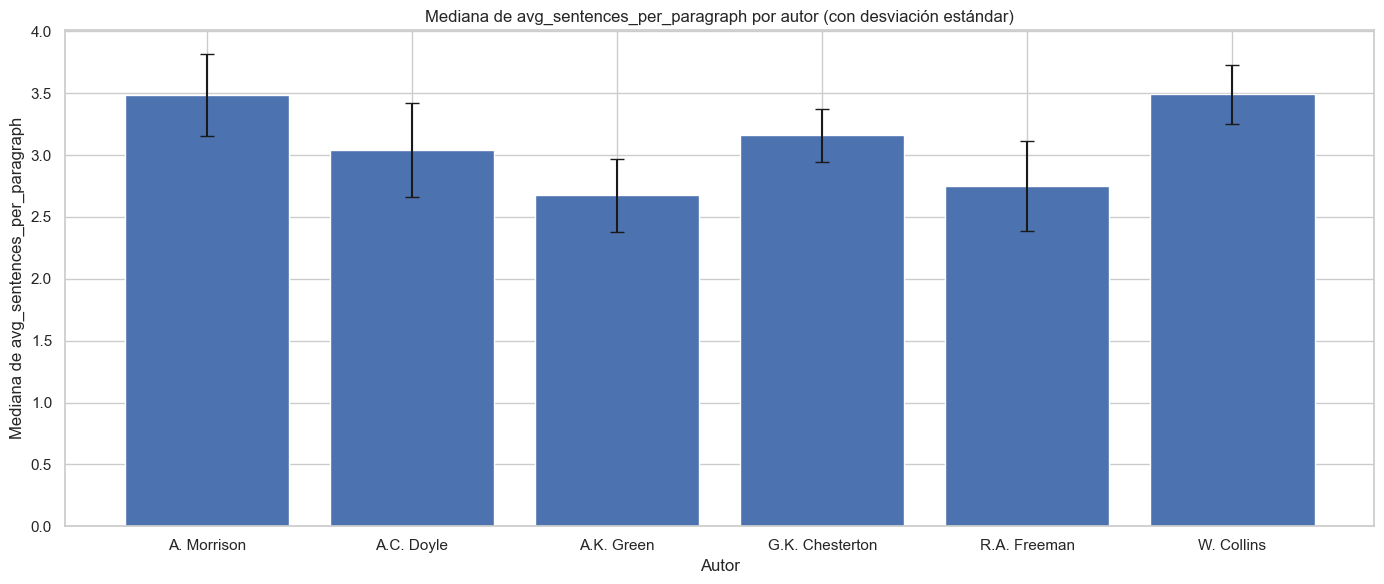

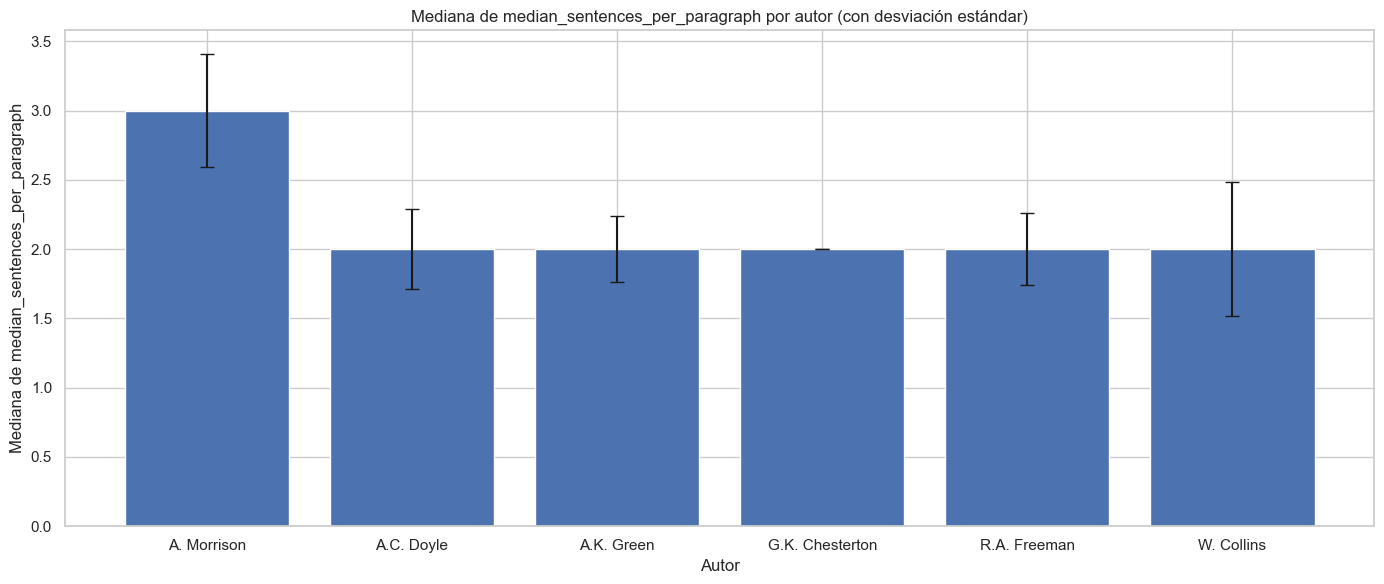

In [40]:
plot_bars_by_author_with_std(df_corpus, metric_cols, agg="median", save_path=FIGS_DIR / "bars_by_author_with_std.png")

Ahora vamos a analizar una serie de pares de métricas para ver cómo se correlacionan entre sí. Esto nos permitirá entender mejor las relaciones entre estas características estructurales y cómo se combinan para formar el estilo de cada obra.

* `("n_tokens_all", "n_sentences")`. Muestra cómo se relaciona la longitud total del texto con su segmentación en frases, y permite ver si los textos más largos crecen por acumular más frases.
* `("n_tokens_all", "n_paragraphs")`. Permite analizar si las obras más extensas también se estructuran en más párrafos o si, por el contrario, concentran más contenido en menos bloques.
* `("n_sentences", "n_paragraphs")`. Aporta información sobre el patrón de organización del texto, mostrando si un mayor número de frases suele traducirse en más párrafos.
* `("avg_sentence_len", "avg_paragraph_len")`. Permite observar si los textos con frases más largas tienden también a presentar párrafos más extensos, lo que puede reflejar un estilo más denso o desarrollado.
* `("avg_sentence_len", "median_sentence_len")`. Sirve para comprobar la estabilidad de la longitud de frase y detectar si la media está siendo arrastrada por frases excepcionalmente largas.
* `("avg_paragraph_len", "median_paragraph_len")`. Aporta la misma información anterior, pero a nivel de párrafo, permitiendo identificar asimetrías o valores extremos en la distribución.
* `("n_tokens_not_alpha", "n_tokens_all")`. Permite ver si la cantidad de tokens no alfabéticos crece simplemente con la longitud del texto o si algunos autores los usan proporcionalmente más.
* `("non_alpha_token_ratio", "avg_sentence_len")`. Ayuda a explorar si una mayor presencia relativa de signos, números o símbolos se asocia con frases más largas o con una puntuación más cargada.
* `("avg_sentences_per_paragraph", "avg_paragraph_len")`. Permite interpretar si los párrafos más largos lo son porque contienen más frases o porque esas frases son, además, más extensas.

In [41]:
scatter_pairs = [
    ("n_tokens_all", "n_sentences"),
    ("n_tokens_all", "n_paragraphs"),
    ("n_sentences", "n_paragraphs"),
    ("avg_sentence_len", "avg_paragraph_len"),
    ("avg_sentence_len", "median_sentence_len"),
    ("avg_paragraph_len", "median_paragraph_len"),
    ("n_tokens_not_alpha", "n_tokens_all"),
    ("non_alpha_token_ratio", "avg_sentence_len"),
    ("avg_sentences_per_paragraph", "avg_paragraph_len"),
]

In [42]:
plot_scatter_list_plotly(
    data=df_corpus,
    scatter_pairs=scatter_pairs,
    hue="author",
    work_col="title",
)

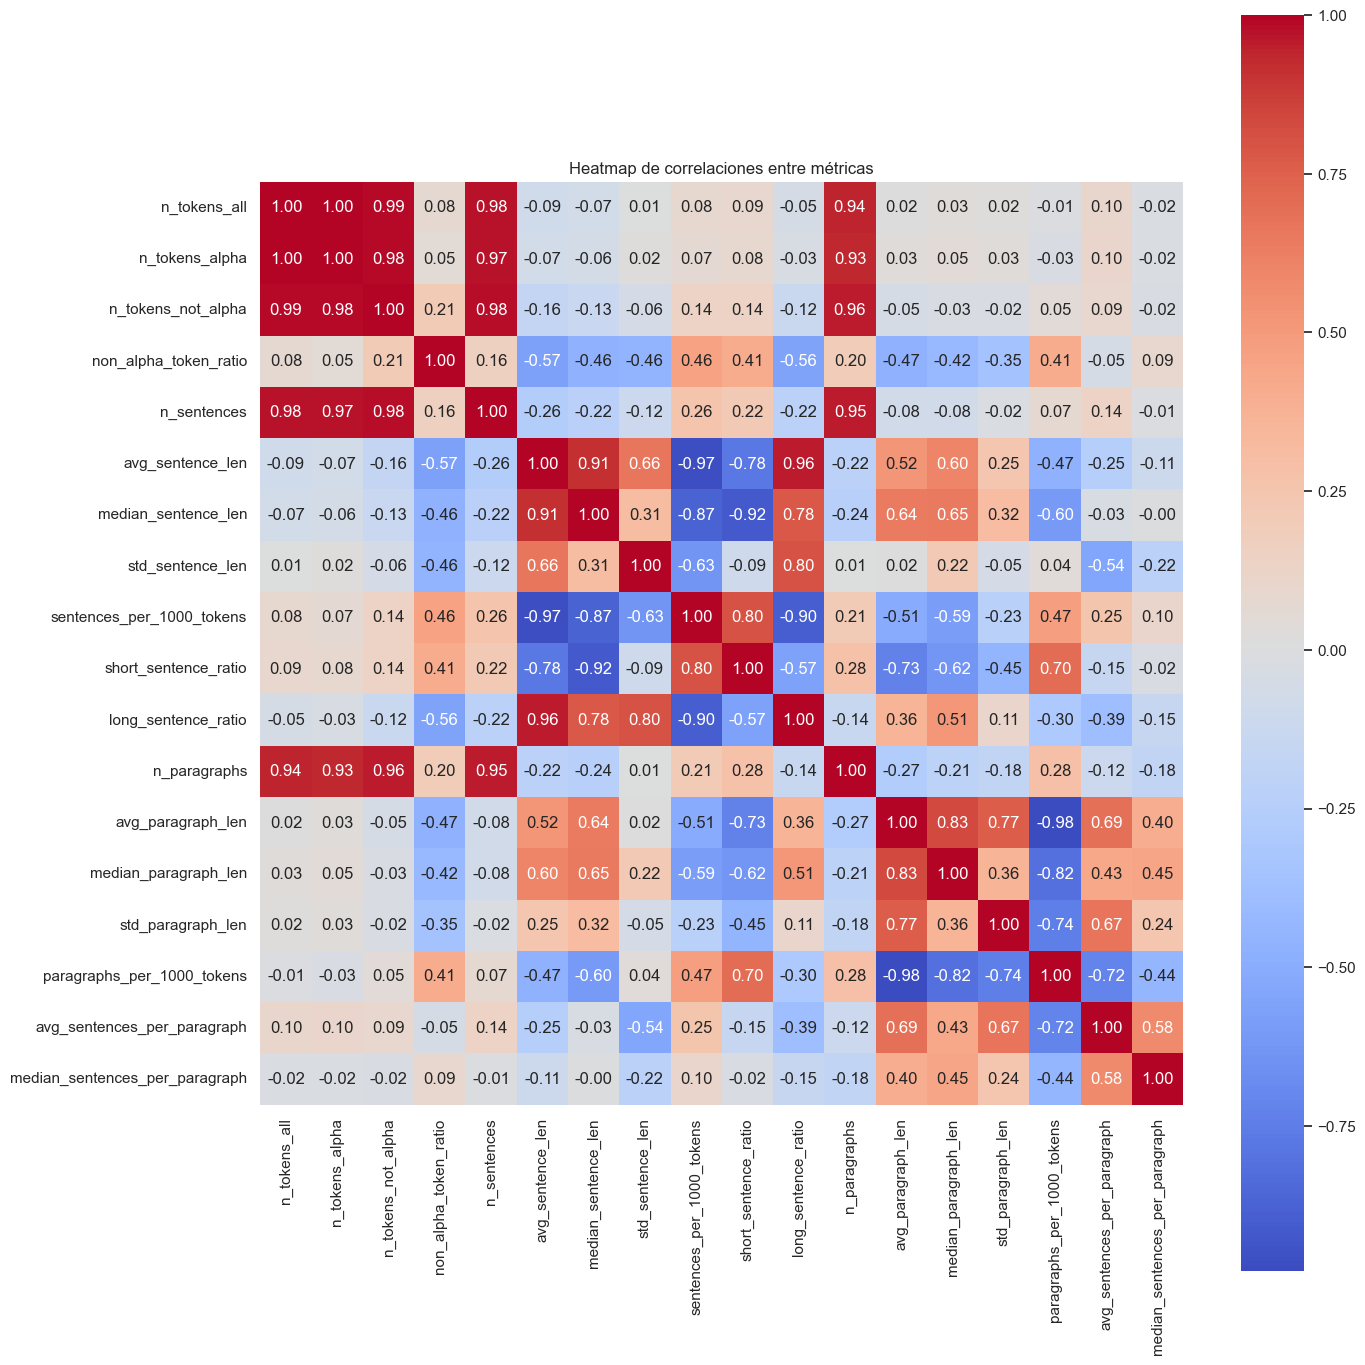

In [43]:
plot_metrics_correlations_heatmap(
    df_corpus, metric_cols, save_path=FIGS_DIR / "structural_metrics_correlations_heatmap.png"
)

### Métricas de la estructura léxica de los textos del corpus

Estas métricas describen la estructura léxica básica de cada texto, es decir, cómo de amplio, variado y repetitivo es el vocabulario empleado y permiten caracterizar aspectos centrales del estilo de un autor.

`n_types` es el número de palabras distintas presentes en el texto. Si un texto contiene muchos tipos diferentes, su vocabulario es más amplio, si contiene pocos, es más repetitivo o más restringido.

`ttr` (*type-token ratio*) es la proporción entre el número de tipos y el número total de tokens. Esta métrica da una estimación de la diversidad léxica, cuanto más alta mayor variedad de vocabulario. Sin embargo, hay que interpretarla con cautela porque depende mucho de la longitud del texto y en textos largos suele bajar aunque el estilo no cambie.

`hapax_count` cuenta cuántas palabras aparecen una sola vez en el texto, y `hapax_ratio` expresa esas palabras únicas como proporción del número total de tipos. Estas métricas son útiles porque capturan el grado de rareza léxica. Un texto con muchos *hapax legomena* puede reflejar un vocabulario más variado, más específico o menos repetitivo. Aunque en estilometría, esto puede aportar señales sobre la riqueza expresiva del autor, también puede verse afectado por la longitud del texto o por el tema tratado.

Por último, `avg_word_len` y `median_word_len` calculan la longitud media y mediana de las palabras alfabéticas del texto. Estas medidas ofrecen aproximaciones simples al nivel de complejidad léxica. Aunque por sí solas no definen el estilo, pueden ayudar a distinguir entre textos con vocabulario más breve frente a otros con palabras más largas, cultas o específicas. De forma similar, `long_word_ratio` nos informa de la proporción de palabras largas respecto al total de palabras alfabéticas y se considera una palabra larga aquella que tiene 8 o más caracteres alfabéticos.

Para nuestro análisis, estas métricas son importantes porque capturan distintas dimensiones del uso del léxico: tamaño del vocabulario, diversidad, repetición, frecuencia de formas raras y complejidad superficial de las palabras.

In [44]:
metric_cols = [
    "n_types",
    "ttr",
    "hapax_count",
    "hapax_ratio",
    "avg_word_len",
    "median_word_len",
    "long_word_ratio",
]

df_checked, outlier_summary_df = add_iqr_outlier_flags(df_corpus, metric_cols)

In [45]:
outlier_summary_df

,q1,q3,iqr,lower_bound,upper_bound,n_outliers,n_low_outliers,n_high_outliers
n_types,5674.500000,7641.500000,1967.000000,2724.000000,10592.000000,9.0,6.0,3.0
ttr,0.074173,0.105022,0.030849,0.027901,0.151295,9.0,0.0,9.0
hapax_count,2646.000000,3348.500000,702.500000,1592.250000,4402.250000,9.0,8.0,1.0
hapax_ratio,0.434043,0.484563,0.050520,0.358263,0.560344,7.0,2.0,5.0
avg_word_len,4.199061,4.294985,0.095925,4.055174,4.438872,0.0,0.0,0.0
median_word_len,4.000000,4.000000,0.000000,4.000000,4.000000,0.0,0.0,0.0
long_word_ratio,0.054833,0.065915,0.011082,0.038210,0.082538,3.0,1.0,2.0


In [46]:
df_checked[df_checked["has_any_outlier"]][["file_name", "n_chars", "type", "outlier_metrics"]]

,file_name,n_chars,type,outlier_metrics
7,acd-the_poison_belt.txt,163040,novel,[ttr (high)]
11,acd-the_white_company.txt,812443,novel,"[n_types (high), hapax_count (high), long_word..."
12,akg-7_to_12_a_detective_story.txt,80399,novel,"[n_types (low), ttr (high), hapax_count (low)]"
13,akg-a_difficult_problem.txt,42582,short stories,"[n_types (low), ttr (high), hapax_count (low),..."
30,akg-the_doctor_his_wife_and_the_clock.txt,90442,novel,"[ttr (high), hapax_count (low)]"
43,akg-three_thousand_dollars.txt,66075,novel,"[n_types (low), ttr (high), hapax_count (low),..."
45,akg-x_y_z_a_detective_story.txt,98871,novel,"[ttr (high), hapax_count (low)]"
55,gkc-the_donnington_affair.txt,27292,short stories,"[n_types (low), ttr (high), hapax_count (low),..."
60,gkc-the_mask_of_midas.txt,33024,short stories,"[n_types (low), ttr (high), hapax_count (low),..."
68,gkc-the_white_pillars_murder.txt,29190,short stories,"[n_types (low), ttr (high), hapax_count (low),..."


Como veremos más adelenate, estos *outliers* léxicos no están señalando tanto problemas de calidad, sino sobre todo:

* efectos de la longitud de los textos
* diferencias entre novela y relato

Así, los *outliers* léxicos muestran un patrón consistente con las diferencias de longitud de los textos más que con errores de preprocesado. Los textos más breves tienden a presentar `ttr` alto y, en algunos casos, `hapax_ratio` alto, al tiempo que muestran valores bajos de `n_types` y `hapax_count`, lo que refleja un vocabulario más pequeño pero más diverso en proporción. 

En cambio, las novelas más largas tienden a concentrar valores altos de `n_types` y valores bajos de `hapax_ratio`, un comportamiento esperable dado que los textos extensos acumulan más tipos pero también más repetición léxica.

#### MATTR (*Moving-Average Type-Token Ratio*)

Se trata de una medida de diversidad léxica más estable que el TTR clásico ya que en vez de medir la diversidad léxica sobre todo el texto de una vez, la función la calcula sobre muchas ventanas deslizantes de tamaño fijo y luego promedia los resultados.

En cada ventana calcula:

$$\frac{\text{número de tokens distintos}}{\text{tamaño de la ventana}}$$

Luego guarda ese valor para todas las ventanas y al final devuelve la media de todos esos cocientes.

Mide cuánta variedad léxica hay de forma local y la promedia a lo largo del texto. Si en cada tramo de 100 palabras aparecen muchas palabras distintas, la MATTR será alta. Si en esos tramos hay mucha repetición, será baja.

Esta métrica corrige uno de los grandes problemas del TTR clásico que se calcula como:

$$\text{TTR} = \frac{\text{número de tipos}}{\text{número de tokens}}$$

El problema es que esta métrica depende mucho de la longitud del texto:

* en textos cortos suele salir artificialmente alta
* en textos largos suele salir artificialmente baja

Eso dificulta comparar novelas y relatos de distinta extensión.

La MATTR reduce ese sesgo porque siempre calcula la diversidad sobre ventanas del mismo tamaño. Así:

* hace las comparaciones más justas entre textos largos y cortos
* ofrece una medida más robusta de la riqueza léxica
* permite distinguir mejor entre diferencias de estilo reales y el efecto de longitud

En nuestro corpus, donde hay obras de distinta extensión, MATTR es especialmente útil porque ayuda a medir la diversidad léxica de manera más estable que:

* `ttr`
* `n_types`
* `hapax_count`
* `hapax_ratio`

Mientras que esas métricas están muy influenciadas por el tamaño del texto, MATTR suele reflejar mejor la variedad léxica efectiva del autor o de la obra.

A la hora de interpretar los valores:

* Una MATTR alta indica una mayor diversidad léxica, es decir, menos repetición dentro de cada ventana.
* Una MATTR baja refleja un vocabulario más repetitivo o más restringido.

En cuanto a que se considera “alto” o “bajo” no hay un umbral universal, lo importante es comparar entre textos del mismo corpus.

In [47]:
metric_cols = [
    "mattr_100",
]

df_checked, outlier_summary_df = add_iqr_outlier_flags(df_corpus, metric_cols)

In [48]:
outlier_summary_df

,q1,q3,iqr,lower_bound,upper_bound,n_outliers,n_low_outliers,n_high_outliers
mattr_100,0.730418,0.745266,0.014849,0.708145,0.767539,0.0,0.0,0.0


In [49]:
df_checked[df_checked["has_any_outlier"]][["file_name", "n_chars", "type", "outlier_metrics"]]

,file_name,n_chars,type,outlier_metrics


La ausencia de outliers en MATTR sugiere que los outliers léxicos detectados anteriormente estaban motivados sobre todo por el efecto de la longitud de los textos y no por una diversidad léxica realmente anómala. Dado que MATTR calcula la diversidad léxica sobre ventanas deslizantes de tamaño fijo, es mucho menos sensible a la longitud global del texto que métricas como TTR, el número de tipos o la proporción de hapax. En este sentido, los resultados indican que la diversidad léxica del corpus es relativamente homogénea una vez controlado el efecto del tamaño.

Esto no significa que todos los textos sean iguales estilísticamente. Solo significa que, en términos de diversidad léxica medida robustamente, ninguno destaca de forma extrema.

#### Stopword ratio

Este cálculo es importante porque mide la proporción de palabras funcionales (*stopwords*) dentro de cada texto.

Las *stopwords* incluyen palabras muy frecuentes y gramaticales como artículos, preposiciones, pronombres o conjunciones, por ejemplo: *the, and, of, to, in, is*. Aunque suelen aportar poco contenido temático, sí reflejan bastante bien los hábitos de escritura. Precisamente por eso, en estilometría suelen ser útiles: tienden a depender menos del tema del texto y más de patrones relativamente estables del autor.

La métrica `stopword_ratio` calcula qué proporción de los tokens alfabéticos del texto pertenece al conjunto de *stopwords*. Si el valor es alto, significa que el texto contiene una mayor densidad de palabras funcionales, si es bajo, el texto está relativamente más cargado de palabras léxicas o de contenido.

Esta métrica es relevante por varias razones. Primero, ayuda a capturar una dimensión del estilo que no depende tanto del vocabulario del tema del que trata la obra como otras métricas léxicas. Segundo, puede revelar diferencias en la densidad gramatical o en el equilibrio entre palabras funcionales y palabras de contenido. Tercero, puede servir como indicador complementario para comparar obras y autores, especialmente cuando se interpreta junto con otras medidas como MATTR, la longitud media de palabra o métricas de puntuación.

In [50]:
metric_cols = [
    "stopword_ratio",
]

df_checked, outlier_summary_df = add_iqr_outlier_flags(df_corpus, metric_cols)
outlier_summary_df

,q1,q3,iqr,lower_bound,upper_bound,n_outliers,n_low_outliers,n_high_outliers
stopword_ratio,0.596216,0.618652,0.022435,0.562564,0.652304,0.0,0.0,0.0


In [51]:
df_checked[df_checked["has_any_outlier"]][["file_name", "n_chars", "type", "outlier_metrics"]]

,file_name,n_chars,type,outlier_metrics


#### Visualización de las métricas léxicas

In [52]:
metric_cols = [
    "n_types",
    "ttr",
    "hapax_count",
    "hapax_ratio",
    "avg_word_len",
    "median_word_len",
    "long_word_ratio",
    "mattr_100",
    "stopword_ratio",
]

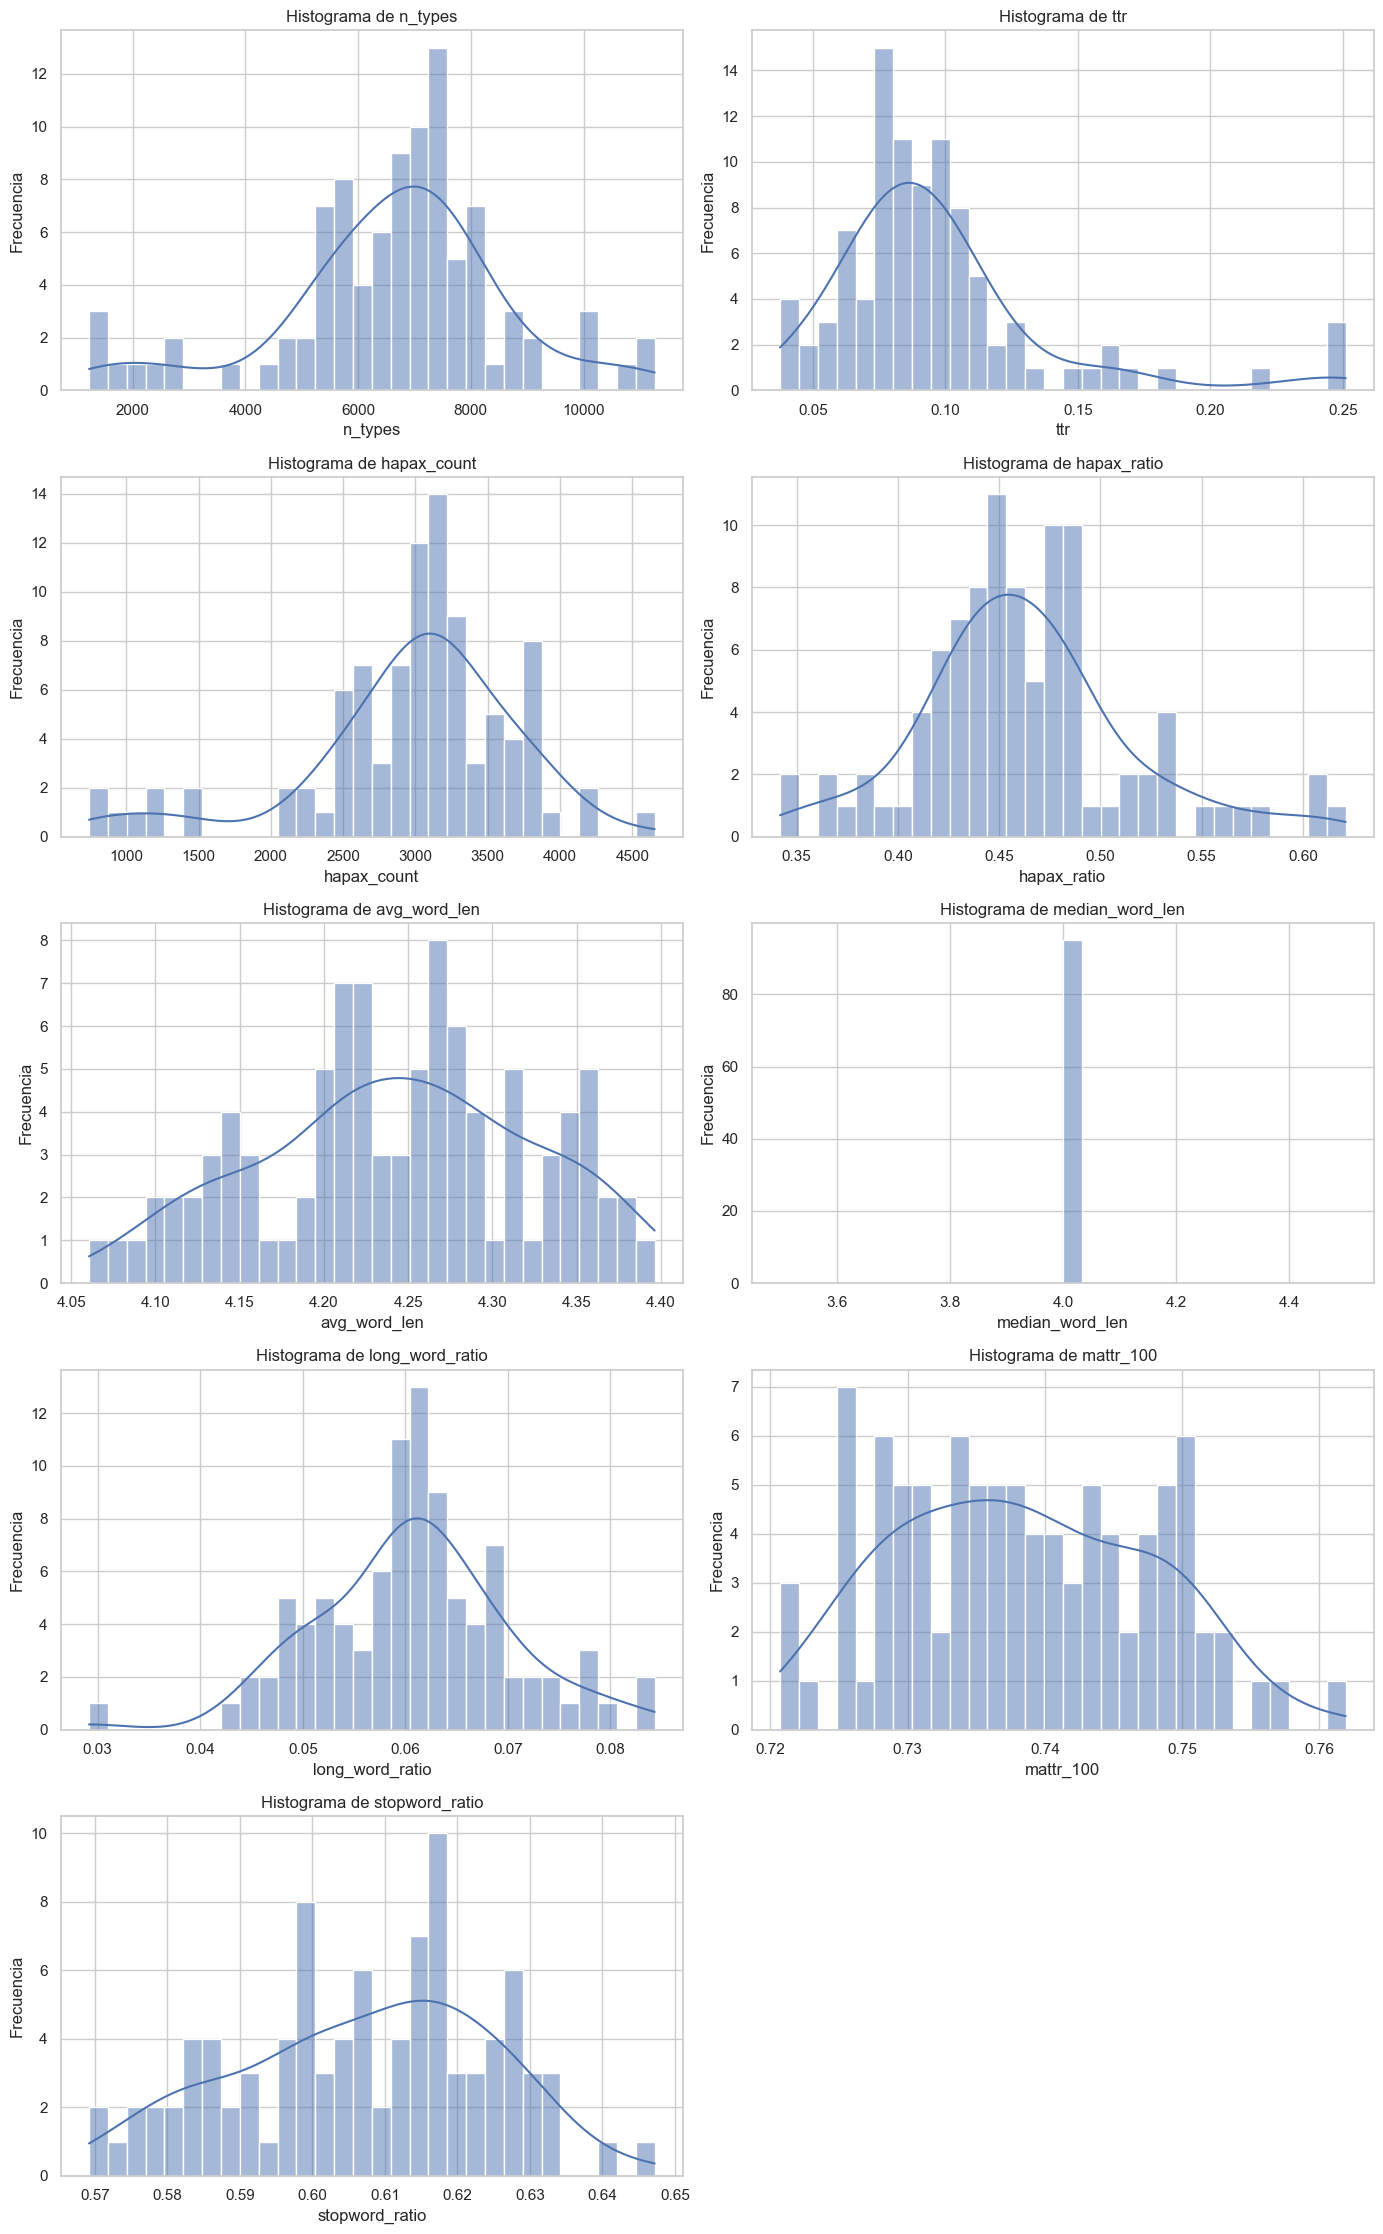

In [53]:
plot_metrics_histograms(df_corpus, metric_cols, save_path=FIGS_DIR / "lexical_metrics_histograms.png")

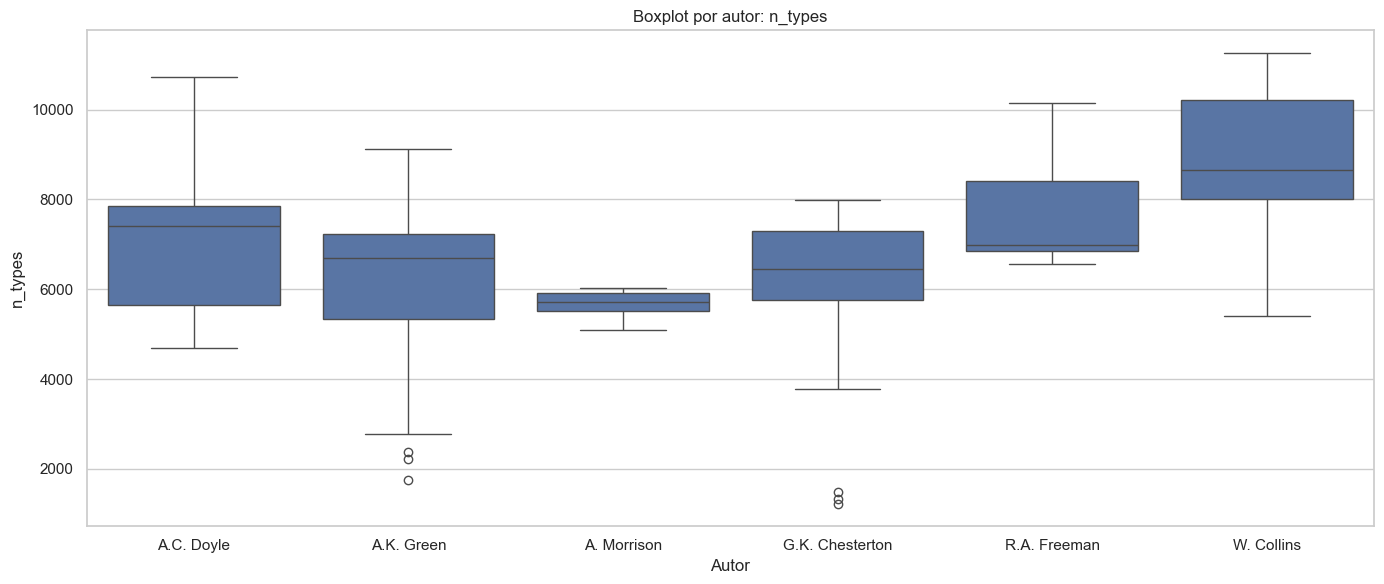

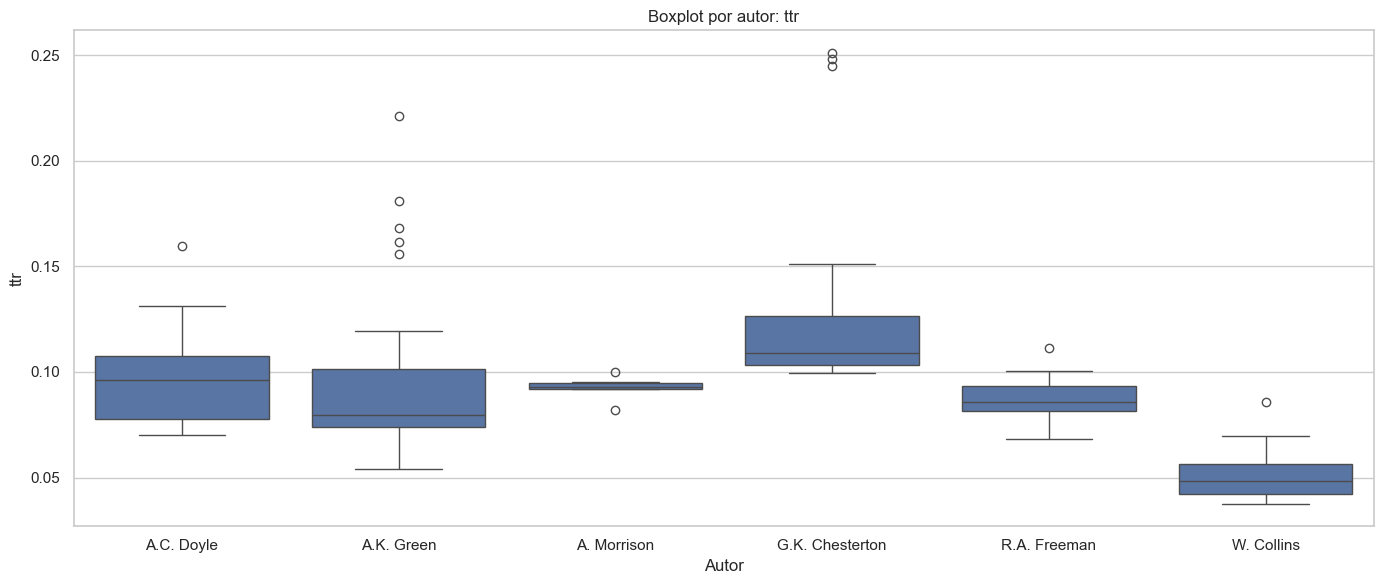

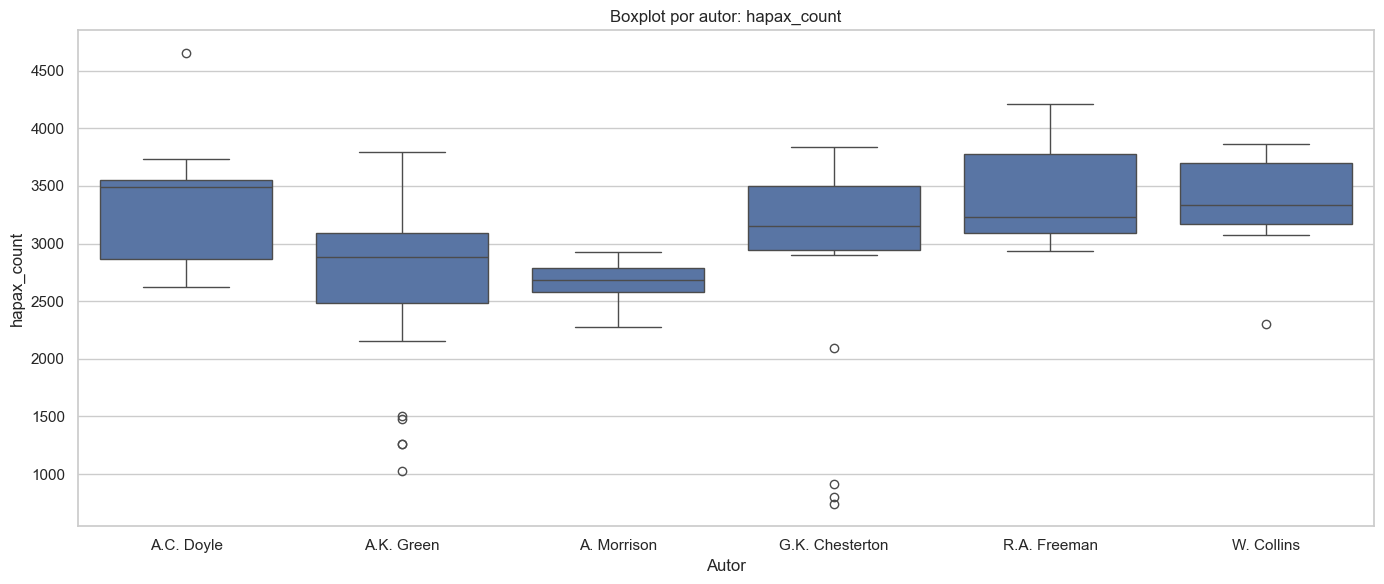

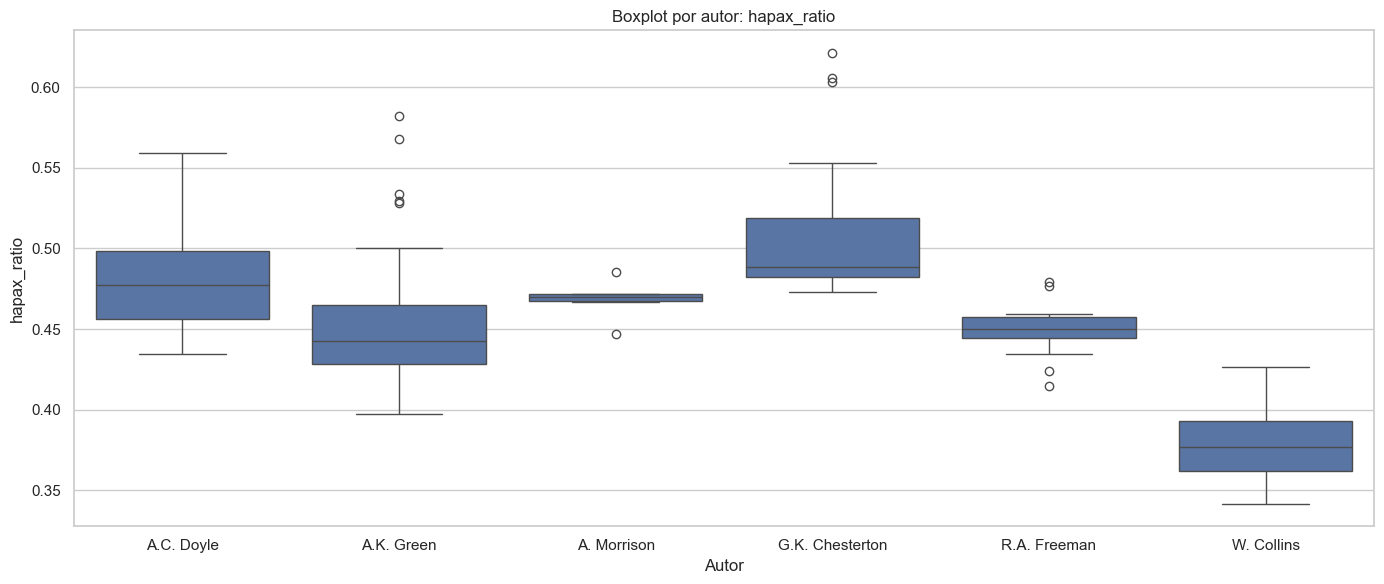

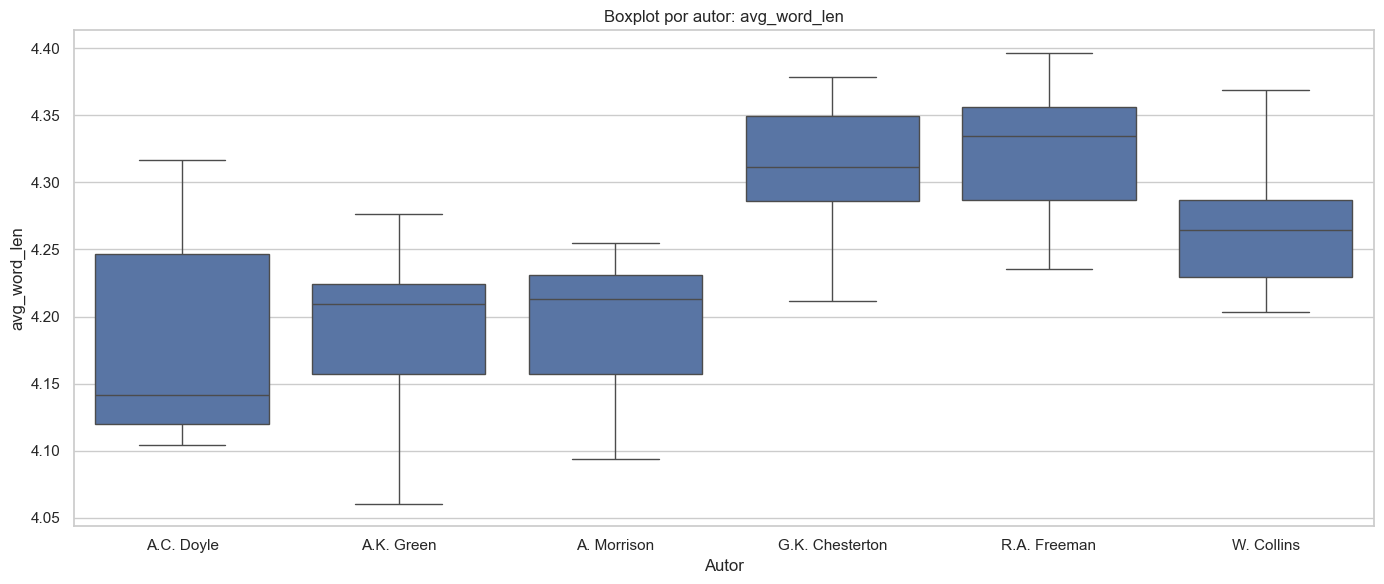

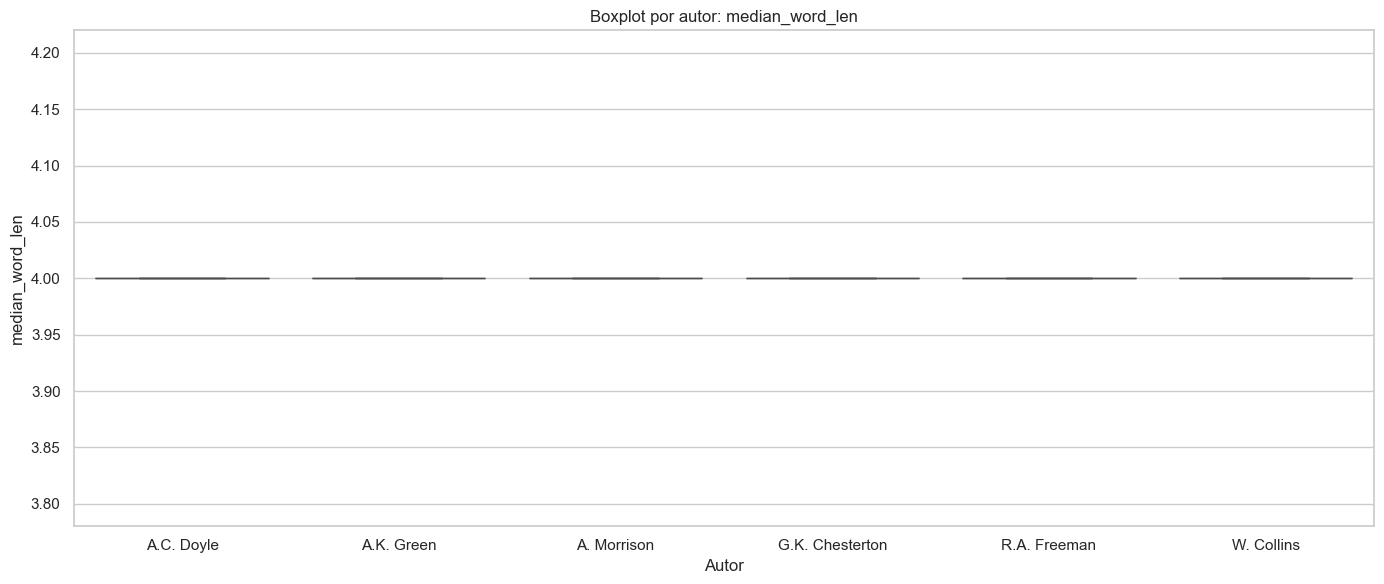

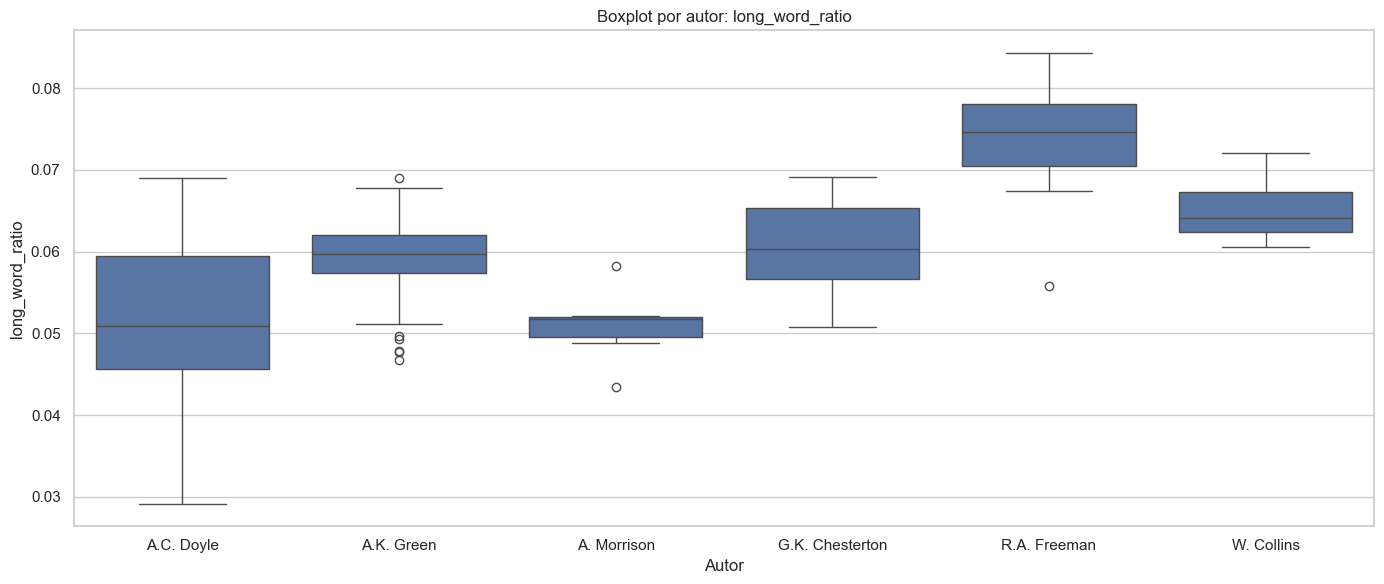

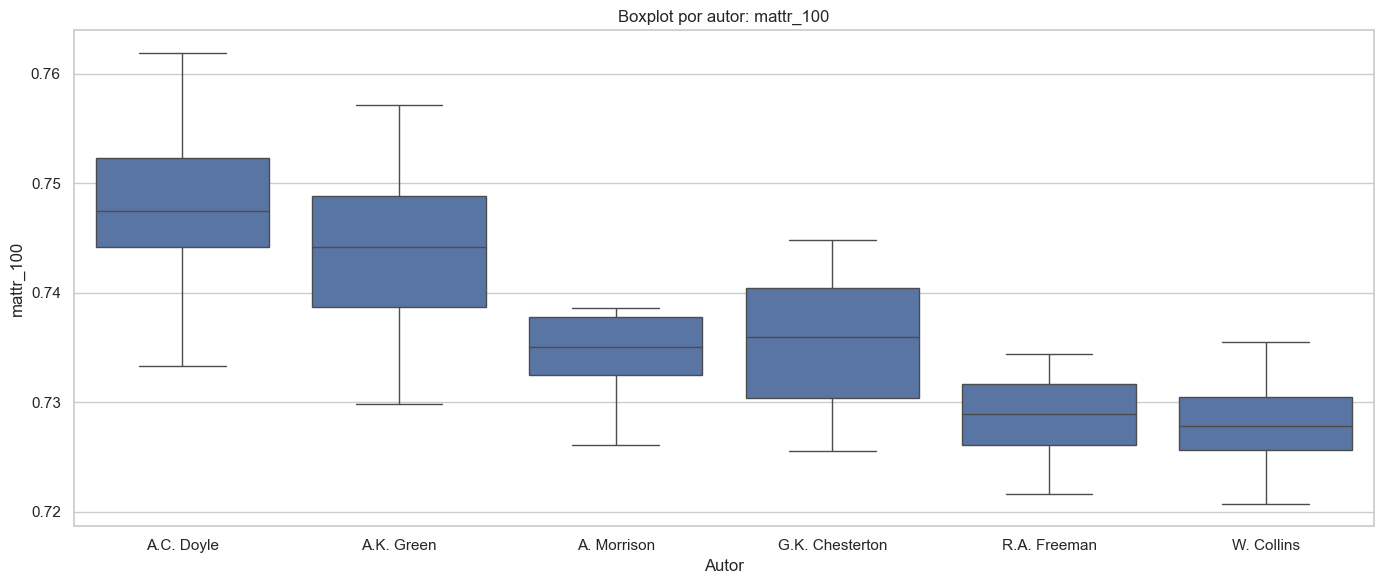

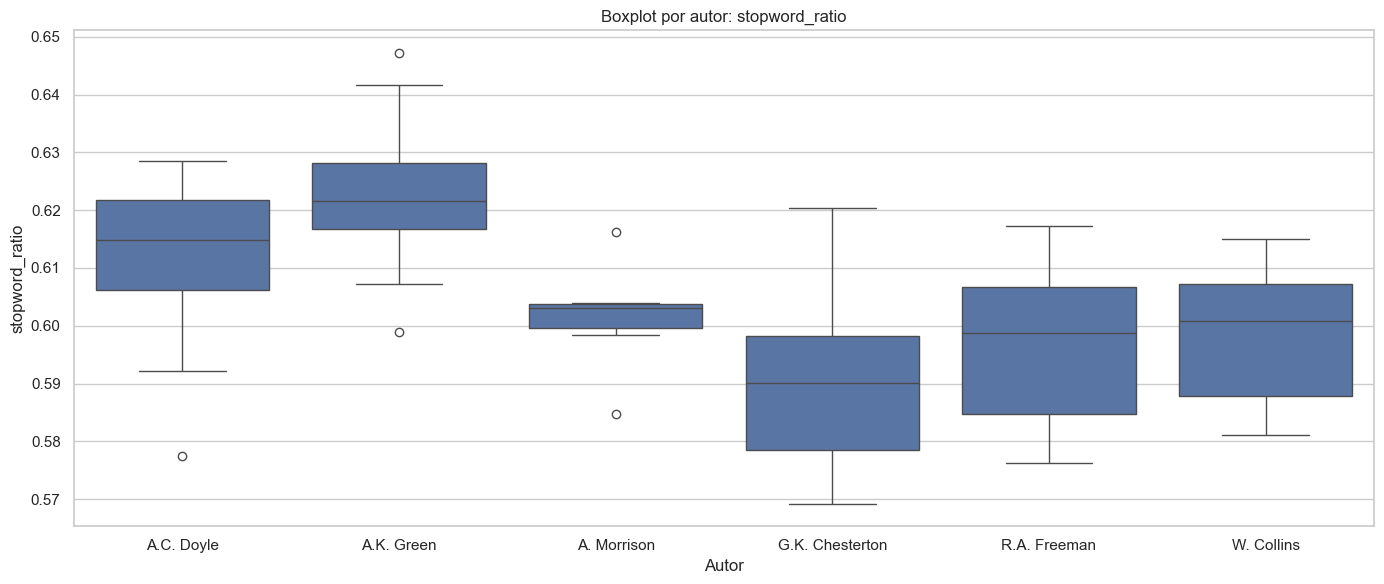

In [54]:
plot_metrics_boxplots_by_author(df_corpus, metric_cols, save_path=FIGS_DIR / "lexical_metrics_boxplots_by_author.png")

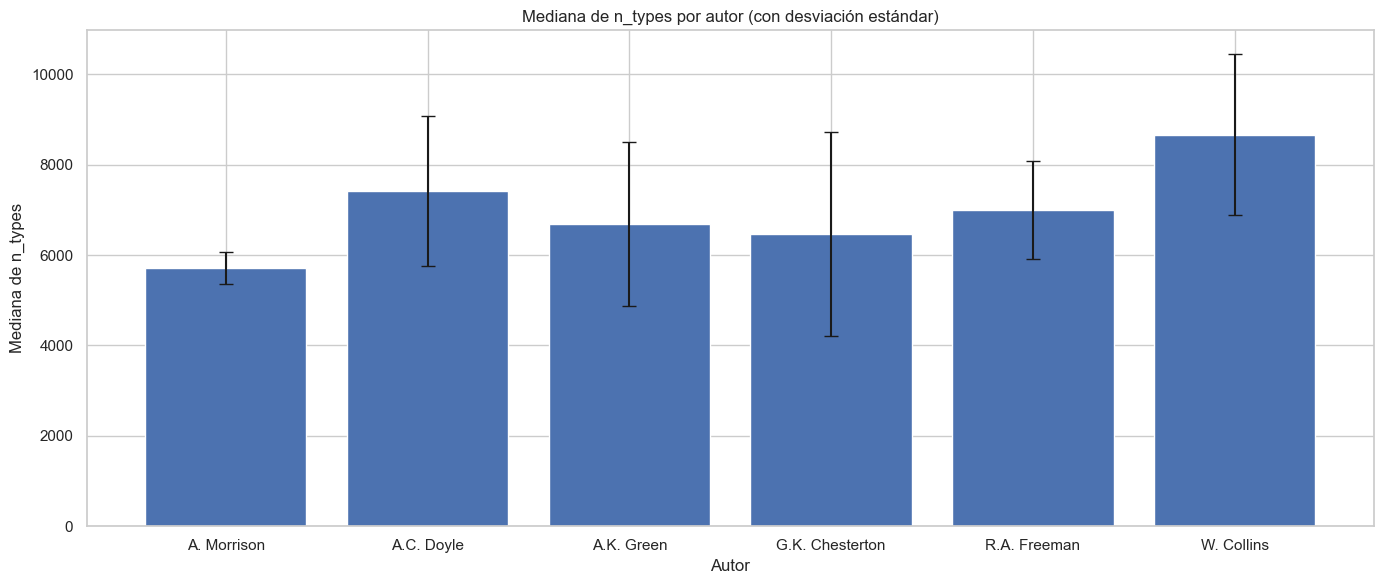

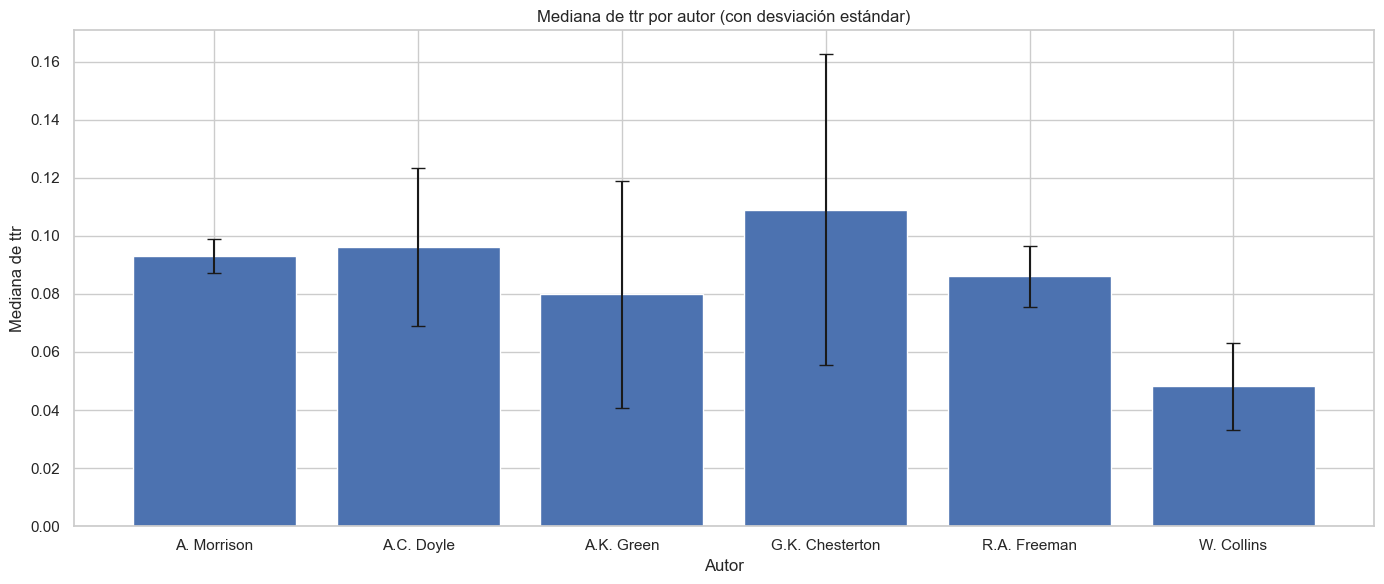

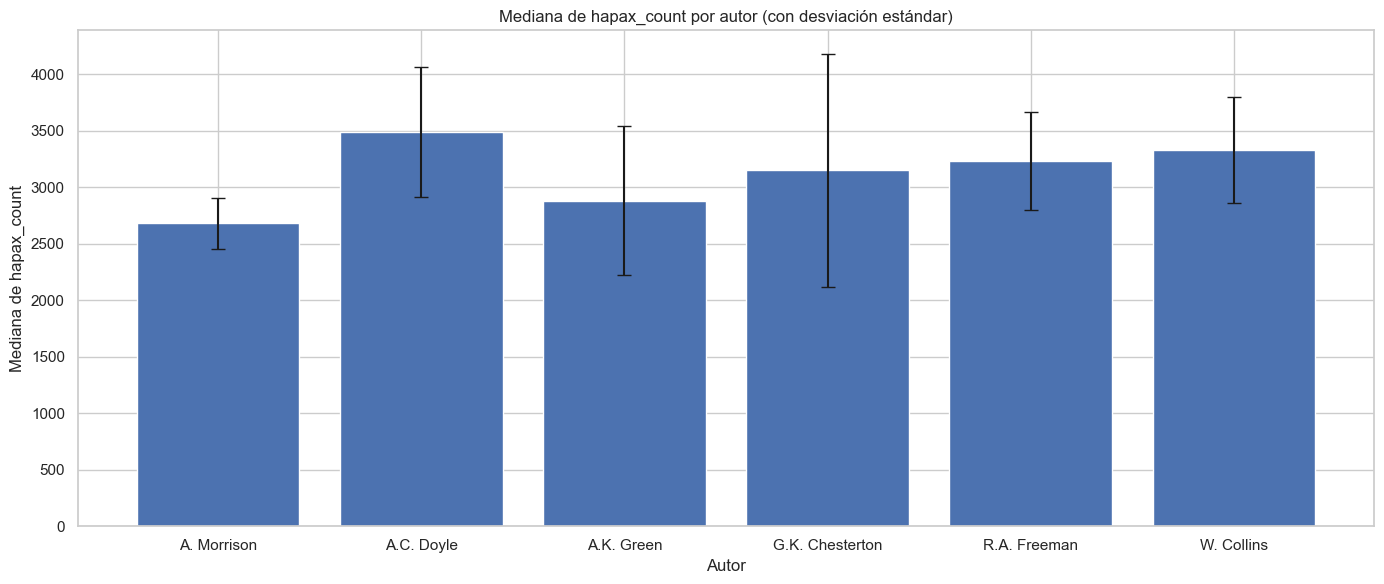

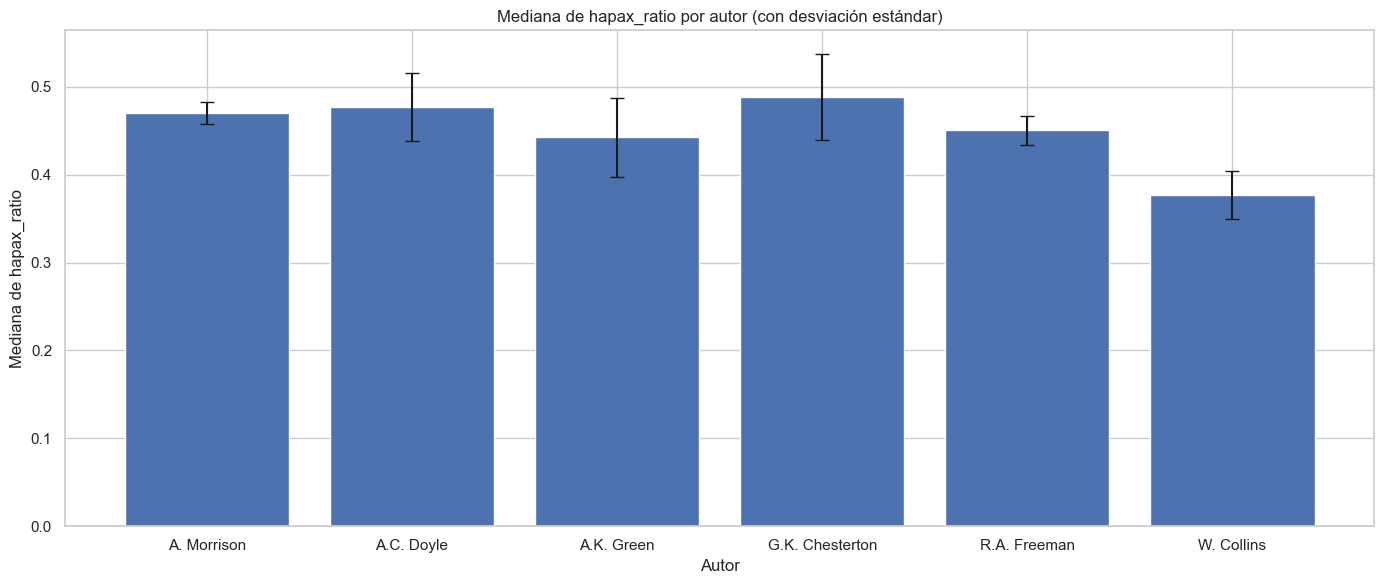

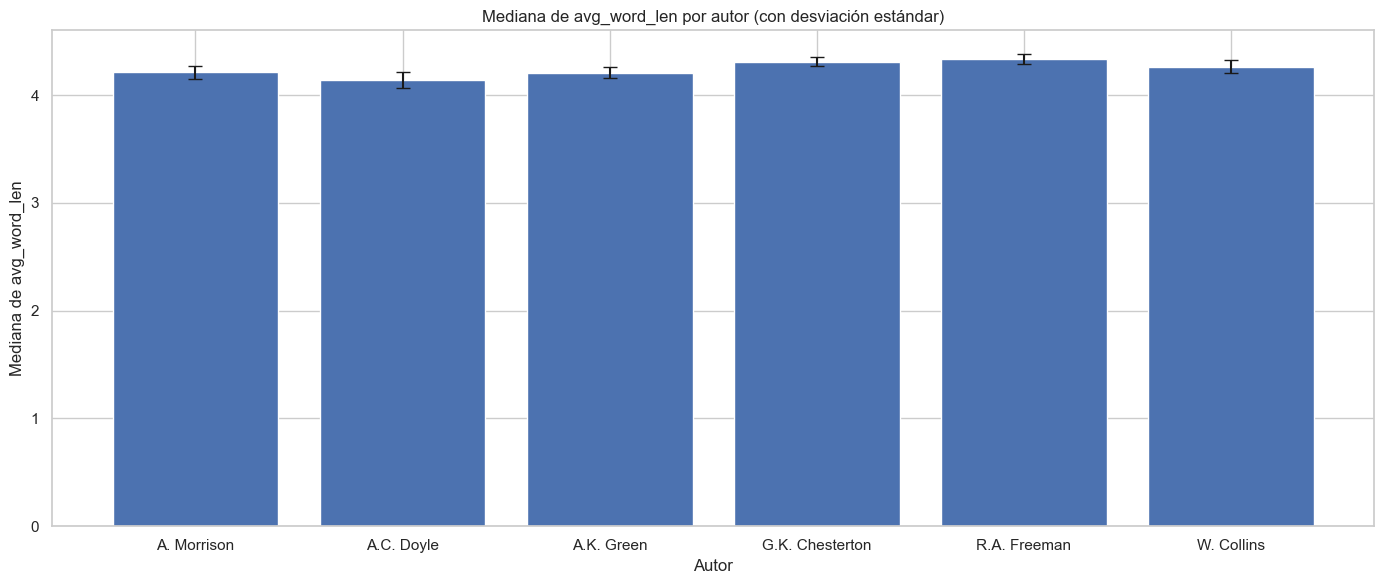

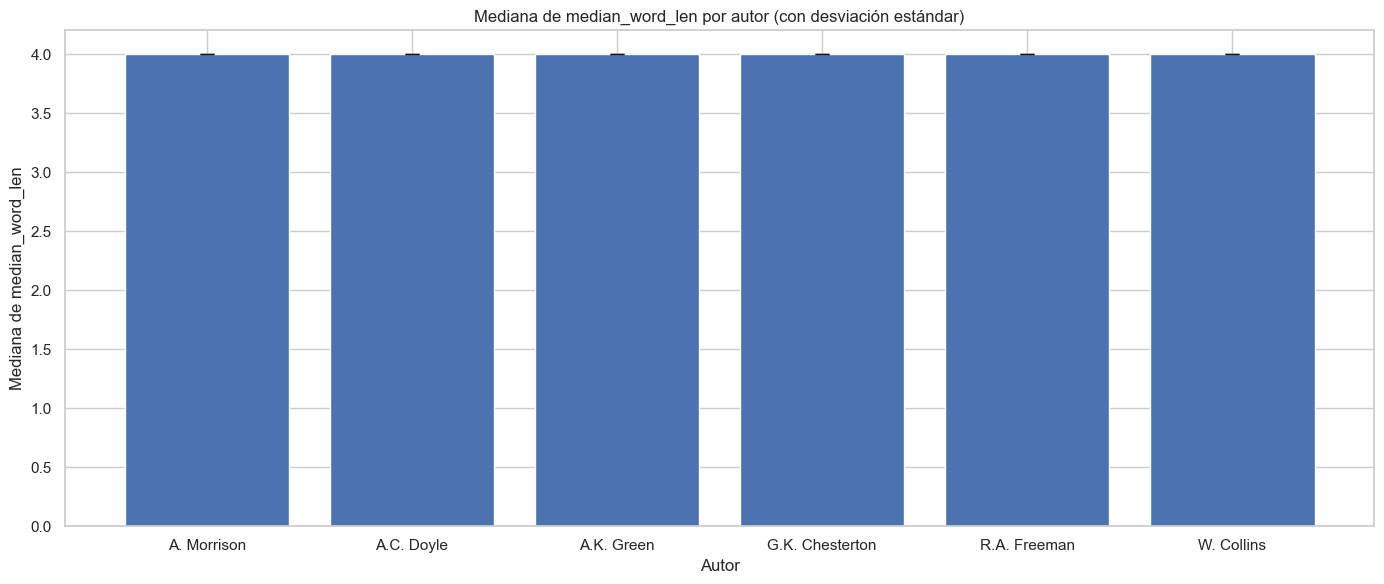

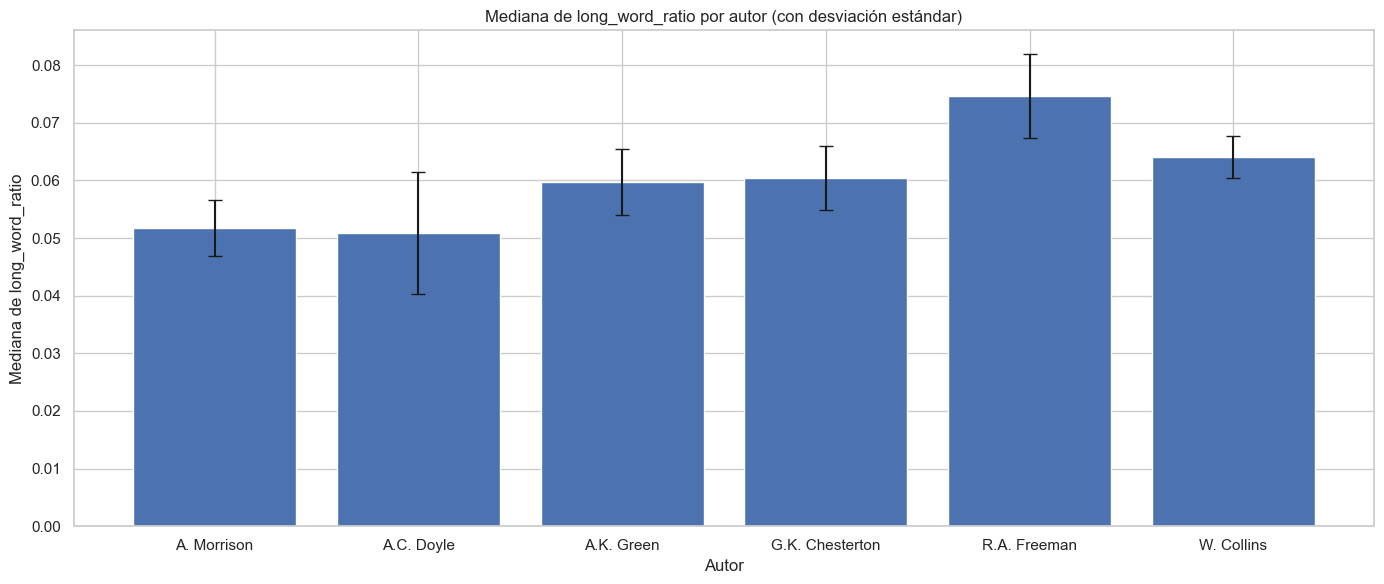

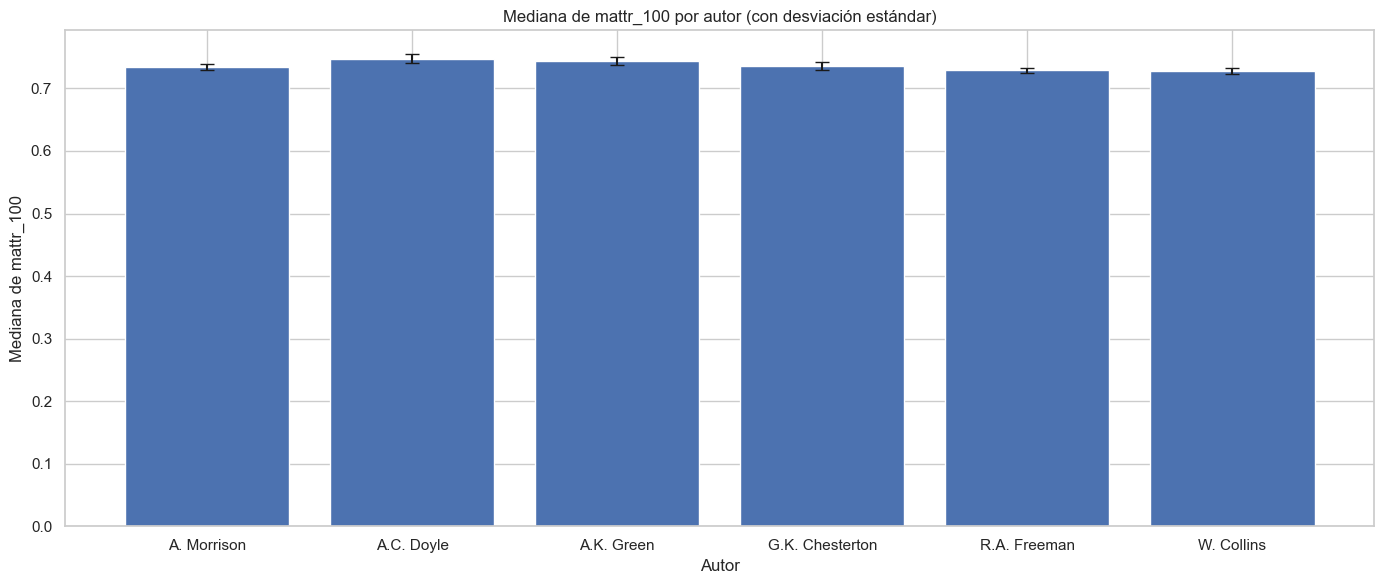

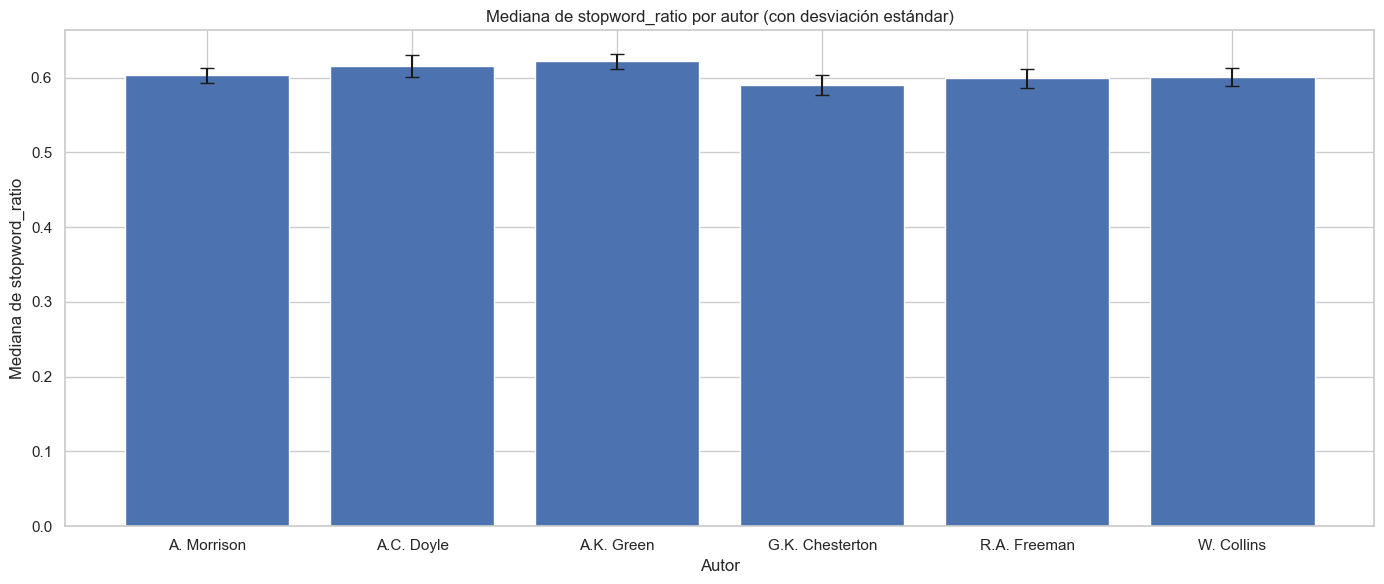

In [55]:
plot_bars_by_author_with_std(df_corpus, metric_cols, agg="median", save_path=FIGS_DIR / "bars_by_author_with_std.png")

Vamos a analizar varios pares de métricas léxicas para ver cómo se relacionan entre sí y si muestran patrones diferenciadores entre autores o entre novelas y relatos. En concreto, vamos a analizar los siguientes pares:

1. Dependencia con longitud del texto
  - `(n_tokens_all, n_types)`. Muestra cómo crece el vocabulario distinto con la longitud del texto.
  - `(n_tokens_all, ttr)`. Evidencia el sesgo de TTR con la longitud: suele disminuir conforme el texto es más largo.
  - `(n_tokens_all, mattr_100)`. Permite comprobar si MATTR (más robusta) es mucho menos dependiente del tamaño que TTR.
  - `(n_tokens_all, hapax_count)`. Indica si los hapax crecen casi linealmente con la longitud o si ciertos textos concentran más “raros” de lo esperado.
  - `(n_tokens_all, hapax_ratio)`. Mide cómo cambia la proporción de hapax con el tamaño, diferenciando diversidad real de efecto de longitud.
 
2. Diversidad léxica (comparar medidas entre sí)
  - `(n_types, ttr)`. Relaciona diversidad absoluta (tipos) con diversidad relativa (TTR) para ver si se comportan coherentemente.
  - `(n_types, mattr_100)`. Permite ver si textos con vocabulario más amplio también mantienen diversidad local alta en ventanas (MATTR).
  - `(hapax_ratio, ttr)`. Explora si mayor diversidad relativa viene acompañada de más palabras únicas, o si hay diversidad sin tantos hapax.
  - `(hapax_count, n_types)`. Mide qué parte del vocabulario distinto está compuesto por hapax y detecta textos con muchos tipos pero pocos hapax (o al revés).

3. Complejidad/longitud de palabra
  - `(avg_word_len, median_word_len)`. Sirve para detectar asimetrías: si la media se aleja de la mediana, hay cola de palabras muy largas.
  - `(avg_word_len, long_word_ratio)`. Comprueba si la media de longitud de palabra está explicada por una mayor proporción de palabras largas (consistencia interna).
4. Stopwords como señal de registro/estilo
  - `(stopword_ratio, mattr_100)`. Evalúa si una mayor carga de palabras funcionales reduce la diversidad local de contenido de forma consistente.
  - `(stopword_ratio, hapax_ratio)`. Indica si textos más “informativos” (menos stopwords) tienden a introducir más vocabulario raro/único.
  - `(stopword_ratio, avg_word_len)`. Sirve como proxy de densidad de contenido ya que más stopwords suele asociarse a palabras más cortas y menor densidad léxica.

In [56]:
scatter_pairs = [
    # Length effects
    ("n_tokens_all", "n_types"),
    ("n_tokens_all", "ttr"),
    ("n_tokens_all", "mattr_100"),
    ("n_tokens_all", "hapax_count"),
    ("n_tokens_all", "hapax_ratio"),
    # Diversity metrics relationships
    ("n_types", "ttr"),
    ("n_types", "mattr_100"),
    ("hapax_ratio", "ttr"),
    ("hapax_count", "n_types"),
    # Word-length
    ("avg_word_len", "median_word_len"),
    ("avg_word_len", "long_word_ratio"),
    # Stopwords as register/style signal
    ("stopword_ratio", "mattr_100"),
    ("stopword_ratio", "hapax_ratio"),
    ("stopword_ratio", "avg_word_len"),
]

In [57]:
plot_scatter_list_plotly(
    data=df_corpus,
    scatter_pairs=scatter_pairs,
    hue="author",
    work_col="title",
)

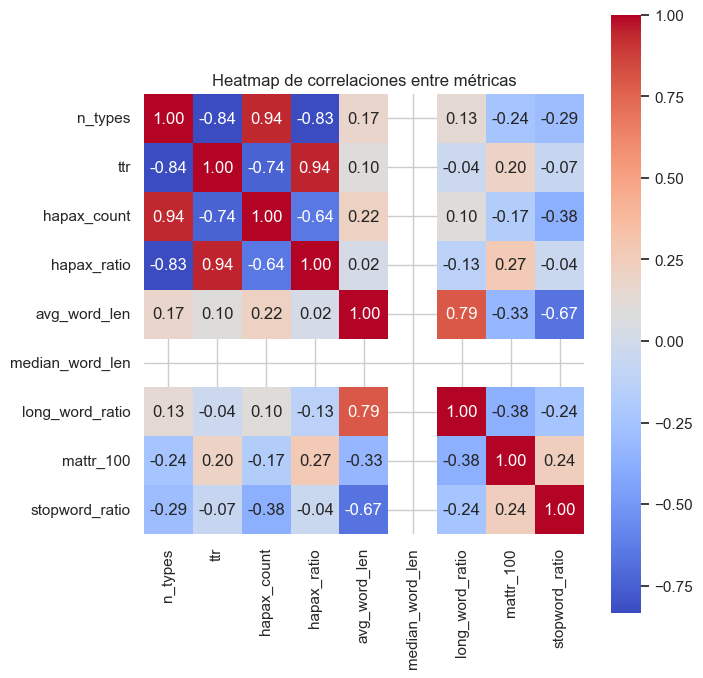

In [58]:
plot_metrics_correlations_heatmap(
    df_corpus, metric_cols, save_path=FIGS_DIR / "lexical_metrics_correlations_heatmap.png"
)

### Métricas de puntuación

En estilometría, las métricas de puntuación son útiles porque capturan rasgos formales del estilo que suelen ser relativamente estables y, en muchos casos, poco conscientes: la preferencia por comas frente a puntos, el uso de punto y coma o dos puntos, la frecuencia de paréntesis o rayas, o la presencia de signos de interrogación y exclamación. Estos patrones reflejan decisiones recurrentes sobre cómo el autor segmenta el discurso, introduce incisos, marca énfasis o gestiona el ritmo de la narración. Por ello, la puntuación actúa como una “huella” estilística complementaria al léxico, y puede contribuir a diferenciar autores incluso cuando los temas o el vocabulario varían.

Además, estas métricas permiten aproximarse a aspectos de la estructura y la complejidad sintáctica sin recurrir a análisis lingüísticos más complejos. Así, una mayor densidad de comas, incisos o signos como el punto y coma suele asociarse con oraciones más elaboradas o con mayor subordinación, mientras que la abundancia de puntos puede indicar un estilo más fragmentado o directo. También ayudan a caracterizar el registro y el género (por ejemplo, la puntuación asociada al diálogo mediante comillas o rayas) y a detectar posibles efectos editoriales o de normalización, ya que cambios de edición pueden alterar la puntuación y, con ello, el perfil estilométrico del texto.

In [59]:
metric_cols = [
    "comma_count",
    "period_count",
    "semicolon_count",
    "colon_count",
    "exclam_count",
    "question_count",
    "ellipsis_count",
    "quote_count",
    "dialog_dash_count",
    "hyphen_count",
    "parenthesis_count",
    "punctuation_count_total",
    "punctuation_ratio",
]

df_checked, outlier_summary_df = add_iqr_outlier_flags(df_corpus, metric_cols)
outlier_summary_df

,q1,q3,iqr,lower_bound,upper_bound,n_outliers,n_low_outliers,n_high_outliers
comma_count,3654.500000,6724.000000,3069.500000,-949.750000,11328.250000,6.0,0.0,6.0
period_count,2963.500000,5139.000000,2175.500000,-299.750000,8402.250000,7.0,0.0,7.0
semicolon_count,236.500000,726.500000,490.000000,-498.500000,1461.500000,3.0,0.0,3.0
colon_count,43.000000,154.500000,111.500000,-124.250000,321.750000,2.0,0.0,2.0
exclam_count,89.500000,332.000000,242.500000,-274.250000,695.750000,9.0,0.0,9.0
question_count,321.000000,664.500000,343.500000,-194.250000,1179.750000,8.0,0.0,8.0
ellipsis_count,0.000000,4.000000,4.000000,-6.000000,10.000000,16.0,0.0,16.0
quote_count,1962.000000,3921.500000,1959.500000,-977.250000,6860.750000,4.0,0.0,4.0
dialog_dash_count,195.000000,548.000000,353.000000,-334.500000,1077.500000,9.0,0.0,9.0
hyphen_count,276.000000,626.000000,350.000000,-249.000000,1151.000000,5.0,0.0,5.0


In [60]:
df_checked[df_checked["has_any_outlier"]][["file_name", "n_chars", "type", "outlier_metrics"]]

,file_name,n_chars,type,outlier_metrics
11,acd-the_white_company.txt,812443,novel,"[comma_count (high), exclam_count (high), hyph..."
19,akg-dark_hollow.txt,499453,novel,[ellipsis_count (high)]
21,akg-hand_and_ring.txt,796722,novel,"[colon_count (high), question_count (high), qu..."
38,akg-the_mystery_of_the_hasty_arrow.txt,508761,novel,[ellipsis_count (high)]
51,am-the_hole_in_the_wall.txt,347697,novel,[ellipsis_count (high)]
52,gkc-four_faultless_felons.txt,392713,short stories,[ellipsis_count (high)]
53,gkc-manalive.txt,324494,novel,[ellipsis_count (high)]
54,gkc-the_club_of_queer_trades.txt,246058,short stories,[ellipsis_count (high)]
56,gkc-the_incredulity_of_father_brown.txt,392556,short stories,"[ellipsis_count (high), punctuation_ratio (low)]"
61,gkc-the_napoleon_of_notting_hill.txt,307143,novel,[ellipsis_count (high)]


Además de los conteos absolutos, hemos calculado las frecuencias normalizadas de puntuación por cada 1.000 tokens alfabéticos. Esta normalización es importante porque los conteos brutos dependen mucho de la longitud del texto. Al expresar el uso de la puntuación como tasas, resulta posible comparar de forma más justa textos de distinto tamaño e interpretar estas variables como tendencias estilísticas y no solo como consecuencia de la extensión de la obra. Estas métricas ayudan a captar diferencias en el ritmo sintáctico, la expresividad y la representación del diálogo dentro del corpus.

In [61]:
metric_cols = [
    "comma_count_per_1000",
    "period_count_per_1000",
    "semicolon_count_per_1000",
    "colon_count_per_1000",
    "exclam_count_per_1000",
    "question_count_per_1000",
    "ellipsis_count_per_1000",
    "quote_count_per_1000",
    "dialog_dash_count_per_1000",
    "hyphen_count_per_1000",
    "parenthesis_count_per_1000",
]

df_checked, outlier_summary_df = add_iqr_outlier_flags(df_corpus, metric_cols)
outlier_summary_df

,q1,q3,iqr,lower_bound,upper_bound,n_outliers,n_low_outliers,n_high_outliers
comma_count_per_1000,49.711157,59.907430,10.196273,34.416748,75.201840,0.0,0.0,0.0
period_count_per_1000,39.451758,45.688304,6.236545,30.096940,55.043122,3.0,1.0,2.0
semicolon_count_per_1000,3.919703,6.183848,2.264145,0.523486,9.580065,10.0,2.0,8.0
colon_count_per_1000,0.509320,1.482224,0.972905,-0.950037,2.941581,0.0,0.0,0.0
exclam_count_per_1000,1.398466,3.297881,1.899415,-1.450656,6.147003,1.0,0.0,1.0
question_count_per_1000,4.360014,6.003299,1.643285,1.895087,8.468226,1.0,0.0,1.0
ellipsis_count_per_1000,0.000000,0.036346,0.036346,-0.054519,0.090865,19.0,0.0,19.0
quote_count_per_1000,25.943042,35.780653,9.837610,11.186627,50.537068,3.0,3.0,0.0
dialog_dash_count_per_1000,2.959307,5.577681,2.618373,-0.968252,9.505240,4.0,0.0,4.0
hyphen_count_per_1000,3.518891,5.449875,1.930985,0.622414,8.346352,2.0,0.0,2.0


In [62]:
df_checked[df_checked["has_any_outlier"]][["file_name", "n_chars", "type", "outlier_metrics"]]

,file_name,n_chars,type,outlier_metrics
3,acd-the_case_book_of_sherlock_holmes.txt,444978,short stories,"[period_count_per_1000 (high), ellipsis_count_..."
7,acd-the_poison_belt.txt,163040,novel,"[semicolon_count_per_1000 (low), ellipsis_coun..."
8,acd-the_return_of_sherlock_holmes.txt,610322,short stories,[semicolon_count_per_1000 (low)]
19,akg-dark_hollow.txt,499453,novel,[ellipsis_count_per_1000 (high)]
38,akg-the_mystery_of_the_hasty_arrow.txt,508761,novel,[ellipsis_count_per_1000 (high)]
43,akg-three_thousand_dollars.txt,66075,novel,[period_count_per_1000 (high)]
50,am-the_red_triangle.txt,334674,short stories,[dialog_dash_count_per_1000 (high)]
51,am-the_hole_in_the_wall.txt,347697,novel,"[semicolon_count_per_1000 (high), ellipsis_cou..."
52,gkc-four_faultless_felons.txt,392713,short stories,[ellipsis_count_per_1000 (high)]
53,gkc-manalive.txt,324494,novel,"[ellipsis_count_per_1000 (high), parenthesis_c..."


#### Visualización de las métricas léxicas

In [63]:
metric_cols = [
    "comma_count_per_1000",
    "period_count_per_1000",
    "semicolon_count_per_1000",
    "colon_count_per_1000",
    "exclam_count_per_1000",
    "question_count_per_1000",
    "ellipsis_count_per_1000",
    "quote_count_per_1000",
    "dialog_dash_count_per_1000",
    "hyphen_count_per_1000",
    "parenthesis_count_per_1000",
    "punctuation_ratio",
]

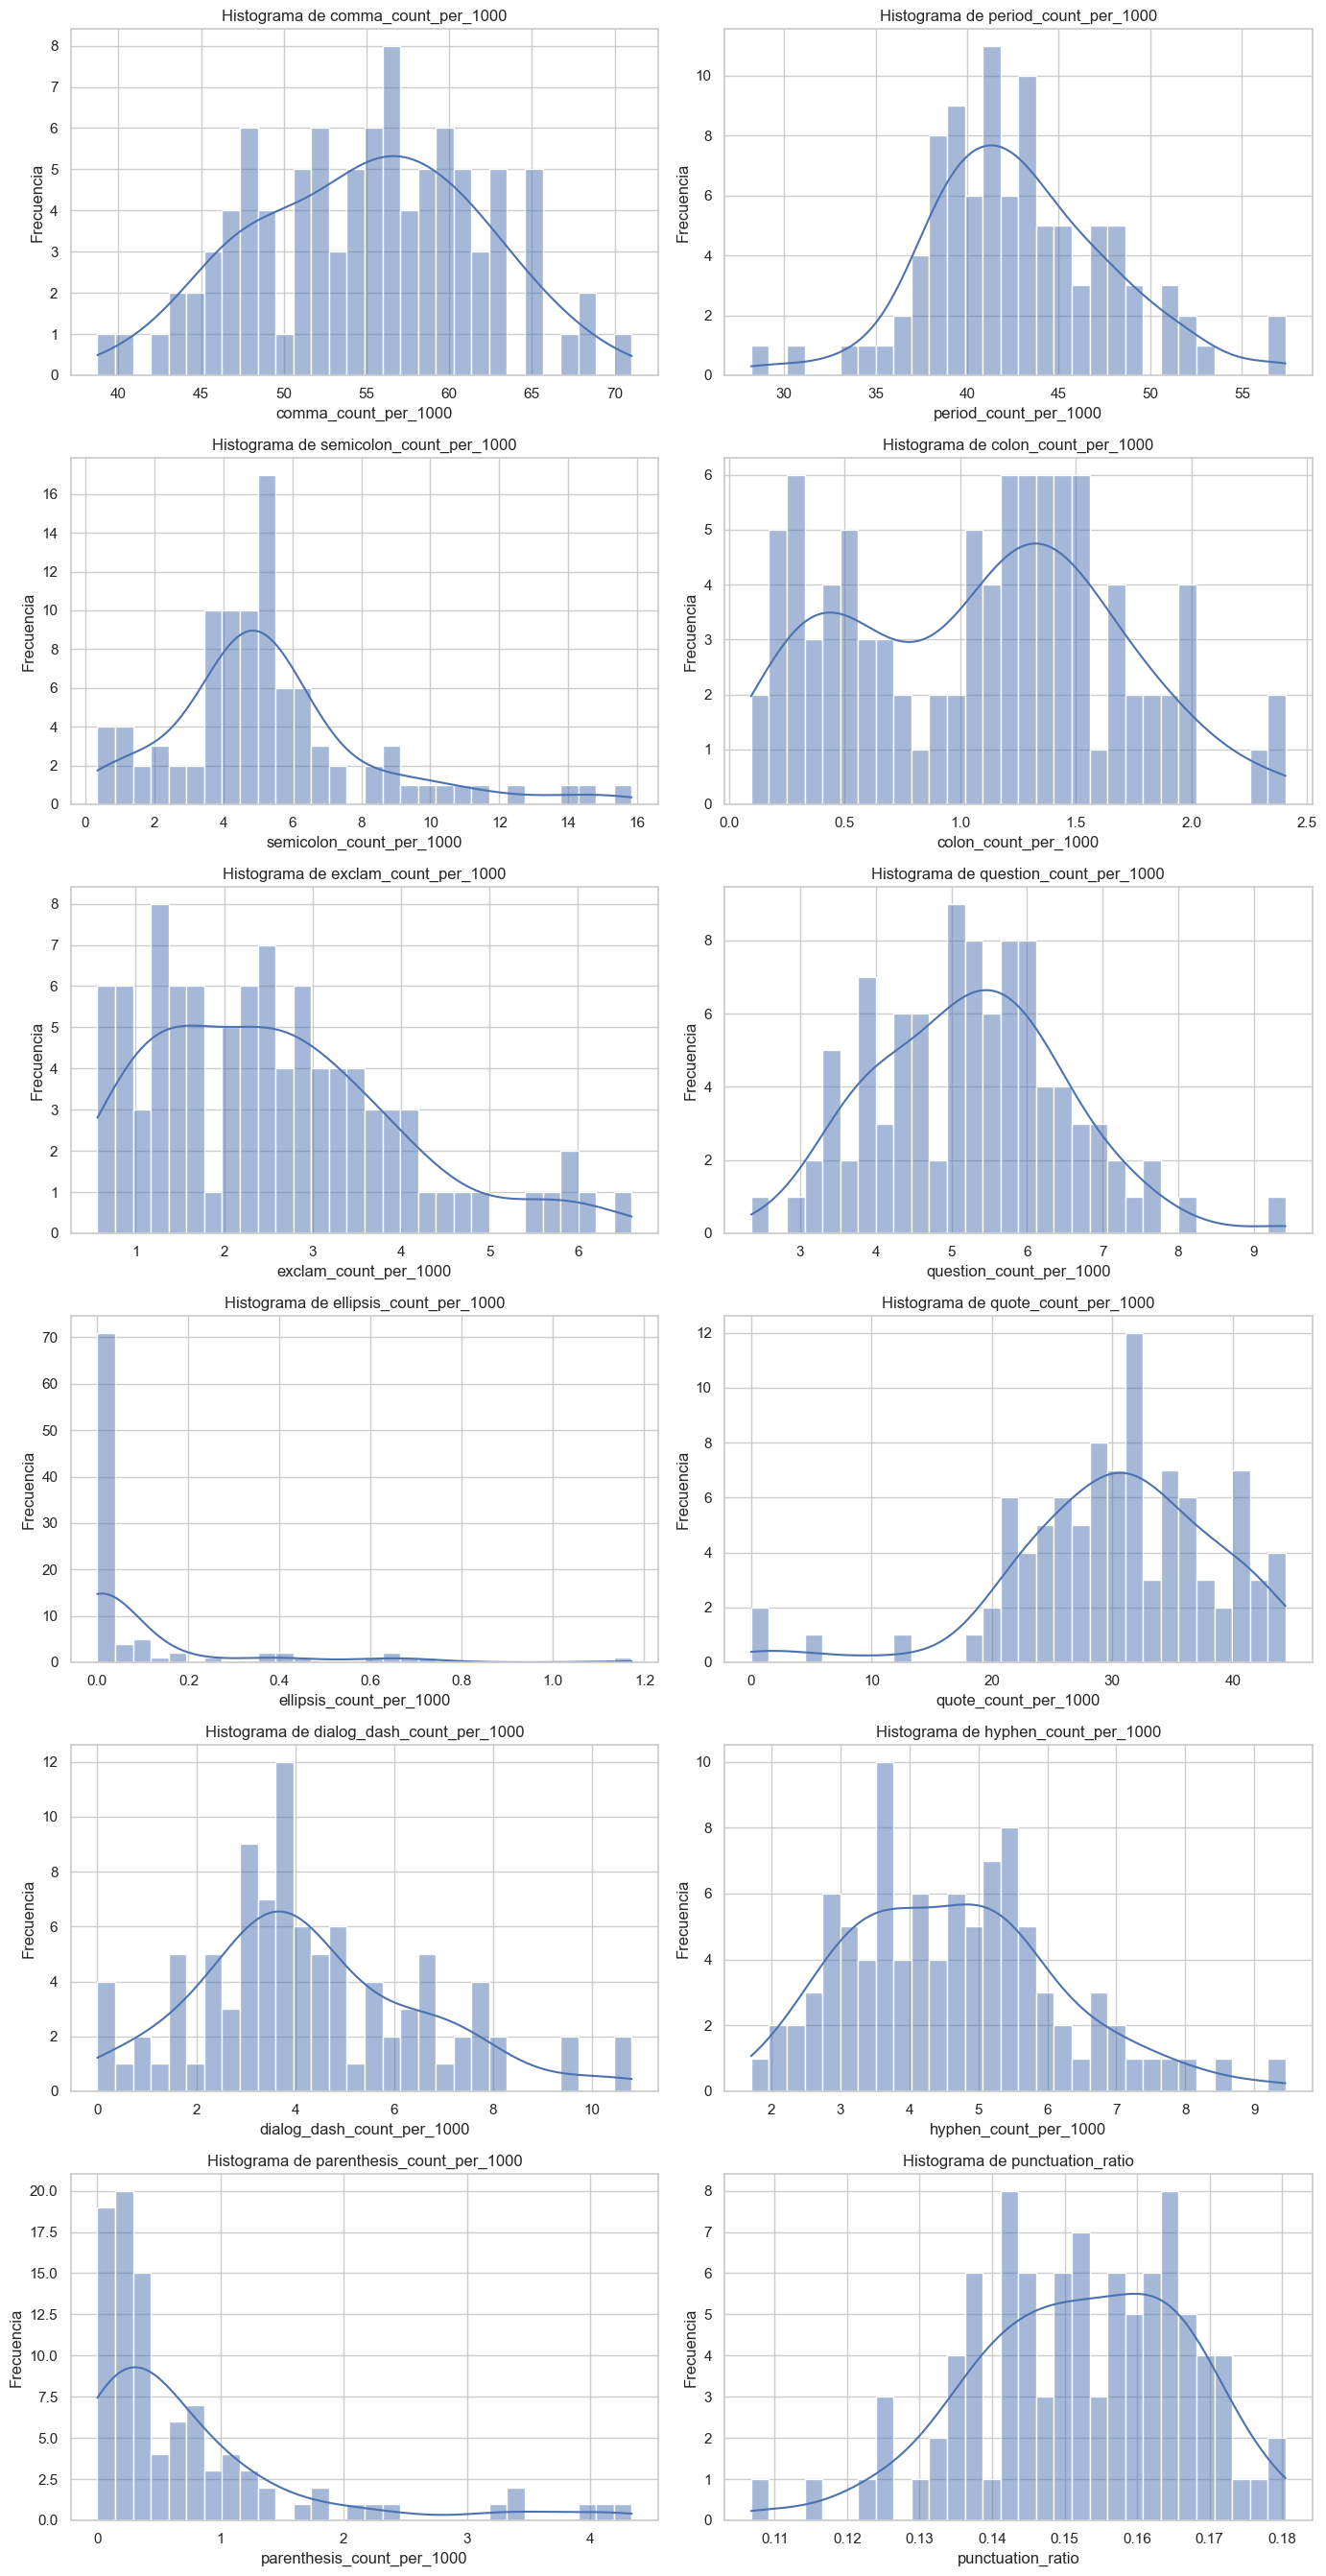

In [64]:
plot_metrics_histograms(df_corpus, metric_cols, save_path=FIGS_DIR / "punctuation_metrics_histograms.png")

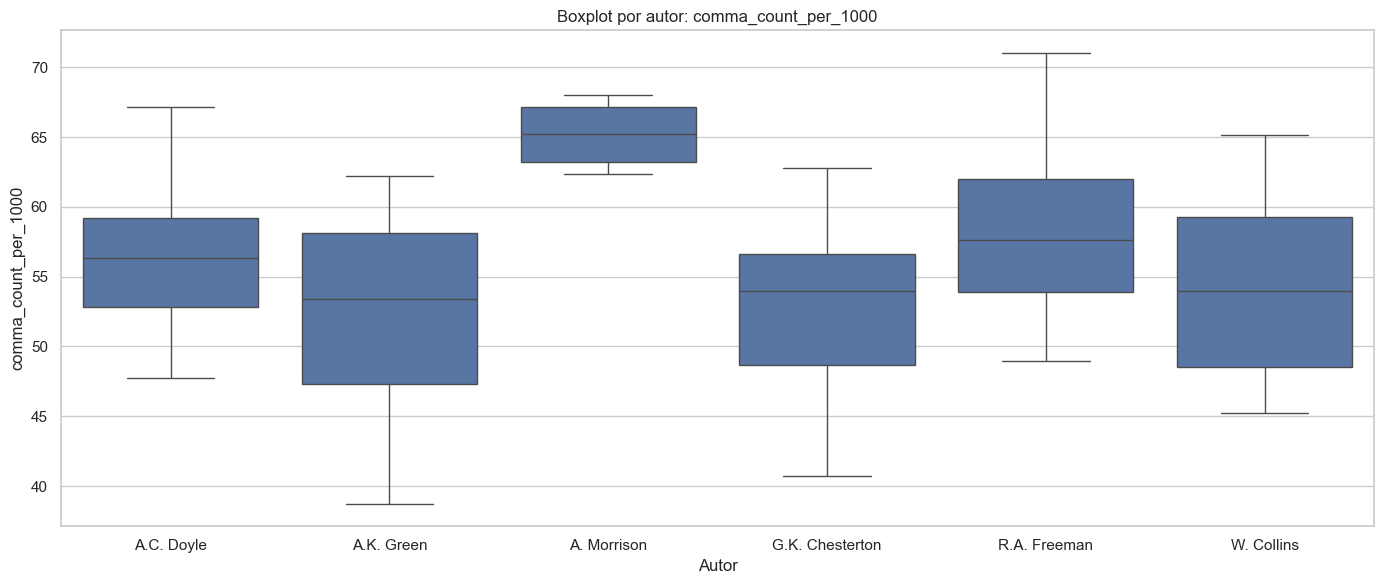

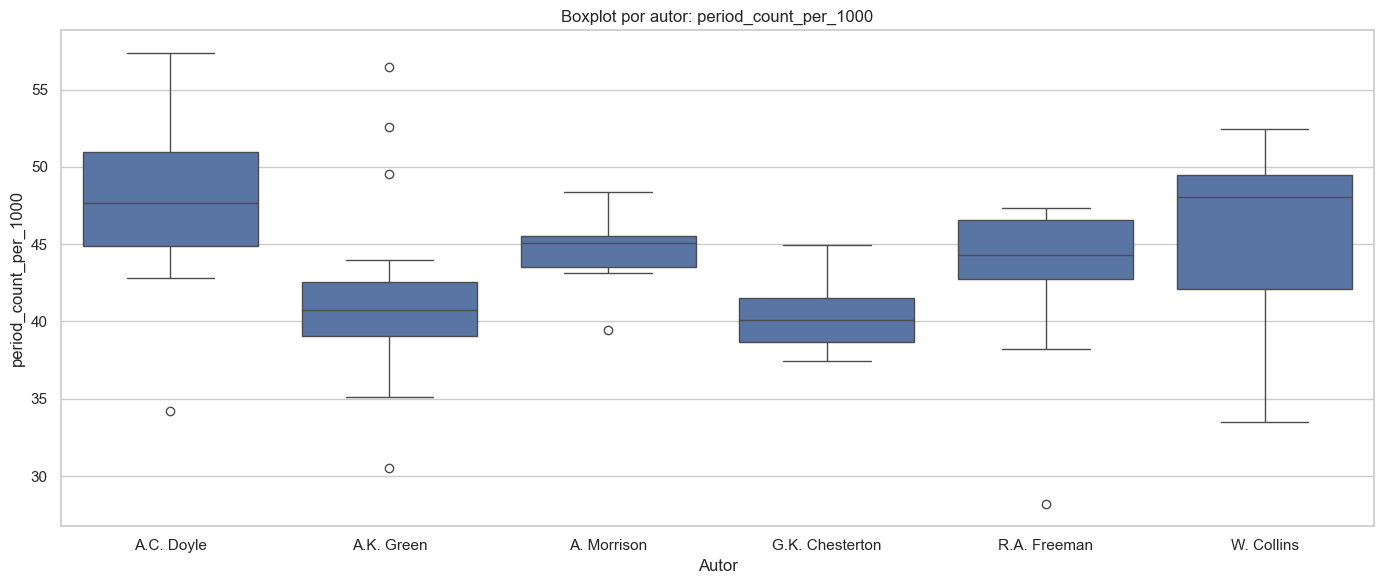

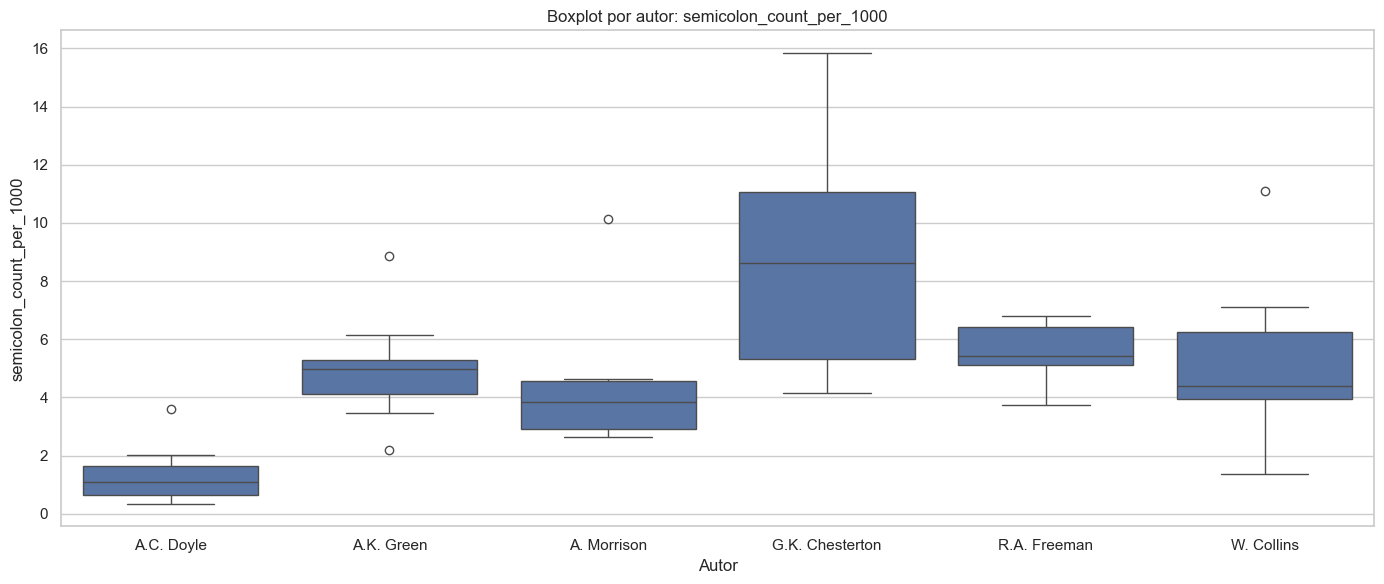

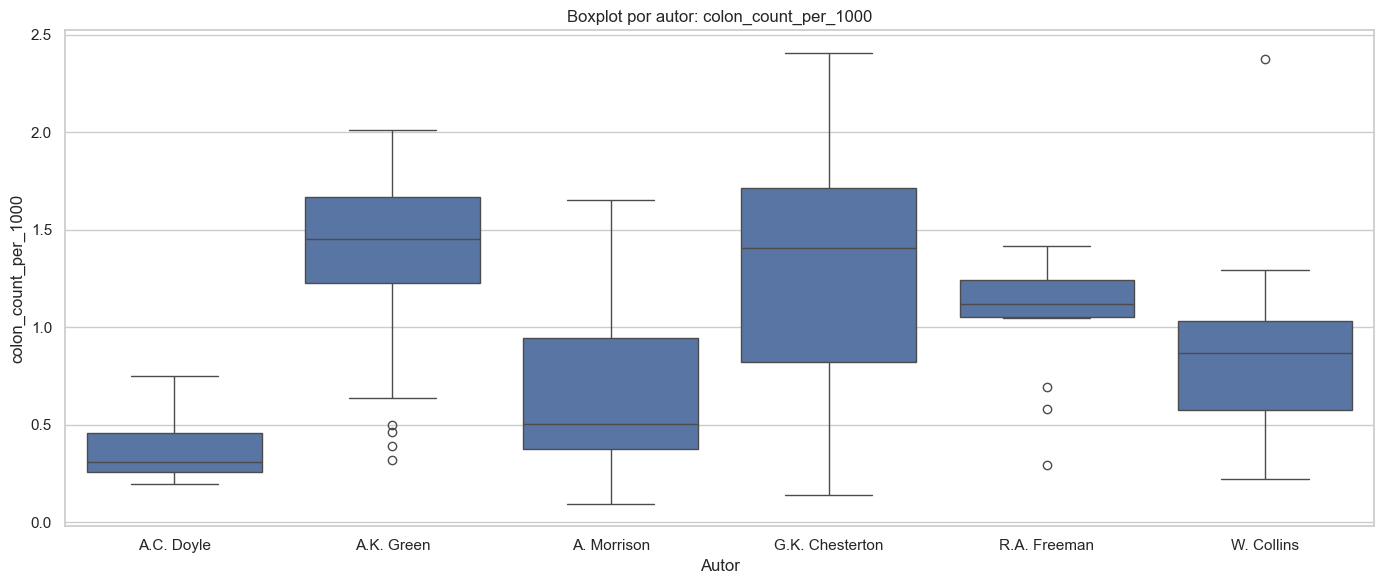

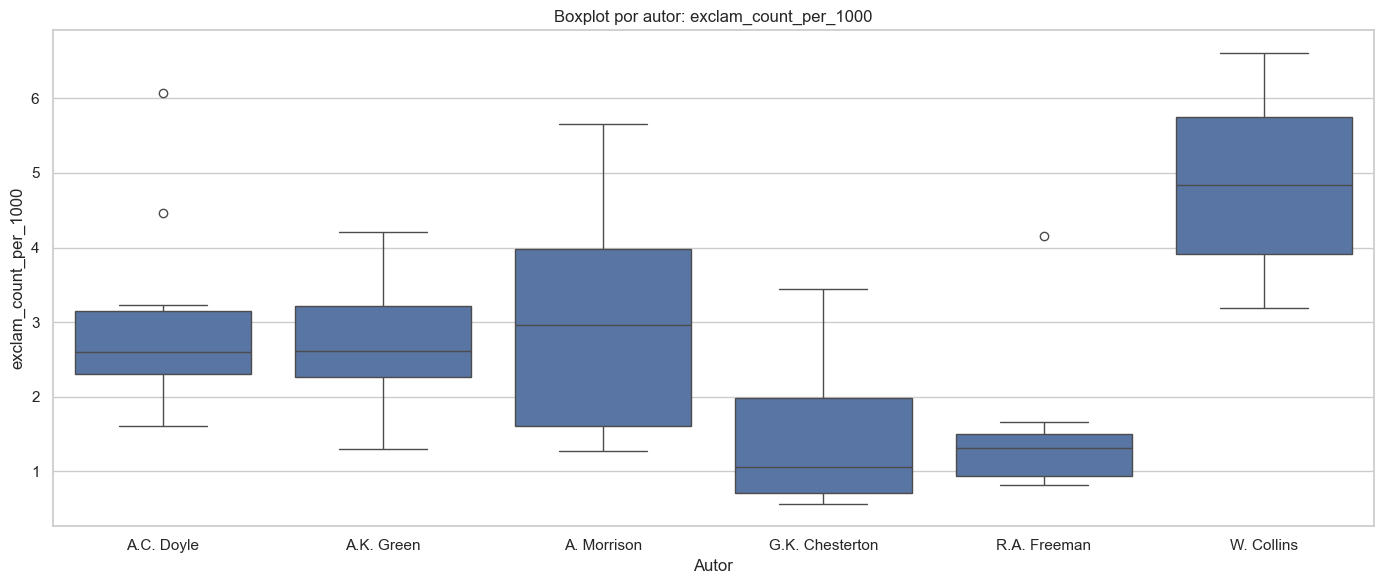

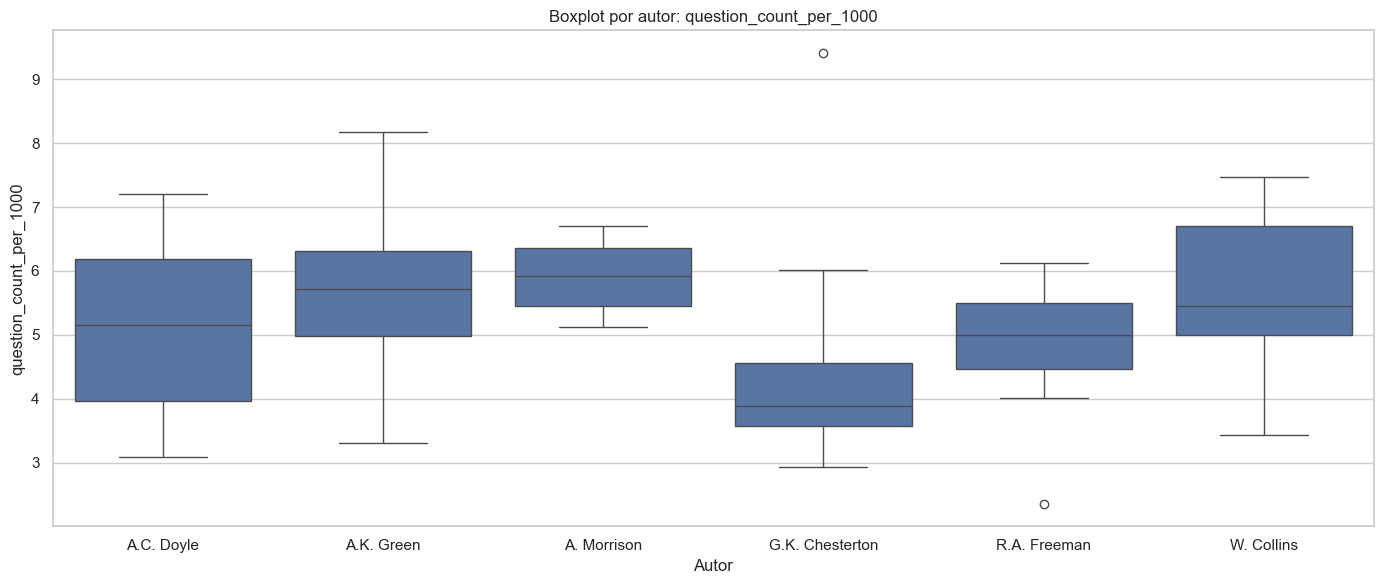

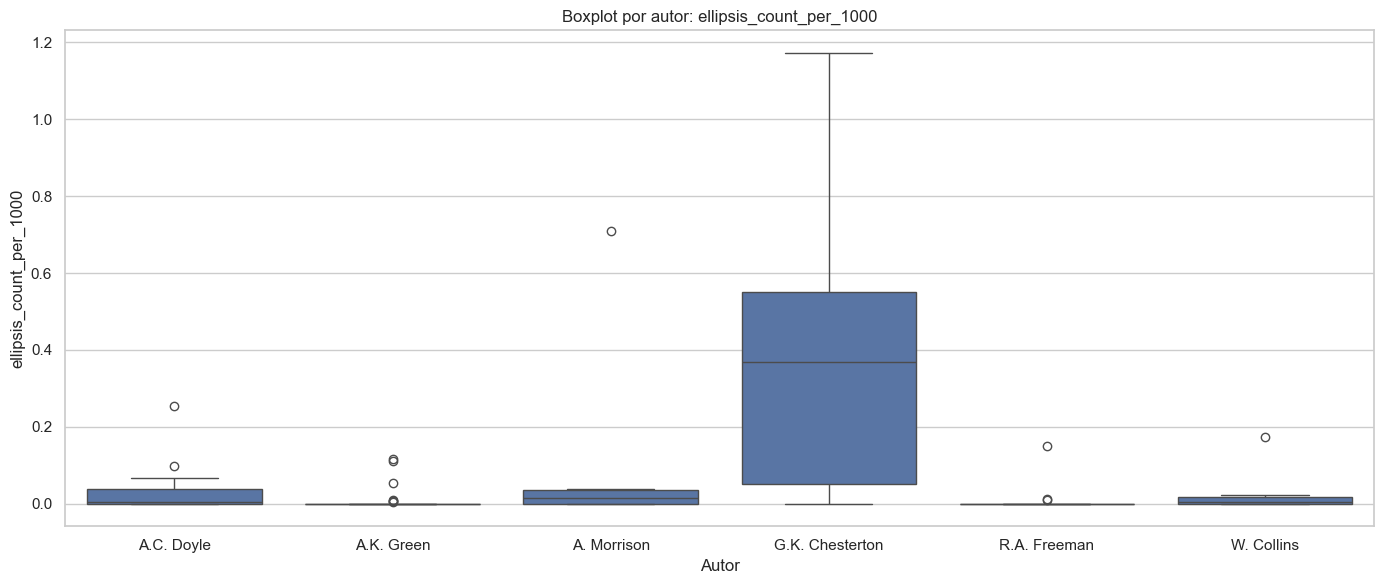

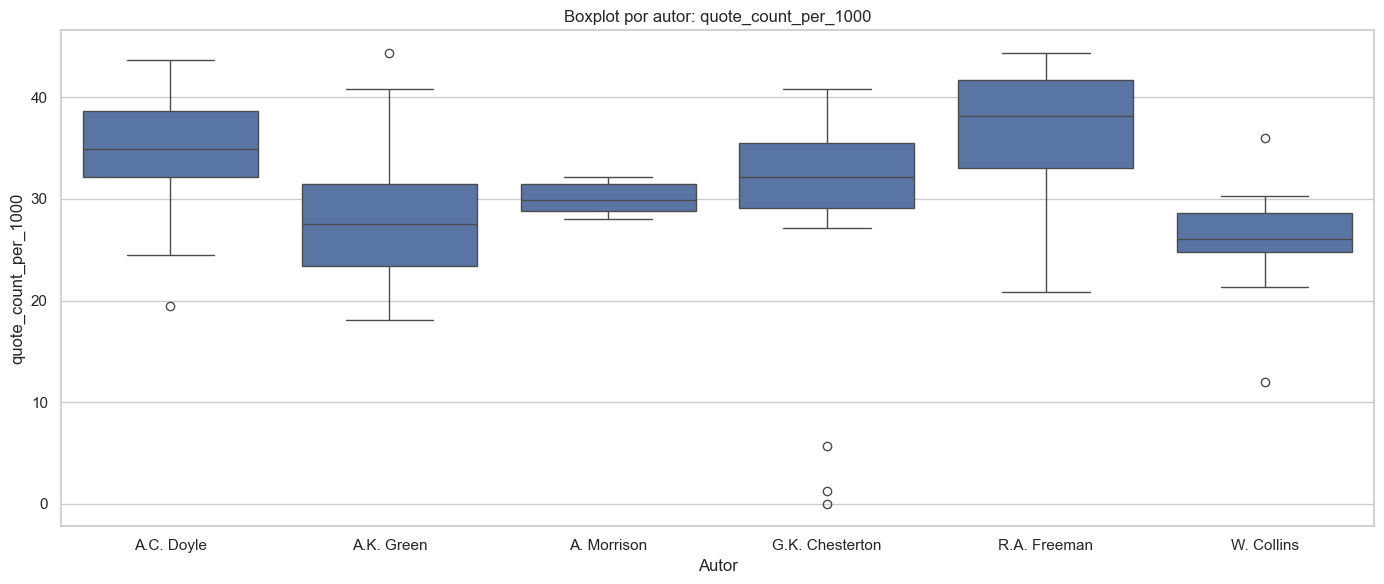

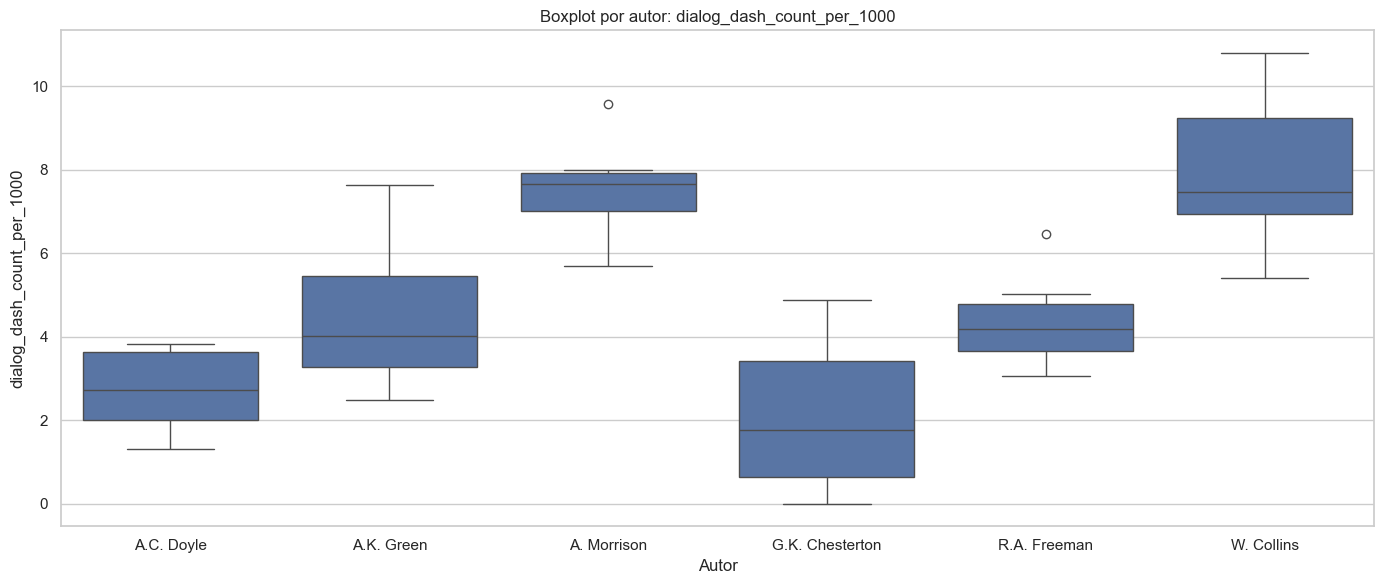

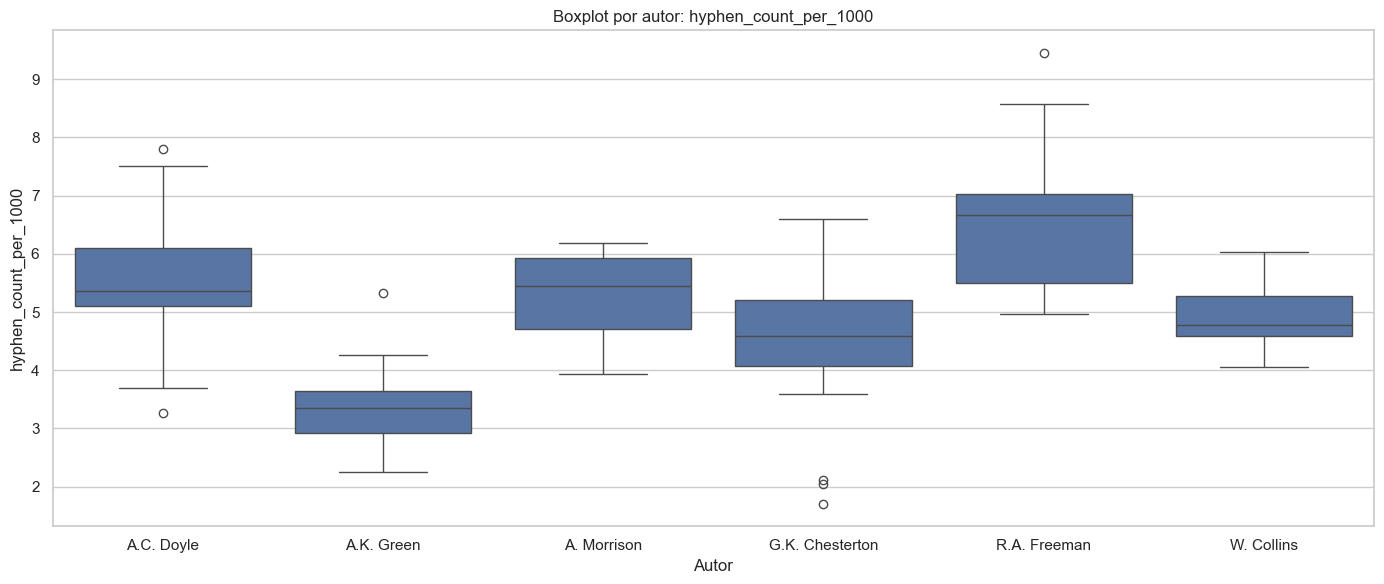

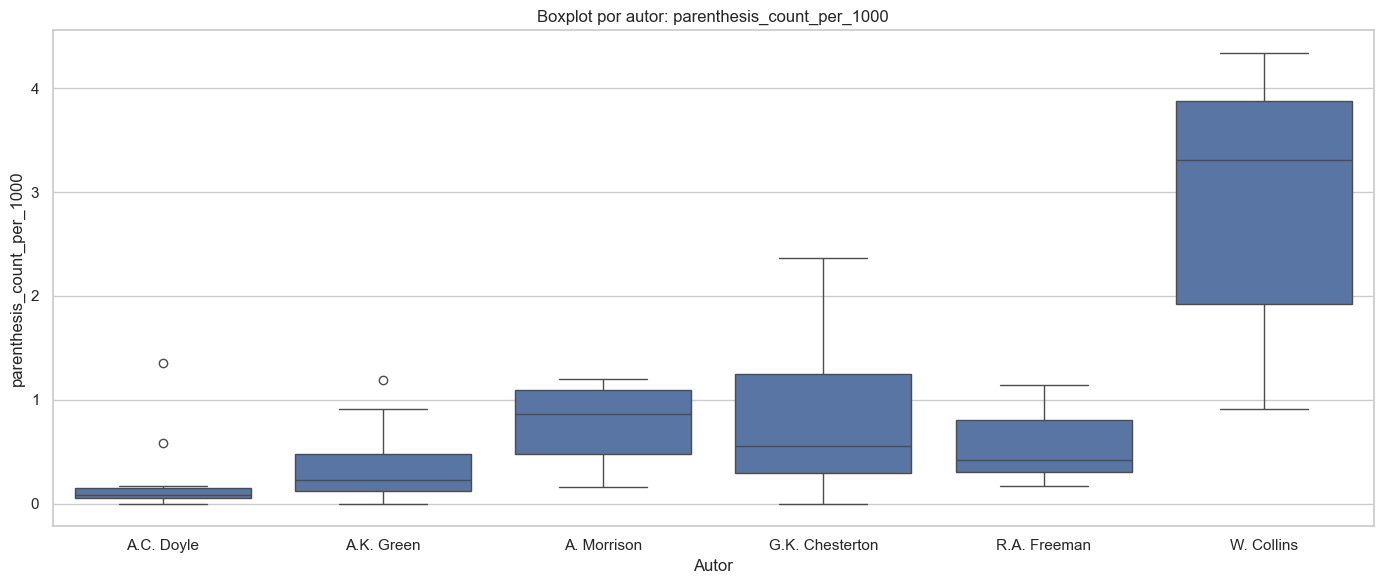

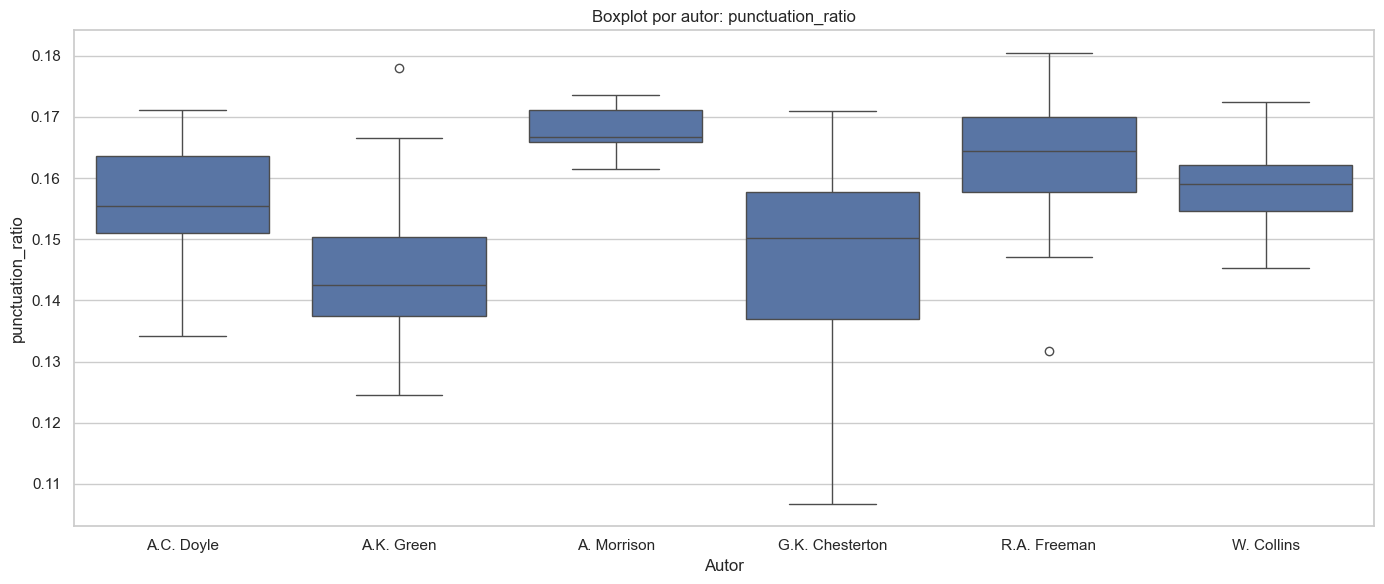

In [65]:
plot_metrics_boxplots_by_author(
    df_corpus, metric_cols, save_path=FIGS_DIR / "punctuation_metrics_boxplots_by_author.png"
)

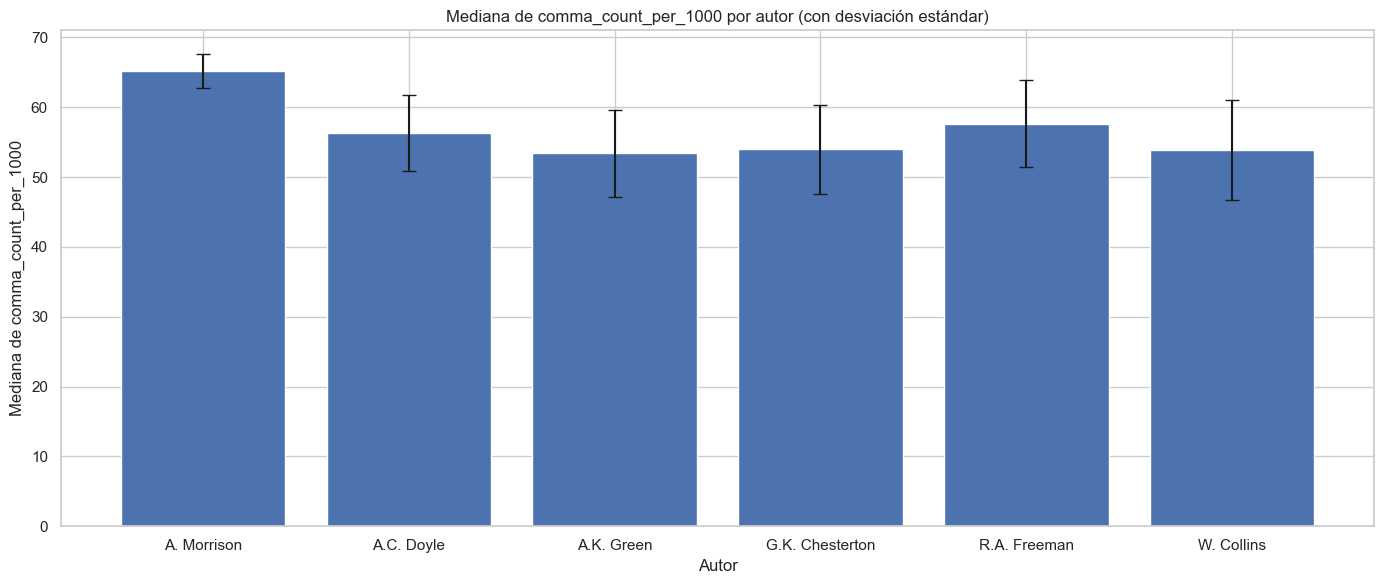

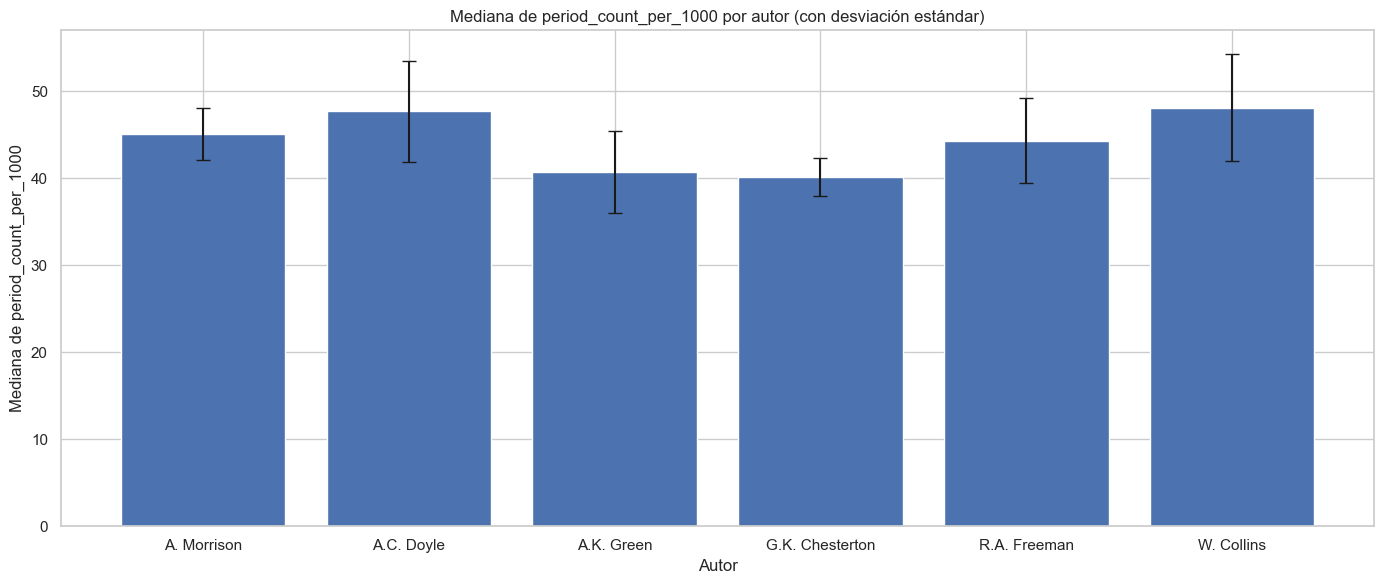

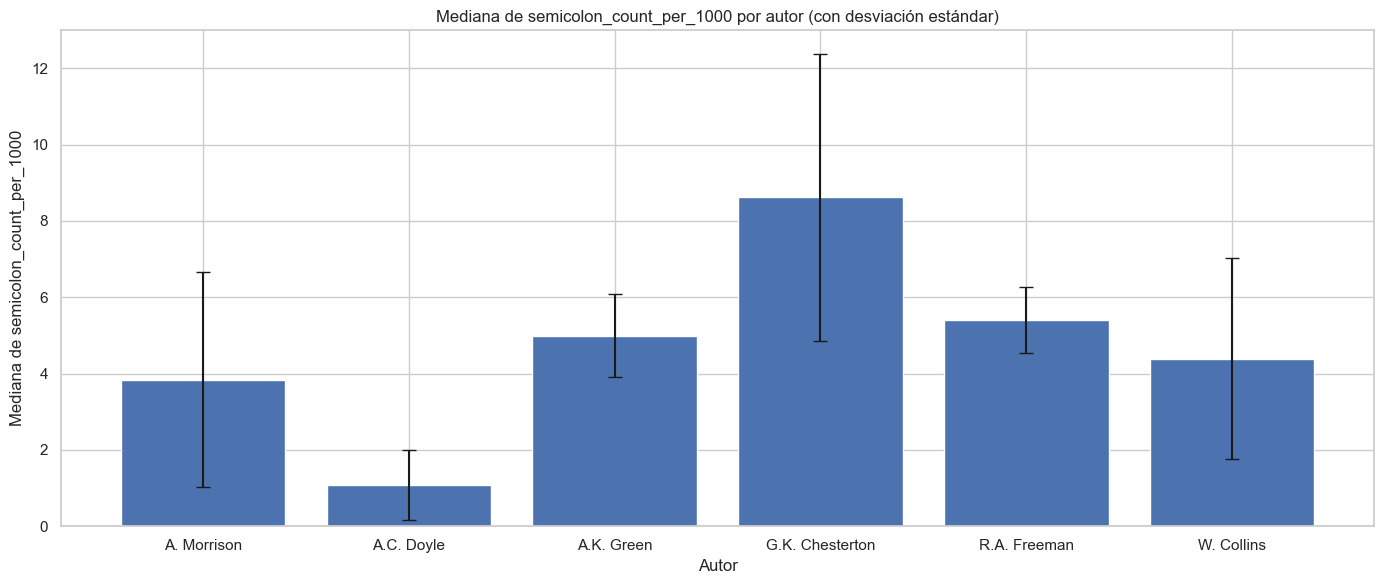

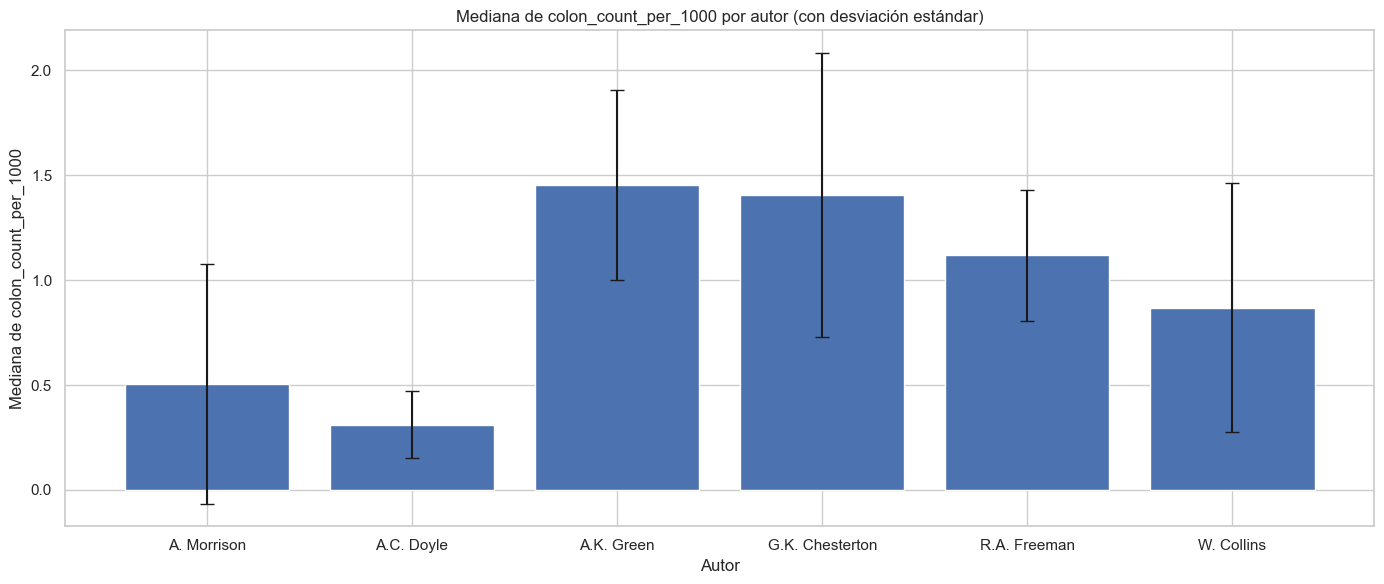

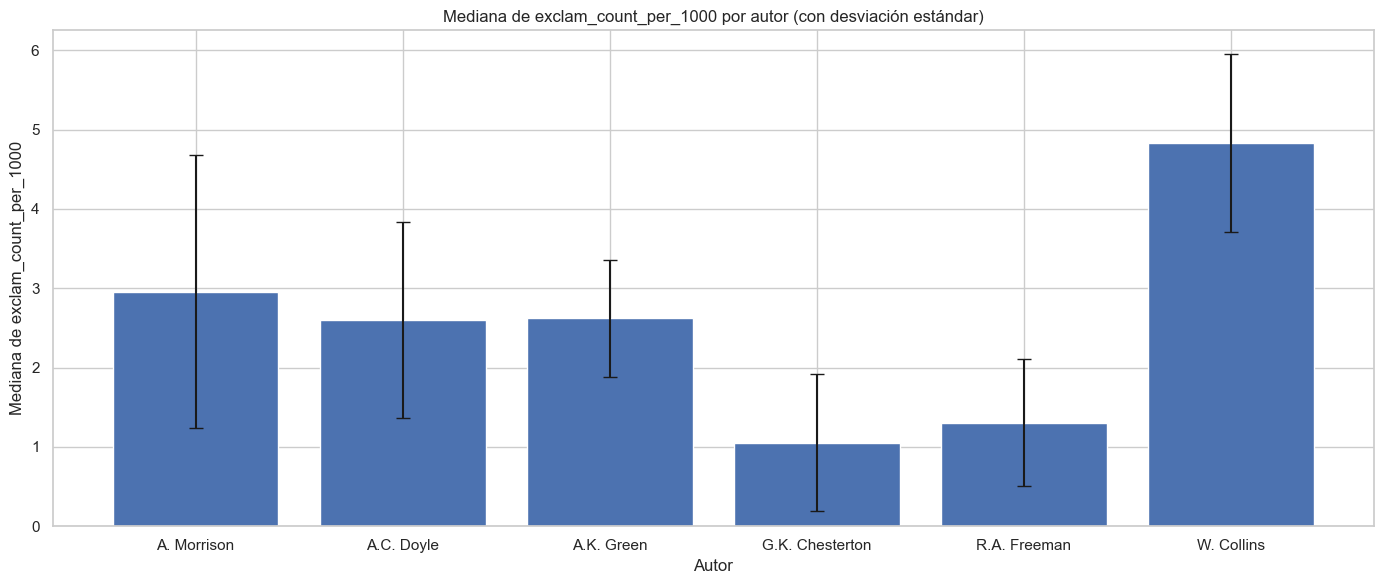

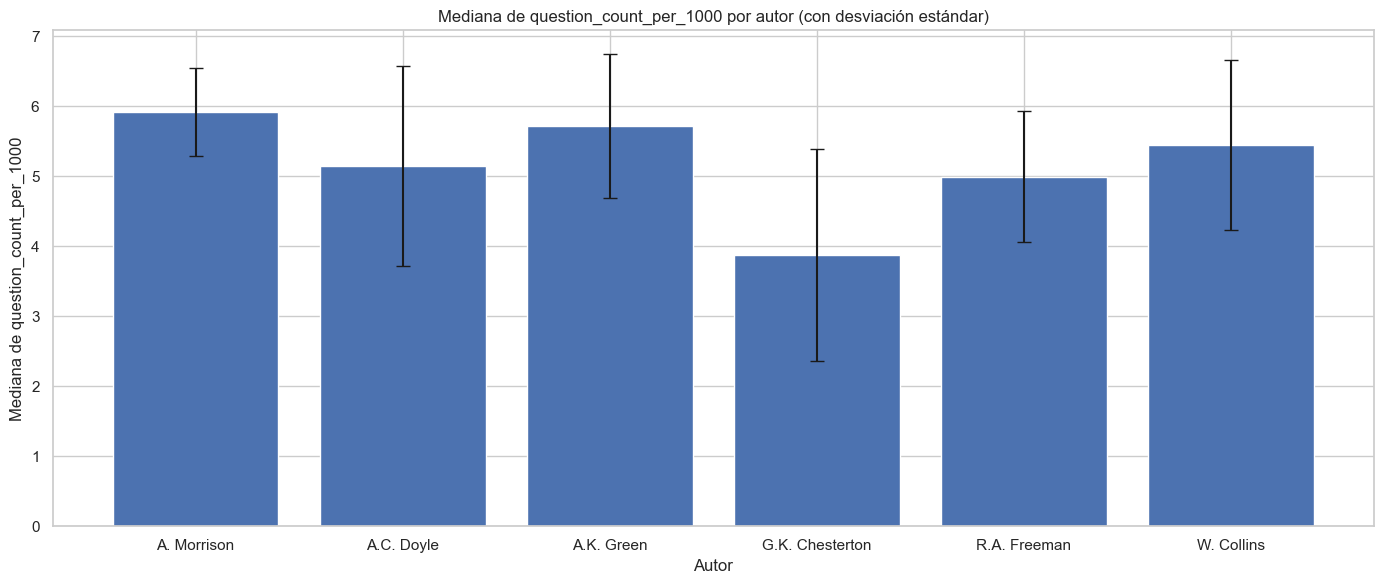

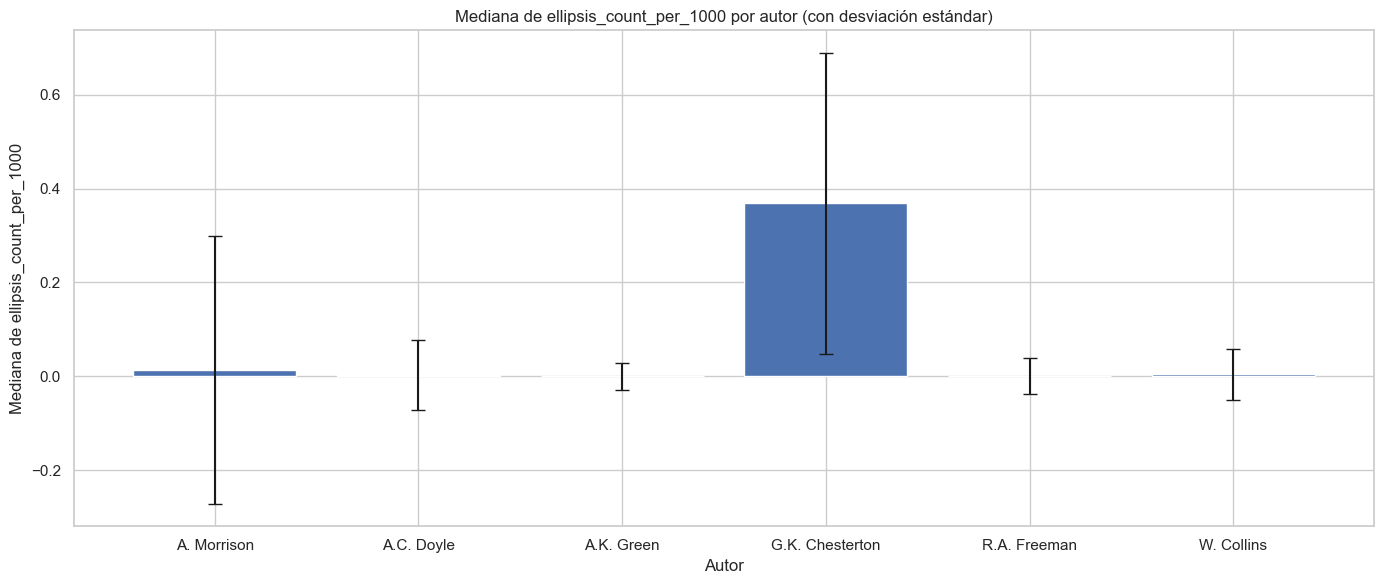

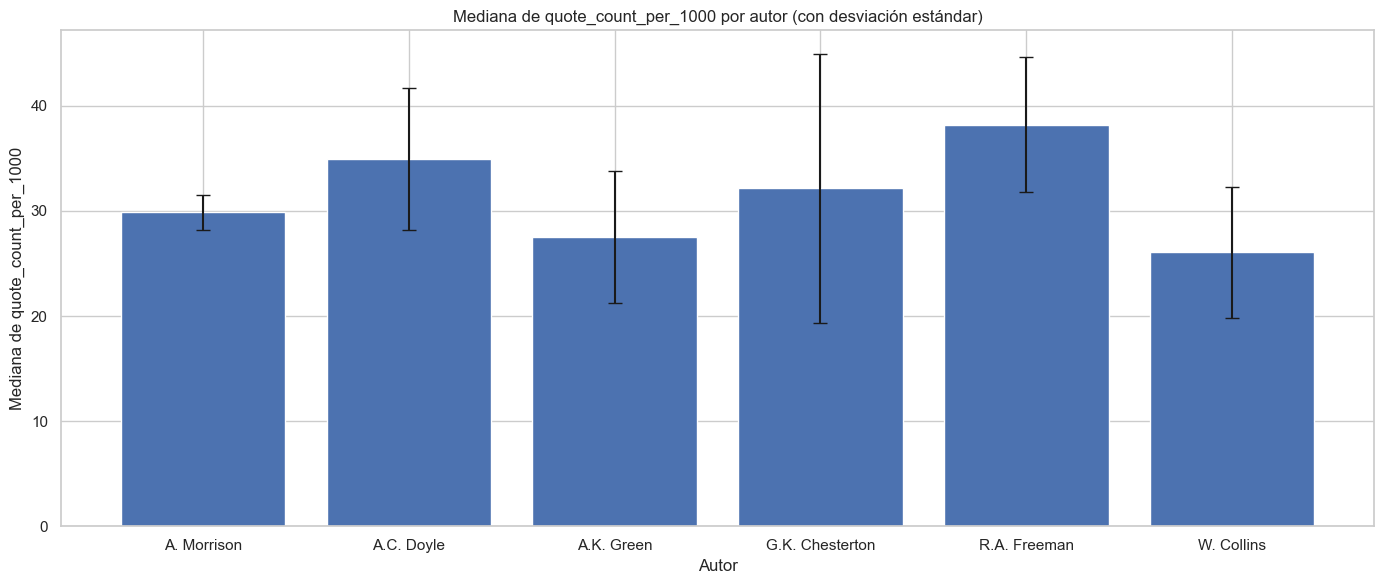

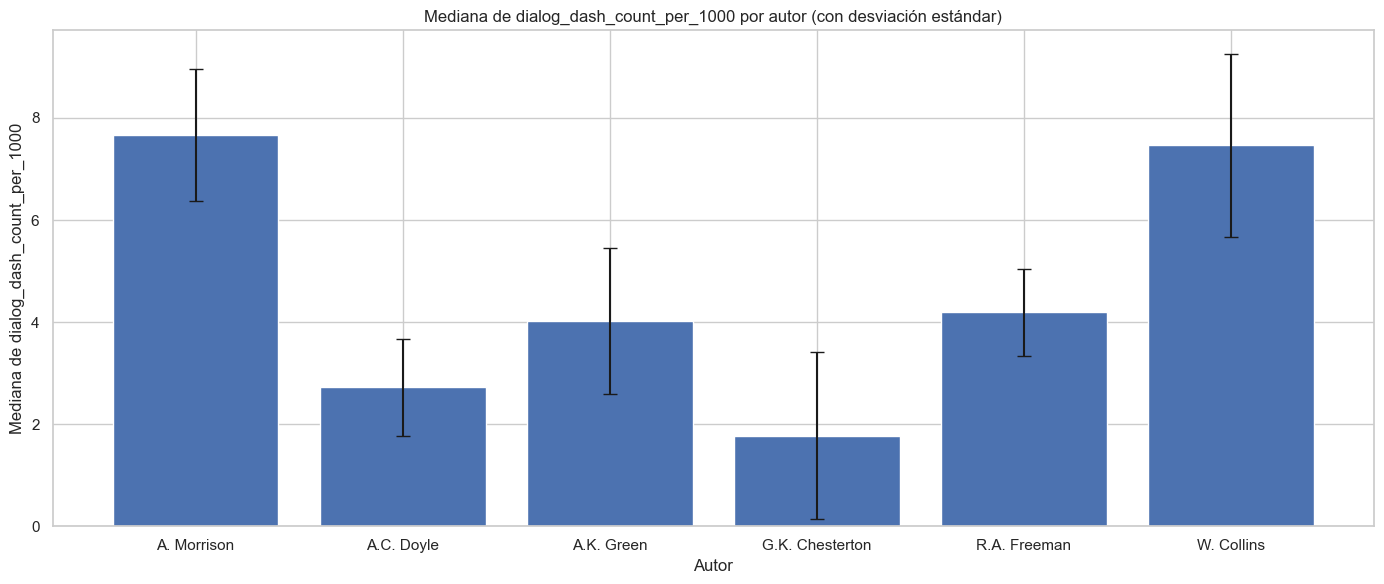

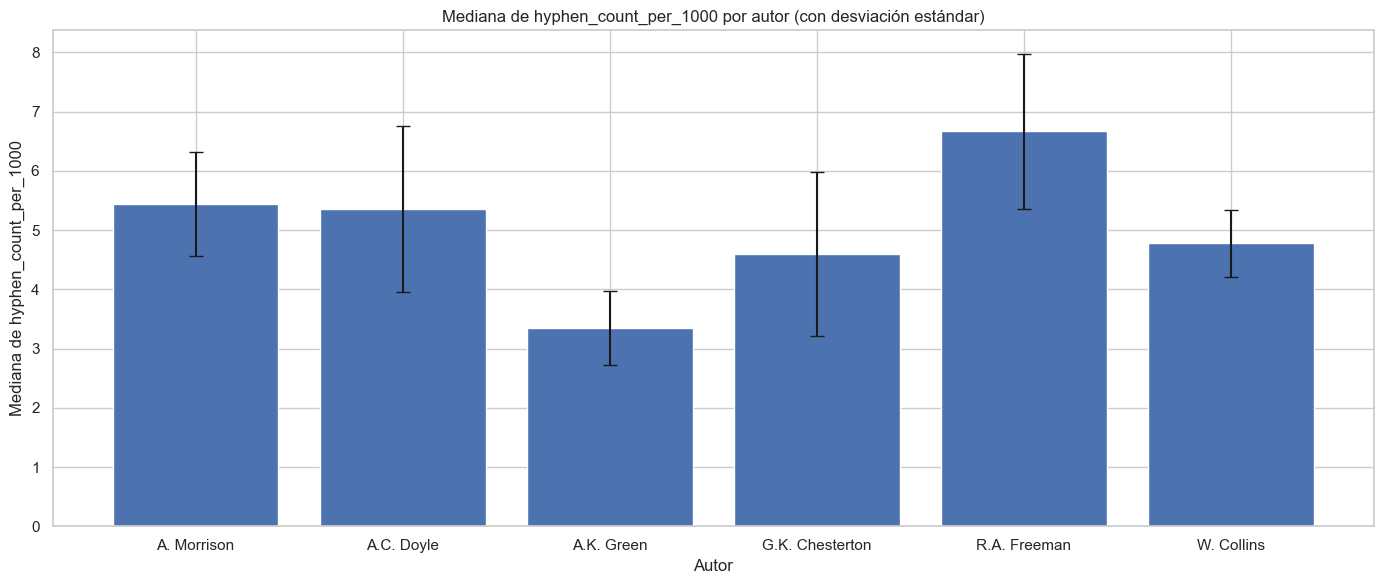

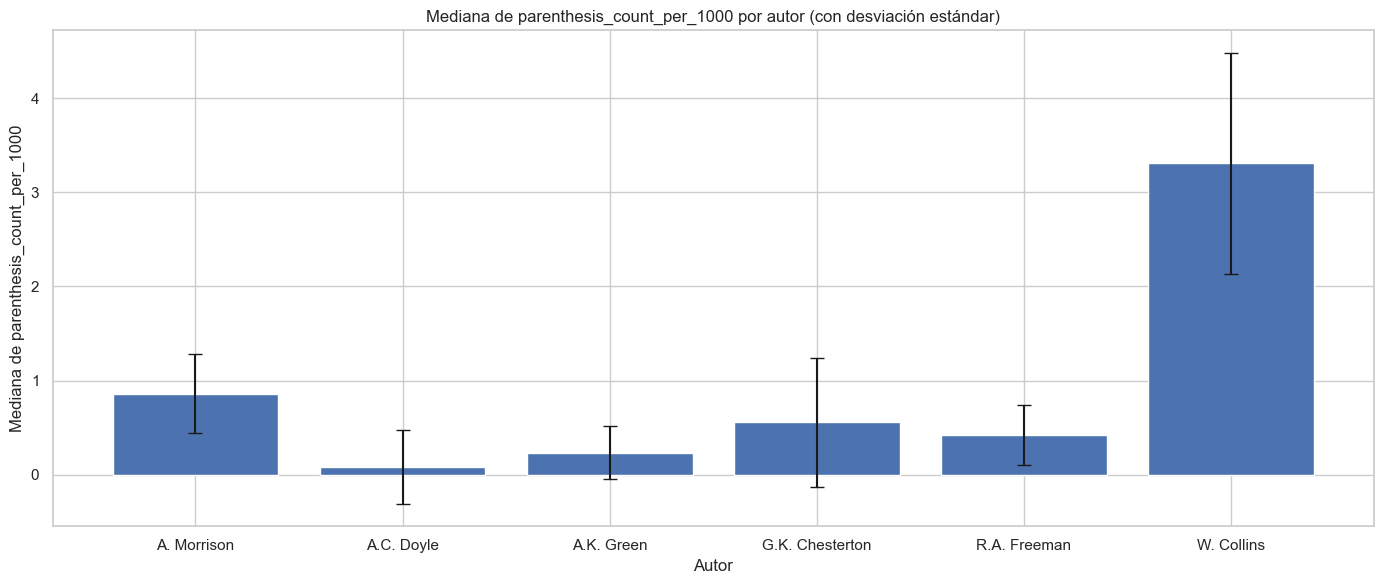

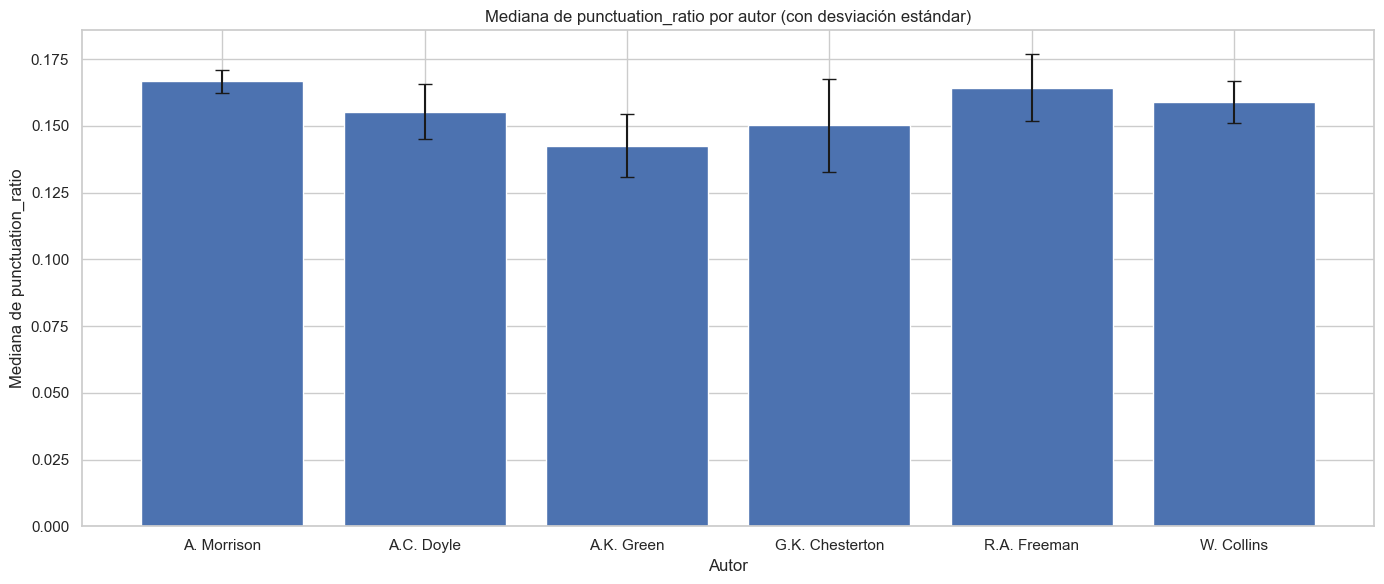

In [66]:
plot_bars_by_author_with_std(df_corpus, metric_cols, agg="median", save_path=FIGS_DIR / "bars_by_author_with_std.png")

Los pares de métricas de puntuación que vamos a analizar son los siguientes:

- `(dialog_dash_count_per_1000, question_count_per_1000)`. En misterio las novelas las preguntas aparecen mucho en interrogatorios y diálogo, esta métrica permite ver si esa tendencia se refleja en la frecuencia de signos de interrogación y guiones de diálogo.
- `(dialog_dash_count_per_1000, exclam_count_per_1000)`. Refleja si el énfasis emocional (!), típico de las escenas de tensión, se concentra en las escenas con diálogo.
- `(ellipsis_count_per_1000, dialog_dash_count_per_1000)`. Relaciona pausas/suspense (…) con presencia de diálogo, muy propio de escenas de tensión o revelación.
- `(comma_count_per_1000, period_count_per_1000)`. Puede reflejar si un autor prefiere oraciones más largas y subordinadas o más breves y segmentadas.
- `(parenthesis_count_per_1000, dash_count_per_1000 / hyphen_count_per_1000)`. Compara dos formas de hacer incisos o aclaraciones entre autores.

In [67]:
scatter_pairs = [
    ("dialog_dash_count_per_1000", "question_count_per_1000"),
    ("dialog_dash_count_per_1000", "exclam_count_per_1000"),
    ("ellipsis_count_per_1000", "dialog_dash_count_per_1000"),
    ("comma_count_per_1000", "period_count_per_1000"),
    ("parenthesis_count_per_1000", "hyphen_count_per_1000"),
]

In [68]:
plot_scatter_list_plotly(
    data=df_corpus,
    scatter_pairs=scatter_pairs,
    hue="author",
    work_col="title",
)

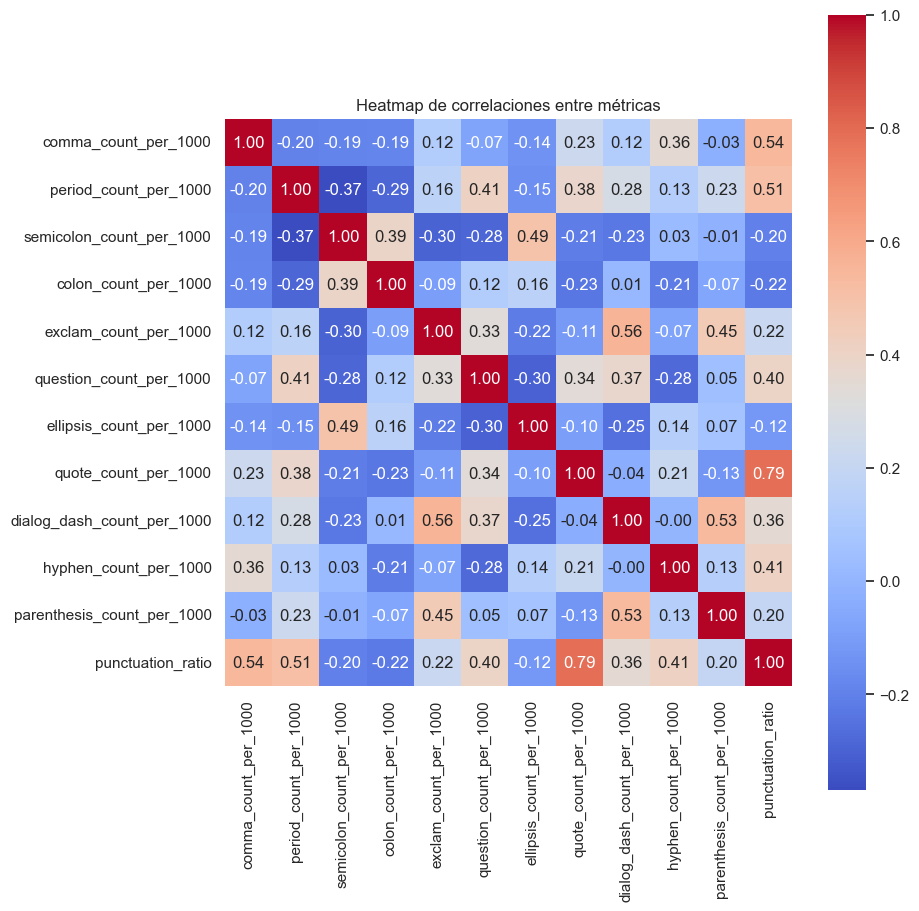

In [69]:
plot_metrics_correlations_heatmap(
    df_corpus, metric_cols, save_path=FIGS_DIR / "punctuation_metrics_correlations_heatmap.png"
)

### Métricas por autor

Vamos a analizar ahora las métricas estilométricas agrupadas por autor para ver si se detectan patrones diferenciadores entre ellos. Para ello, vamos a calcular los estadísticos descriptivos de una serie de métricas para cada autor y luego vamos a visualizar las medias para comparar entre autores.

En este caso, nos vamos a centrar solo en aquellas métricas más estables y robustas que permiten hacer comparaciones justas entre obras de distinta extensión, es decir, aquellas métricas que no están tan influenciadas por la longitud del texto y que, por tanto, pueden reflejar diferencias estilísticas reales entre autores sin estar sesgadas por el tamaño de las obras. En concreto, nos vamos a centrar en métricas como `mattr_100`, `stopword_ratio` o las métricas de puntuación normalizadas por cada 1.000 tokens alfabéticos.

In [70]:
stable_metrics = [
    # structural
    "avg_sentence_len",
    "median_sentence_len",
    "std_sentence_len",
    "sentences_per_1000_tokens",
    "short_sentence_ratio",
    "long_sentence_ratio",
    "avg_paragraph_len",
    "median_paragraph_len",
    "std_paragraph_len",
    "paragraphs_per_1000_tokens",
    "avg_sentences_per_paragraph",
    "median_sentences_per_paragraph",
    # lexical
    "mattr_100",
    "stopword_ratio",
    "avg_word_len",
    "median_word_len",
    "long_word_ratio",
    "non_alpha_token_ratio",
    # punctuation
    "punctuation_ratio",
    "comma_count_per_1000",
    "period_count_per_1000",
    "semicolon_count_per_1000",
    "colon_count_per_1000",
    "exclam_count_per_1000",
    "question_count_per_1000",
    "ellipsis_count_per_1000",
    "quote_count_per_1000",
    "dialog_dash_count_per_1000",
    "hyphen_count_per_1000",
    "parenthesis_count_per_1000",
]

In [71]:
# Obtenemos un dataframe con los estadísticos descriptivos
# de las métricas seleccionadas para cada autor
desc_by_author = df_corpus.groupby("author")[stable_metrics].describe()

desc_by_author.columns = [
    f"{metric}_{stat}".replace("25%", "p25").replace("50%", "p50").replace("75%", "p75")
    for metric, stat in desc_by_author.columns
]

desc_by_author = desc_by_author.reset_index()
print(desc_by_author.shape)
desc_by_author.head()

(6, 241)


,author,avg_sentence_len_count,avg_sentence_len_mean,avg_sentence_len_std,avg_sentence_len_min,avg_sentence_len_p25,avg_sentence_len_p50,avg_sentence_len_p75,avg_sentence_len_max,median_sentence_len_count,...,hyphen_count_per_1000_p75,hyphen_count_per_1000_max,parenthesis_count_per_1000_count,parenthesis_count_per_1000_mean,parenthesis_count_per_1000_std,parenthesis_count_per_1000_min,parenthesis_count_per_1000_p25,parenthesis_count_per_1000_p50,parenthesis_count_per_1000_p75,parenthesis_count_per_1000_max
0,A. Morrison,6.0,16.389989,0.342474,15.964436,16.198953,16.313471,16.608180,16.881361,6.0,...,5.925531,6.192080,6.0,0.765778,0.421418,0.157006,0.478252,0.859985,1.092405,1.196809
1,A.C. Doyle,12.0,15.999485,1.987074,12.726573,14.935757,15.887465,16.631811,19.941200,12.0,...,6.100071,7.801415,12.0,0.224956,0.389211,0.000000,0.051633,0.081761,0.146902,1.359247
2,A.K. Green,34.0,18.036365,2.224662,12.028459,17.002935,17.768164,18.937477,22.963839,34.0,...,3.640317,5.323278,34.0,0.332716,0.281462,0.000000,0.124544,0.232950,0.481464,1.188654
3,G.K. Chesterton,18.0,18.770866,1.774984,15.409231,18.155614,19.414013,20.035541,20.865908,18.0,...,5.199247,6.602027,18.0,0.808288,0.683927,0.000000,0.293253,0.557249,1.249770,2.360648
4,R.A. Freeman,15.0,17.946145,2.820055,16.036254,16.845106,16.959153,17.712740,27.558585,15.0,...,7.025250,9.452782,15.0,0.550548,0.318684,0.167859,0.305923,0.425011,0.804508,1.142984


El *heatmap* de métricas estandarizadas por autor que mostramos a continuación nos ofrece una visión global y comparativa de los perfiles estilísticos de los autores. Cada fila representa un autor, cada columna una métrica, y el color indica si ese autor está por encima o por debajo de la media del conjunto en ese rasgo concreto. Al estandarizar las métricas por columna, el gráfico no se centra en los valores absolutos, sino en las diferencias relativas entre autores, lo que permite identificar de un vistazo qué rasgos caracterizan más a cada uno.

Este tipo de visualización resulta especialmente útil para detectar patrones generales, similitudes entre autores y métricas que discriminan mejor entre estilos. Permite leer cada fila como una especie de “huella estilística”, donde se combinan aspectos de sintaxis, léxico o puntuación. Sin embargo, conviene interpretarlo como una herramienta exploratoria: muestra tendencias relativas, pero no sustituye a gráficos más específicos como barplots o boxplots cuando se quiere analizar en detalle una métrica concreta o la distribución real de los valores.

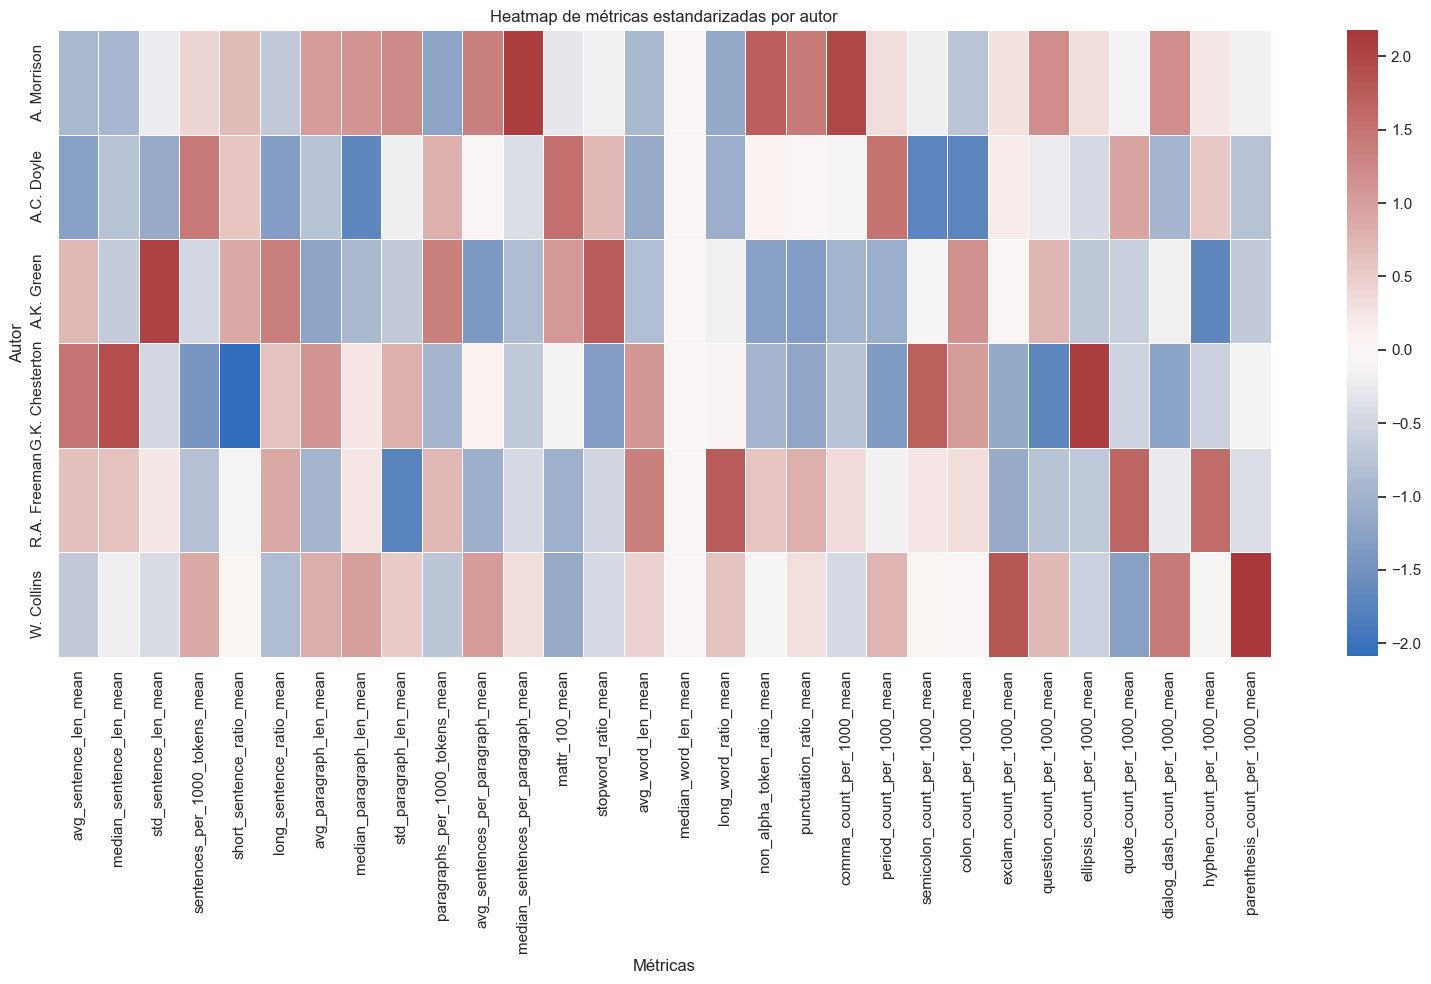

In [72]:
plot_standardized_heatmap_by_author(
    desc_by_author, value_cols="_mean", save_path=FIGS_DIR / "standardized_metrics_heatmap_by_author.png"
)

El análisis de PCA permite reducir el conjunto de métricas estilísticas a un espacio de pocas dimensiones, normalmente dos componentes principales, para visualizar de forma sintética las similitudes y diferencias entre autores. En este tipo de gráfico, cada punto representa un autor y su posición resume el comportamiento conjunto de muchas variables a la vez. Los autores que aparecen cercanos tienden a compartir perfiles estilísticos parecidos según las métricas consideradas, mientras que los que quedan más alejados presentan diferencias más marcadas.

La principal utilidad del PCA es ofrecer una visión estructural del conjunto de autores, facilitando la detección de agrupamientos, separaciones y patrones globales que no siempre son evidentes al observar métricas individuales por separado. Además, el análisis de las cargas de cada componente permite interpretar qué variables contribuyen más a esas diferencias, ayudando a entender si la separación entre autores está más relacionada con aspectos sintácticos, léxicos o de puntuación. Como ocurre con el *heatmap*, se trata de una herramienta exploratoria: resume mucha información de manera muy eficaz, pero conviene complementarla con visualizaciones más concretas para interpretar en detalle los rasgos que explican la posición de cada autor.

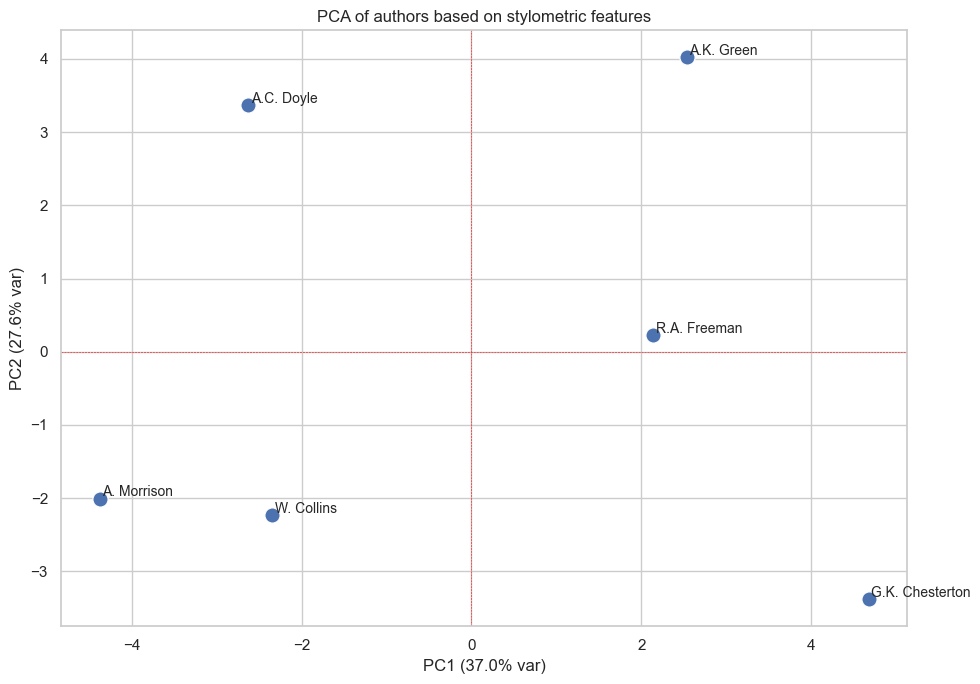

In [73]:
mean_cols = [c for c in desc_by_author.columns if c.endswith("_mean")]
X = desc_by_author.set_index("author")[mean_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index).reset_index()

plot_authors_pca(pca, pca_df, save_path=FIGS_DIR / "authors_pca.png")

In [74]:
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2"])

print("Top métricas en PC1")
print(loadings["PC1"].sort_values(key=np.abs, ascending=False).head(10))

print("\nTop métricas en PC2")
print(loadings["PC2"].sort_values(key=np.abs, ascending=False).head(10))

Top métricas en PC1
avg_sentence_len_mean                  0.294137
sentences_per_1000_tokens_mean        -0.270527
period_count_per_1000_mean            -0.258479
long_sentence_ratio_mean               0.258027
colon_count_per_1000_mean              0.253347
median_sentence_len_mean               0.235927
median_sentences_per_paragraph_mean   -0.234696
non_alpha_token_ratio_mean            -0.219264
punctuation_ratio_mean                -0.219132
question_count_per_1000_mean          -0.216635
Name: PC1, dtype: float64

Top métricas en PC2
paragraphs_per_1000_tokens_mean     0.326689
stopword_ratio_mean                 0.320061
avg_paragraph_len_mean             -0.319515
median_paragraph_len_mean          -0.303688
mattr_100_mean                      0.266584
semicolon_count_per_1000_mean      -0.241460
avg_sentences_per_paragraph_mean   -0.236111
short_sentence_ratio_mean           0.232986
ellipsis_count_per_1000_mean       -0.227526
std_paragraph_len_mean             -0.210428
Nam

### Frecuencias de palabras por autor

Vamos a analizar ahora las frecuencias de palabras por autor para ver si se detectan patrones diferenciadores entre ellos. Para ello, vamos a calcular las frecuencias de las palabras alfabéticas más comunes en cada autor y luego vamos a visualizar estas frecuencias para comparar entre autores.

In [75]:
# Obtenemos los tokens alfabéticos por autor
alpha_tokens_by_author = get_tokens_alpha_by_author(df_corpus)

In [76]:
alpha_tokens_by_author.keys()

dict_keys(['A. Morrison', 'A.C. Doyle', 'A.K. Green', 'G.K. Chesterton', 'R.A. Freeman', 'W. Collins'])

In [77]:
author_counters = compute_word_frecuencies(alpha_tokens_by_author, STOPWORDS, remove_stopwords=False)
author_counters_nostop = compute_word_frecuencies(alpha_tokens_by_author, STOPWORDS, remove_stopwords=True)

In [78]:
for autor, c in list(author_counters.items()):
    print(f"\n=== {autor} ===")
    print(top_n_words(c, 15))


=== A. Morrison ===
   token   freq
0    the  21570
1    and  11934
2      a   9388
3     of   9120
4     to   8163
5      i   7562
6     in   6012
7     he   5755
8    was   5388
9     it   5217
10  that   5021
11   you   3969
12   his   3418
13    as   3407
14    at   3082

=== A.C. Doyle ===
   token   freq
0    the  53268
1    and  26725
2     of  25598
3      a  22400
4     to  22154
5      i  21433
6   that  15015
7     in  14946
8     it  14554
9    was  13106
10    he  12843
11   you  11553
12   his  10936
13    is   8579
14   had   8158

=== A.K. Green ===
   token    freq
0    the  132787
1     to   74340
2    and   73539
3      i   68523
4     of   65337
5      a   53440
6     in   44507
7    was   40184
8     he   37757
9   that   34271
10    it   33440
11   her   32001
12   you   29202
13   had   28974
14   she   26280

=== G.K. Chesterton ===
   token   freq
0    the  57170
1     of  28597
2    and  27919
3      a  27710
4     to  19308
5     he  16425
6     in  15964
7 

In [79]:
for autor, c in list(author_counters_nostop.items()):
    print(f"\n=== {autor} ===")
    print(top_n_words(c, 15))


=== A. Morrison ===
     token  freq
0   hewitt  1572
1     said  1509
2       mr  1307
3      man  1125
4     know   870
5   little   830
6     door   694
7     time   673
8    think   626
9      way   621
10    come   615
11    case   555
12  course   553
13    room   520
14    went   520

=== A.C. Doyle ===
     token  freq
0     said  4182
1      man  2884
2   holmes  2609
3      sir  1843
4       mr  1705
5     come  1488
6   little  1372
7     time  1337
8     know  1308
9     came  1249
10    face  1196
11     way  1141
12    room  1115
13    like  1108
14    hand  1106

=== A.K. Green ===
    token  freq
0      mr  8800
1     man  6481
2    said  4966
3    know  4795
4    room  4621
5   house  4413
6    time  3955
7    look  3938
8    door  3723
9    came  3569
10   face  3522
11   hand  3469
12   like  3463
13    way  3422
14    saw  3294

=== G.K. Chesterton ===
     token  freq
0     said  6536
1     like  3847
2      man  3591
3     know  1814
4    brown  1676
5   little  

Como vemos, si no eliminamos las *stopwords* del análisis, las palabras más frecuentes de cada autor son principalmente palabras funcionales como artículos, preposiciones o pronombres, que no aportan información temática pero sí reflejan patrones de estilo. Por ejemplo, palabras como "the", "and", "of", "to" o "in" suelen ser las más frecuentes en la mayoría de los autores, lo que indica que el uso de estas palabras funcionales es un rasgo común en el corpus.

### Top n-grams por autor

Vamos a analizar ahora los n-grams más frecuentes por autor para ver si se detectan patrones que nos permitan diferenciar entre ellos. Para ello, vamos a calcular las frecuencias de los bigramas y trigramas alfabéticos más comunes en cada autor y luego vamos a visualizar estas frecuencias para comparar entre autores.

In [80]:
top_bigrams_by_author = compute_ngrams_frecuencies(alpha_tokens_by_author, stopword_set=STOPWORDS, ngram_n=2, top_k=20)
top_trigrams_by_author = compute_ngrams_frecuencies(alpha_tokens_by_author, stopword_set=STOPWORDS, ngram_n=3, top_k=20)

In [81]:
top_bigrams_by_author

{'A. Morrison': [('grandfather nat', 159),
  ('mr hewitt', 130),
  ('mr cripps', 112),
  ('hewitt said', 111),
  ('martin hewitt', 98),
  ('said hewitt', 79),
  ('hole wall', 66),
  ('captain nat', 65),
  ('mr crellan', 64),
  ('blind george', 63),
  ('mrs grimes', 63),
  ('matter fact', 59),
  ('pocket book', 55),
  ('mrs geldard', 55),
  ('miss garth', 53),
  ('dan ogle', 52),
  ('hewitt replied', 50),
  ('sir james', 46),
  ('bar parlour', 46),
  ('blue gate', 46)],
 'A.C. Doyle': [('mr holmes', 600),
  ('said holmes', 534),
  ('sherlock holmes', 348),
  ('sir nigel', 324),
  ('lord john', 204),
  ('said i.', 179),
  ('sir henry', 143),
  ('young man', 138),
  ('yes sir', 133),
  ('baker street', 114),
  ('said sir', 101),
  ('watson said', 100),
  ('holmes said', 98),
  ('dr watson', 97),
  ('mr sherlock', 94),
  ('sir said', 92),
  ('old man', 80),
  ('dear watson', 80),
  ('said alleyne', 78),
  ('said lord', 75)],
 'A.K. Green': [('mr gryce', 1443),
  ('new york', 491),
  ('youn

In [82]:
top_trigrams_by_author

{'A. Morrison': [('mr martin hewitt', 23),
  ('said grandfather nat', 13),
  ('mr hewitt said', 11),
  ('café des bons', 11),
  ('des bons camarades', 11),
  ('old jerry cater', 11),
  ('leather pocket book', 11),
  ('je le nie', 10),
  ('avalanche bicycle tyre', 10),
  ('mr jacob mason', 10),
  ("cap'en nat kemp", 10),
  ('bar parlour door', 10),
  ("uncle joseph's snuff", 9),
  ("joseph's snuff box", 9),
  ('mr paul mallows', 9),
  ('reuben b. hoker', 8),
  ('man broken shoe', 8),
  ('bicycle tyre company', 8),
  ('mr loftus deacon', 8),
  ("old jerry cater's", 8)],
 'A.C. Doyle': [('mr sherlock holmes', 92),
  ('said sir nigel', 64),
  ('mr holmes said', 62),
  ('said lord john', 55),
  ('said sherlock holmes', 42),
  ('lord john roxton', 29),
  ('sir nigel loring', 28),
  ('lord st simon', 27),
  ('cried sir nigel', 24),
  ('sir henry baskerville', 22),
  ('quoth sir nigel', 21),
  ('watson said holmes', 19),
  ('friend dr watson', 15),
  ('sir william felton', 15),
  ('neville st 

### Curvas de Zipf por autor

Las curvas de Zipf muestran una regularidad básica del lenguaje: unas pocas palabras aparecen con muchísima frecuencia y una gran mayoría aparecen muy poco. Cuando se ordenan las palabras por rango y se representa su frecuencia en escala log-log, suele observarse una relación aproximadamente lineal, lo que refleja esa estructura típica del vocabulario en textos escritos en lenguaje natural. En términos lingüísticos, la parte alta de la distribución está dominada por palabras funcionales muy frecuentes, mientras que la cola recoge palabras raras, específicas o de contexto.

En estilometría, comparar las curvas de Zipf entre autores sirve como una visión global de cómo se distribuye su léxico y permite observar si hay más concentración en palabras muy frecuentes, una cola léxica más larga o diferencias generales en repetición y variedad. Esto conecta con una idea central de la atribución de autoría: los patrones de frecuencia, especialmente de palabras funcionales, pueden reflejar hábitos estilísticos relativamente estables y menos dependientes del tema. Aun así, la utilidad de Zipf es sobre todo exploratoria y descriptiva, no concluyente por sí sola.

Además, estas curvas son útiles como herramienta de diagnóstico del corpus. Una curva anómala puede señalar no solo diferencias de estilo, sino también problemas de procesamiento o composición del corpus, como textos demasiado cortos, duplicados, errores de OCR o tokenización inconsistente. Por eso, las curvas de Zipf son valiosas en el análisis exploratorio inicial, pero para una estilometría más fina conviene complementarlas con medidas más discriminativas, como palabras frecuentes, n-gramas o distancias estilométricas específicas.

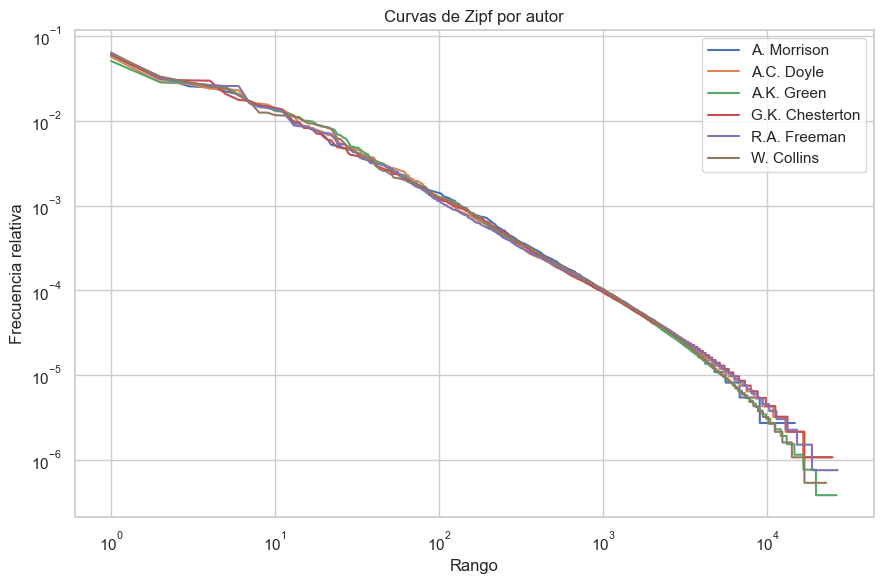

In [83]:
plot_zipf_curve_by_author(alpha_tokens_by_author, FIGS_DIR / "zipf_by_author.png")

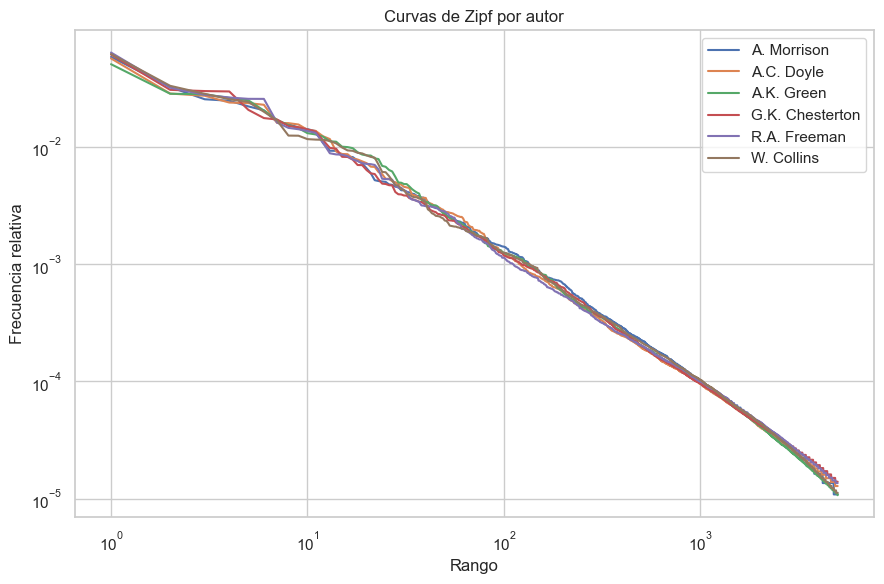

In [84]:
# Nos quedamos solo con las 5000 palabras más frecuentes
# para evitar ruido en la cola larga de la distribución
plot_zipf_curve_by_author(alpha_tokens_by_author, FIGS_DIR / "zipf_by_author_max_rank_5000.png", max_rank=5000)

Vemos que las curvas de Zipf de los distintos autores siguen la forma típica de una distribución de frecuencia de palabras, con una caída pronunciada en las palabras más frecuentes y una larga cola de palabras raras. Sin embargo, hay algunas diferencias entre autores en la pendiente de la curva y en la posición de las palabras más frecuentes, lo que sugiere que cada autor tiene un perfil léxico característico.